<a href="https://colab.research.google.com/github/Paulifx0/project-78-solvent-analysis/blob/main/Project_78_Final_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 78 - Final Data Analysis

Low-cost multispectral optical sensor for monitoring solvent waste in teaching laboratory.

## Analysis workflow
1. Raw data inspection
2. Precision
3. Calibration
4. Multispectral comparison
5. PCA
6. Real waste analysis
7. GC benchmarking
8. Matrix spike analysis
9. PLS modelling
10. Reduced-wavelength modelling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/project_78/Ethanol/20%ethanol.csv"
df = pd.read_csv(file_path)


In [ ]:
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Shape: (2, 10)

Columns:
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']

Data types:
sample        object
replicate      int64
465_full     float64
465_IR         int64
625_full     float64
625_IR       float64
850_full     float64
850_IR       float64
940_full     float64
940_IR       float64
dtype: object


In [ ]:
df.isnull().sum()

,0
sample,0
replicate,0
465_full,0
465_IR,0
625_full,0
625_IR,0
850_full,0
850_IR,0
940_full,0
940_IR,0


In [ ]:
df[[
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]]

,465_full,625_full,850_full,940_full
0,1343.8,477.9,2211.0,19300.5
1,1368.7,475.0,2206.6,19239.0


In [ ]:
channels = [
            "465_full",
            "625_full",
            "850_full",
            "940_full"
            ]
df[["sample", "replicate"] + channels]

,sample,replicate,465_full,625_full,850_full,940_full
0,ethanol_20,1,1343.8,477.9,2211.0,19300.5
1,ethanol_20,2,1368.7,475.0,2206.6,19239.0


In [ ]:
mean_940 = df["940_full"].mean()
print("Mean =", mean_940)

Mean = 19269.75


In [ ]:
std_940 = df["940_full"].std()
print("standard deviation = ", std_940)

standard deviation =  43.487067042972676


In [ ]:
RSD_940 = (std_940 / mean_940) * 100
print("RSD % = ", RSD_940)

RSD % =  0.2256753047806675


In [ ]:
def calculate_precision(df, concentration):

  channels = [
            "465_full",
            "625_full",
            "850_full",
            "940_full"
            ]

  results = []

  for channel in channels:
    mean = df[channel].mean()
    sd = df[channel].std()
    rsd = (sd / mean) * 100

    results.append({
      "Channel": channel,
      "Mean": mean,
      "SD": sd,
      "RSD": rsd,
      "Concentration": concentration
    })

  return pd.DataFrame(results)

In [ ]:
precision_20 = calculate_precision(df, 20)
precision_20

,Channel,Mean,SD,RSD,Concentration
0,465_full,1356.25,17.606959,1.298209,20
1,625_full,476.45,2.050610,0.430393,20
2,850_full,2208.80,3.111270,0.140858,20
3,940_full,19269.75,43.487067,0.225675,20


In [ ]:
file_40 = "/content/drive/MyDrive/project_78/Ethanol/40%ethanol.csv"
df_40 = pd.read_csv(file_40)

df_40

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,ethanol_40,1,1367.8,23.0,478.6,106.4,2243.9,1397.8,19828.0,14210.9
1,ethanol_40,2,1297.1,22.0,482.0,107.0,2257.5,1406.0,19795.3,14191.2


In [ ]:
print(df_40.shape)
print(df_40.columns.tolist())
print(df_40.isnull().sum())

(2, 10)
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


In [ ]:
precision_40 = calculate_precision(df_40, 40)
precision_40

,Channel,Mean,SD,RSD,Concentration
0,465_full,1332.45,49.992449,3.751919,40
1,625_full,480.30,2.404163,0.500554,40
2,850_full,2250.70,9.616652,0.427274,40
3,940_full,19811.65,23.122392,0.116711,40


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=precision_40)

https://docs.google.com/spreadsheets/d/1P0WRlgye34goIk5hSmWhD8yBcAEOvIdDfA556tbK1fc/edit#gid=0


In [ ]:
file_60 = "/content/drive/MyDrive/project_78/Ethanol/60%ethanol.csv"
df_60 = pd.read_csv(file_60)

df_60

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,ethanol_60,1,1377.2,23.0,483.6,108.0,2271.3,1415.2,20436.0,14660.6
1,ethanol_60,2,1380.3,23.0,484.6,108.0,2286.4,1424.0,20431.8,14660.5


In [ ]:
print(df_60.shape)
print(df_60.columns.tolist())
print(df_60.isnull().sum())

(2, 10)
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


In [ ]:
precision_60 = calculate_precision(df_60, 60)
precision_60

,Channel,Mean,SD,RSD,Concentration
0,465_full,1378.75,2.192031,0.158987,60
1,625_full,484.10,0.707107,0.146066,60
2,850_full,2278.85,10.677312,0.468540,60
3,940_full,20433.90,2.969848,0.014534,60


In [ ]:
file_80 = "/content/drive/MyDrive/project_78/Ethanol/80%ethanol.csv"
df_80 = pd.read_csv(file_80)

df_80

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,ethanol_80,1,1387.8,23,484.6,108.0,2272.8,1416.4,20919.1,15022.0
1,ethanol_80,2,1378.0,23,484.5,107.9,2263.9,1411.0,21081.1,15139.9


In [ ]:
print(df_80.shape)
print(df_80.columns.tolist())
print(df_80.isnull().sum())

(2, 10)
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


In [ ]:
precision_80 = calculate_precision(df_80, 80)
precision_80

,Channel,Mean,SD,RSD,Concentration
0,465_full,1382.90,6.929646,0.501095,80
1,625_full,484.55,0.070711,0.014593,80
2,850_full,2268.35,6.293250,0.277437,80
3,940_full,21000.10,114.551299,0.545480,80


In [ ]:
file_100 = "/content/drive/MyDrive/project_78/Ethanol/100%ethanol.csv"
df_100 = pd.read_csv(file_100)

df_100

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,ethanol_100,1,1353.1,23,482.1,107.0,2234.8,1394.1,21669.6,15572.1
1,ethanol_100,2,1383.3,23,482.7,107.4,2271.3,1415.0,21569.9,15502.7


In [ ]:
print(df_100.shape)
print(df_100.columns.tolist())
print(df_100.isnull().sum())

(2, 10)
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


In [ ]:
precision_100 = calculate_precision(df_100, 100)
precision_100

,Channel,Mean,SD,RSD,Concentration
0,465_full,1368.20,21.354625,1.560782,100
1,625_full,482.40,0.424264,0.087949,100
2,850_full,2253.05,25.809398,1.145532,100
3,940_full,21619.75,70.498546,0.326084,100


In [ ]:
ethanol_precision = pd.concat([precision_20, precision_40, precision_60, precision_80, precision_100])
ethanol_precision

,Channel,Mean,SD,RSD,Concentration
0,465_full,1356.25,17.606959,1.298209,20
1,625_full,476.45,2.050610,0.430393,20
2,850_full,2208.80,3.111270,0.140858,20
3,940_full,19269.75,43.487067,0.225675,20
0,465_full,1332.45,49.992449,3.751919,40
1,625_full,480.30,2.404163,0.500554,40
2,850_full,2250.70,9.616652,0.427274,40
3,940_full,19811.65,23.122392,0.116711,40
0,465_full,1378.75,2.192031,0.158987,60
1,625_full,484.10,0.707107,0.146066,60


In [ ]:
file_baseline = "/content/drive/MyDrive/project_78/Ethanol/baseline_waternew.csv"
df_baseline = pd.read_csv(file_baseline)

df_baseline

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,water_blank,1,1336.9,22.0,474.2,105.5,2150.0,1339.0,18315.4,13104.2
1,water_blank,2,1345.3,22.1,469.5,104.9,2135.1,1330.3,18397.1,13169.3
2,water_blank,3,1359.5,23.0,473.8,106.0,2158.2,1344.7,18350.0,13121.9


In [ ]:
print(df_baseline.shape)
print(df_baseline.columns.tolist())
print(df_baseline .isnull().sum())

(3, 10)
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


In [ ]:
precision_baseline = calculate_precision(df_baseline, 0)
precision_baseline

,Channel,Mean,SD,RSD,Concentration
0,465_full,1347.233333,11.423368,0.847913,0
1,625_full,472.500000,2.605763,0.551484,0
2,850_full,2147.766667,11.710821,0.545256,0
3,940_full,18354.166667,41.009064,0.223432,0


In [ ]:
ethanol_precision = pd.concat([precision_20, precision_40, precision_60, precision_80, precision_100, precision_baseline])
ethanol_precision

,Channel,Mean,SD,RSD,Concentration
0,465_full,1356.250000,17.606959,1.298209,20
1,625_full,476.450000,2.050610,0.430393,20
2,850_full,2208.800000,3.111270,0.140858,20
3,940_full,19269.750000,43.487067,0.225675,20
0,465_full,1332.450000,49.992449,3.751919,40
1,625_full,480.300000,2.404163,0.500554,40
2,850_full,2250.700000,9.616652,0.427274,40
3,940_full,19811.650000,23.122392,0.116711,40
0,465_full,1378.750000,2.192031,0.158987,60
1,625_full,484.100000,0.707107,0.146066,60


In [ ]:
precision_summary = (
    ethanol_precision
    .groupby("Channel")["RSD"]
    .agg(["mean", "min", "max"])
)

precision_summary

,mean,min,max
Channel,,,
465_full,1.353151,0.158987,3.751919
625_full,0.288507,0.014593,0.551484
850_full,0.500816,0.140858,1.145532
940_full,0.241986,0.014534,0.545480


In [ ]:
precision_summary.round(3)

,mean,min,max
Channel,,,
465_full,1.353,0.159,3.752
625_full,0.289,0.015,0.551
850_full,0.501,0.141,1.146
940_full,0.242,0.015,0.545


In [ ]:
ethanol_means = ethanol_precision.pivot(
    index="Concentration",
    columns="Channel",
    values="Mean"
)


ethanaol_means =  ethanol_means.sort_index
ethanol_means

Channel,465_full,625_full,850_full,940_full
Concentration,,,,
0,1347.233333,472.50,2147.766667,18354.166667
20,1356.250000,476.45,2208.800000,19269.750000
40,1332.450000,480.30,2250.700000,19811.650000
60,1378.750000,484.10,2278.850000,20433.900000
80,1382.900000,484.55,2268.350000,21000.100000
100,1368.200000,482.40,2253.050000,21619.750000


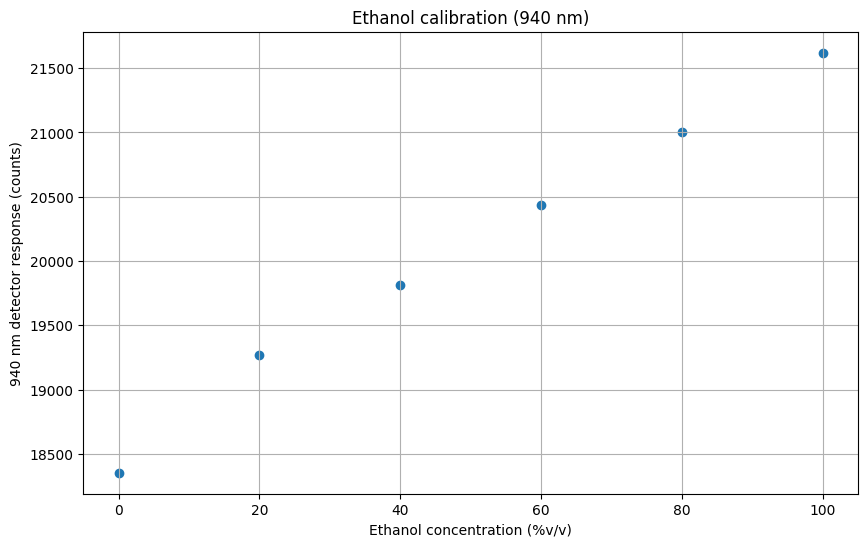

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    ethanol_means.index,
    ethanol_means["940_full"]
)

plt.xlabel("Ethanol concentration (%v/v)")
plt.ylabel("940 nm detector response (counts)")
plt.title("Ethanol calibration (940 nm)")
plt.grid(True)

plt.show()

In [ ]:
from scipy.stats import linregress

x = ethanol_means.index.to_numpy()
y = ethanol_means["940_full"].to_numpy()

reg = linregress(x, y)

print("Slope:", reg.slope)
print("Intercept:", reg.intercept)
print("R²:", reg.rvalue**2)

Slope: 31.63030952380951
Intercept: 18500.037301587305
R²: 0.9934284892967357


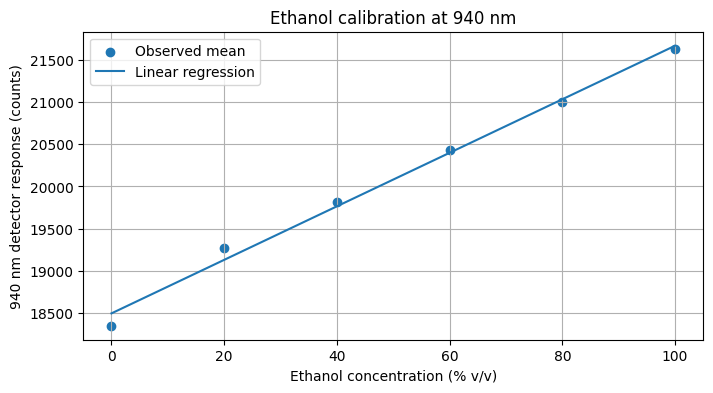

In [ ]:
predicted = reg.intercept + reg.slope * x

plt.figure(figsize=(8,4))

plt.scatter(x, y, label="Observed mean")

plt.plot(
    x,
    predicted,
    label="Linear regression"
)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("940 nm detector response (counts)")
plt.title("Ethanol calibration at 940 nm")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
residuals = y - predicted

for conc, resid in zip(x, residuals):
    print(conc, resid)


0 -145.8706349206368
20 137.10650793650348
40 46.40031746031673
60 36.04412698412489
80 -30.362063492066227
100 -43.31825396825661


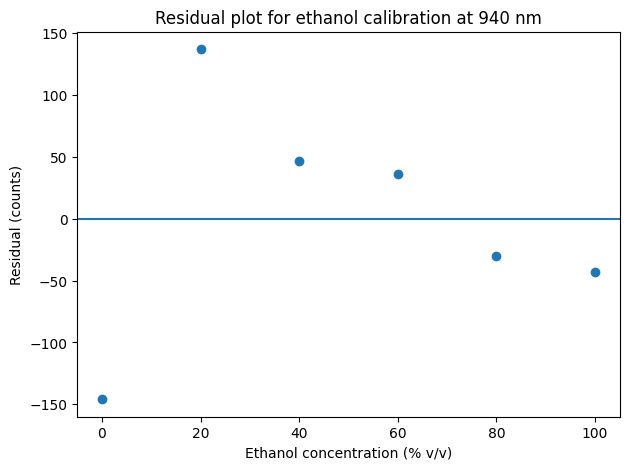

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(x, residuals)

plt.axhline(0)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("Residual (counts)")
plt.title("Residual plot for ethanol calibration at 940 nm")

plt.show()

In [ ]:
# Linear model
linear_coeffs = np.polyfit(x, y, 1)
linear_pred = np.polyval(linear_coeffs, x)

linear_r2 = r2_score(y, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y, linear_pred))

# Quadratic model
quadratic_coeffs = np.polyfit(x, y, 2)
quadratic_pred = np.polyval(quadratic_coeffs, x)

quadratic_r2 = r2_score(y, quadratic_pred)
quadratic_rmse = np.sqrt(mean_squared_error(y, quadratic_pred))

print("Linear equation coefficients:", linear_coeffs)
print("Linear R²:", linear_r2)
print("Linear RMSE:", linear_rmse)

print()

print("Quadratic equation coefficients:", quadratic_coeffs)
print("Quadratic R²:", quadratic_r2)
print("Quadratic RMSE:", quadratic_rmse)

Linear equation coefficients: [   31.63030952 18500.03730159]
Linear R²: 0.9934284892967357
Linear RMSE: 87.87010415713348

Quadratic equation coefficients: [-6.17172619e-02  3.78020357e+01  1.84177476e+04]
Quadratic R²: 0.9966559557584594
Quadratic RMSE: 62.68224443329843


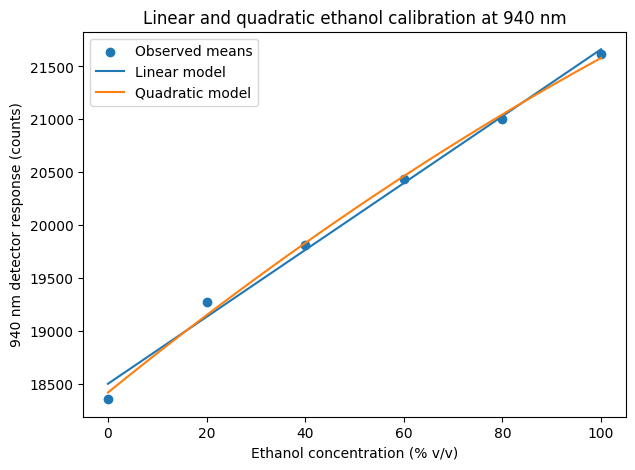

In [ ]:
x_smooth = np.linspace(0, 100, 200)

linear_smooth = np.polyval(
    linear_coeffs,
    x_smooth
)

quadratic_smooth = np.polyval(
    quadratic_coeffs,
    x_smooth
)

plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    y,
    label="Observed means"
)

plt.plot(
    x_smooth,
    linear_smooth,
    label="Linear model"
)

plt.plot(
    x_smooth,
    quadratic_smooth,
    label="Quadratic model"
)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("940 nm detector response (counts)")
plt.title("Linear and quadratic ethanol calibration at 940 nm")

plt.legend()
plt.show()

In [ ]:
x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

linear_cv_predictions = []
quadratic_cv_predictions = []

for i in range(len(x)):

    # True means keep every row except row i
    train_mask = np.arange(len(x)) != i

    x_train = x[train_mask]
    y_train = y[train_mask]

    x_test = x[i]

    # Fit using five concentration levels
    linear_cv_coeffs = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_cv_coeffs = np.polyfit(
        x_train,
        y_train,
        2
    )

    # Predict the concentration level left out
    linear_cv_predictions.append(
        np.polyval(linear_cv_coeffs, x_test)
    )

    quadratic_cv_predictions.append(
        np.polyval(quadratic_cv_coeffs, x_test)
    )

linear_cv_predictions = np.array(
    linear_cv_predictions
)

quadratic_cv_predictions = np.array(
    quadratic_cv_predictions
)

In [ ]:
linear_rmsecv = np.sqrt(
    mean_squared_error(
        y,
        linear_cv_predictions
    )
)

quadratic_rmsecv = np.sqrt(
    mean_squared_error(
        y,
        quadratic_cv_predictions
    )
)

print("Linear RMSECV:", linear_rmsecv)
print("Quadratic RMSECV:", quadratic_rmsecv)

Linear RMSECV: 156.50416211846073
Quadratic RMSECV: 188.18981369399074


In [ ]:
def calculate_q2(actual, predicted):

    press = np.sum(
        (actual - predicted) ** 2
    )

    total_variation = np.sum(
        (actual - actual.mean()) ** 2
    )

    return 1 - (press / total_variation)


linear_q2 = calculate_q2(
    y,
    linear_cv_predictions
)

quadratic_q2 = calculate_q2(
    y,
    quadratic_cv_predictions
)

print("Linear Q²:", linear_q2)
print("Quadratic Q²:", quadratic_q2)

Linear Q²: 0.9791534246027904
Quadratic Q²: 0.9698577851008824


In [ ]:
cv_results = pd.DataFrame({
    "Concentration": x,
    "Observed": y,
    "Linear_CV_prediction": linear_cv_predictions,
    "Quadratic_CV_prediction": quadratic_cv_predictions
})

cv_results["Linear_error"] = (
    cv_results["Observed"]
    - cv_results["Linear_CV_prediction"]
)

cv_results["Quadratic_error"] = (
    cv_results["Observed"]
    - cv_results["Quadratic_CV_prediction"]
)

cv_results.round(2)

,Concentration,Observed,Linear_CV_prediction,Quadratic_CV_prediction,Linear_error,Quadratic_error
0,0.0,18354.17,18660.50,18710.22,-306.33,-356.05
1,20.0,19269.75,19075.21,19095.62,194.54,174.13
2,40.0,19811.65,19755.00,19842.56,56.65,-30.91
3,60.0,20433.90,20389.89,20481.29,44.01,-47.39
4,80.0,21000.10,21043.18,21067.68,-43.08,-67.58
5,100.0,21619.75,21710.72,21401.51,-90.97,218.24


In [ ]:
print(f"Linear RMSECV: {linear_rmsecv:.3f} counts")
print(f"Quadratic RMSECV: {quadratic_rmsecv:.3f} counts")

print(f"Linear Q²: {linear_q2:.4f}")
print(f"Quadratic Q²: {quadratic_q2:.4f}")

Linear RMSECV: 156.504 counts
Quadratic RMSECV: 188.190 counts
Linear Q²: 0.9792
Quadratic Q²: 0.9699


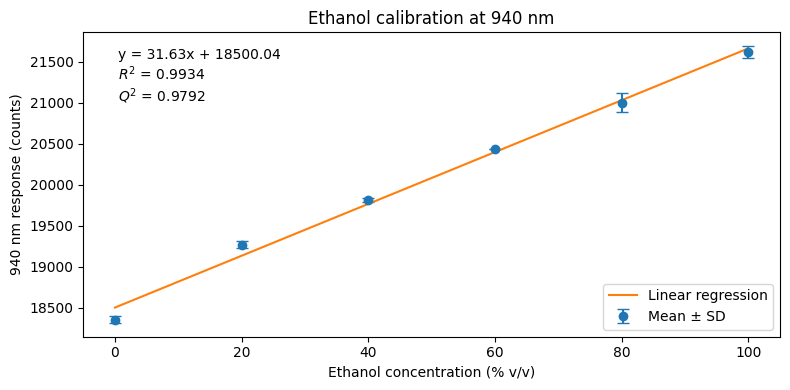

In [ ]:
ethanol_sd = ethanol_precision.pivot(
    index="Concentration",
    columns="Channel",
    values="SD"
).sort_index()

x = ethanol_means.index.to_numpy()
y = ethanol_means["940_full"].to_numpy()
y_sd = ethanol_sd["940_full"].to_numpy()

reg = linregress(x, y)
linear_pred = reg.intercept + reg.slope * x

plt.figure(figsize=(8, 4))

plt.errorbar(
    x,
    y,
    yerr=y_sd,
    fmt="o",
    capsize=4,
    label="Mean ± SD"
)

plt.plot(
    x,
    linear_pred,
    label="Linear regression"
)

equation_text = (
    f"y = {reg.slope:.2f}x + {reg.intercept:.2f}\n"
    f"$R^2$ = {reg.rvalue**2:.4f}\n"
    f"$Q^2$ = {linear_q2:.4f}"
)

plt.text(
    0.05,
    0.95,
    equation_text,
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Ethanol calibration at 940 nm")
plt.legend()
plt.tight_layout()

In [ ]:
import os

output_dir = "/content/drive/MyDrive/Project_78/Results/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "ethanol_940_calibration.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

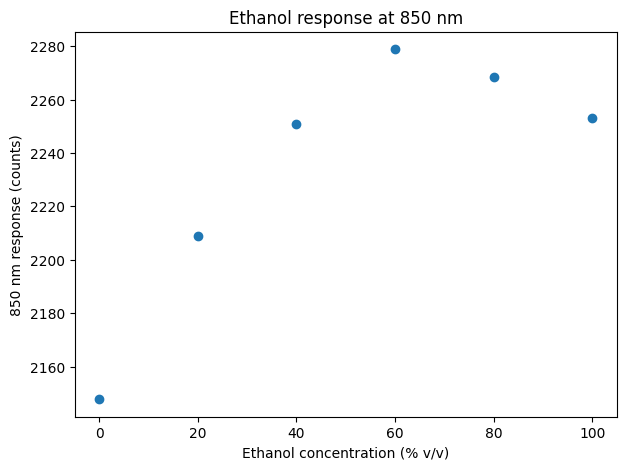

In [ ]:
x = ethanol_means.index.to_numpy()
y850 = ethanol_means["850_full"].to_numpy()

plt.figure(figsize=(7, 5))
plt.scatter(x, y850)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Ethanol response at 850 nm")

plt.show()

In [ ]:
# Linear model
linear_850_coeffs = np.polyfit(x, y850, 1)
linear_850_pred = np.polyval(linear_850_coeffs, x)

linear_850_r2 = r2_score(y850, linear_850_pred)
linear_850_rmse = np.sqrt(
    mean_squared_error(y850, linear_850_pred)
)

# Quadratic model
quadratic_850_coeffs = np.polyfit(x, y850, 2)
quadratic_850_pred = np.polyval(
    quadratic_850_coeffs,
    x
)

quadratic_850_r2 = r2_score(
    y850,
    quadratic_850_pred
)

quadratic_850_rmse = np.sqrt(
    mean_squared_error(
        y850,
        quadratic_850_pred
    )
)

print("Linear coefficients:", linear_850_coeffs)
print("Linear R²:", linear_850_r2)
print("Linear RMSE:", linear_850_rmse)

print()

print("Quadratic coefficients:", quadratic_850_coeffs)
print("Quadratic R²:", quadratic_850_r2)
print("Quadratic RMSE:", quadratic_850_rmse)

Linear coefficients: [1.04745238e+00 2.18221349e+03]
Linear R²: 0.6452558117561831
Linear RMSE: 26.527685813851953

Quadratic coefficients: [-2.63958333e-02  3.68703571e+00  2.14701905e+03]
Quadratic R²: 0.9949213354840752
Quadratic RMSE: 3.174069875840852


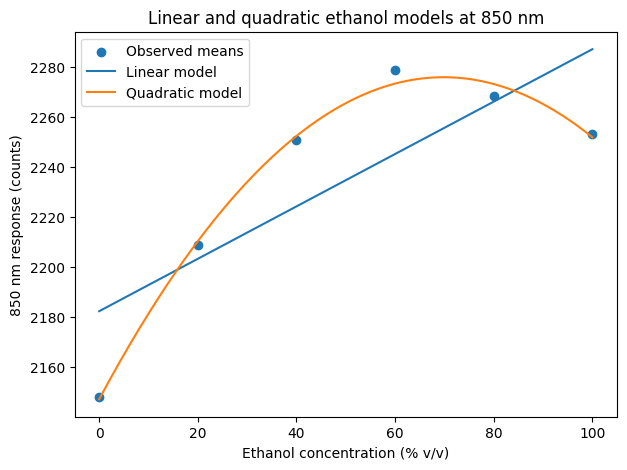

In [ ]:
x_smooth = np.linspace(0, 100, 200)

linear_850_smooth = np.polyval(
    linear_850_coeffs,
    x_smooth
)

quadratic_850_smooth = np.polyval(
    quadratic_850_coeffs,
    x_smooth
)

plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    y850,
    label="Observed means"
)

plt.plot(
    x_smooth,
    linear_850_smooth,
    label="Linear model"
)

plt.plot(
    x_smooth,
    quadratic_850_smooth,
    label="Quadratic model"
)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Linear and quadratic ethanol models at 850 nm")

plt.legend()
plt.show()

In [ ]:
print("Linear coefficients:", linear_850_coeffs)
print("Linear R²:", linear_850_r2)
print("Linear RMSE:", linear_850_rmse)

print()

print("Quadratic coefficients:", quadratic_850_coeffs)
print("Quadratic R²:", quadratic_850_r2)
print("Quadratic RMSE:", quadratic_850_rmse)

a, b, c = quadratic_850_coeffs
peak_concentration = -b / (2 * a)
peak_response = np.polyval(
    quadratic_850_coeffs,
    peak_concentration
)

print()
print(
    "Predicted peak concentration:",
    peak_concentration,
    "% v/v"
)
print(
    "Predicted peak response:",
    peak_response,
    "counts"
)

Linear coefficients: [1.04745238e+00 2.18221349e+03]
Linear R²: 0.6452558117561831
Linear RMSE: 26.527685813851953

Quadratic coefficients: [-2.63958333e-02  3.68703571e+00  2.14701905e+03]
Quadratic R²: 0.9949213354840752
Quadratic RMSE: 3.174069875840852

Predicted peak concentration: 69.84124478520735 % v/v
Predicted peak response: 2275.772629545664 counts


In [ ]:
linear_850_cv_predictions = []
quadratic_850_cv_predictions = []

for i in range(len(x)):

    train_mask = np.arange(len(x)) != i

    x_train = x[train_mask]
    y_train = y850[train_mask]

    x_test = x[i]

    linear_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        2
    )

    linear_850_cv_predictions.append(
        np.polyval(
            linear_coeffs_cv,
            x_test
        )
    )

    quadratic_850_cv_predictions.append(
        np.polyval(
            quadratic_coeffs_cv,
            x_test
        )
    )

linear_850_cv_predictions = np.array(
    linear_850_cv_predictions
)

quadratic_850_cv_predictions = np.array(
    quadratic_850_cv_predictions
)

In [ ]:
linear_850_rmsecv = np.sqrt(
    mean_squared_error(
        y850,
        linear_850_cv_predictions
    )
)

quadratic_850_rmsecv = np.sqrt(
    mean_squared_error(
        y850,
        quadratic_850_cv_predictions
    )
)

linear_850_q2 = calculate_q2(
    y850,
    linear_850_cv_predictions
)

quadratic_850_q2 = calculate_q2(
    y850,
    quadratic_850_cv_predictions
)

print("Linear RMSECV:", linear_850_rmsecv)
print("Linear Q²:", linear_850_q2)

print()

print("Quadratic RMSECV:", quadratic_850_rmsecv)
print("Quadratic Q²:", quadratic_850_q2)

Linear RMSECV: 46.78714999499578
Linear Q²: -0.10349340310558053

Quadratic RMSECV: 5.859416051539276
Quadratic Q²: 0.9826928629958326


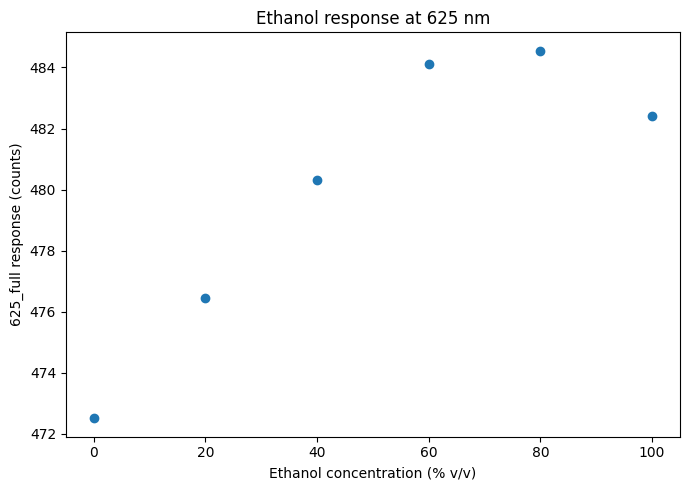

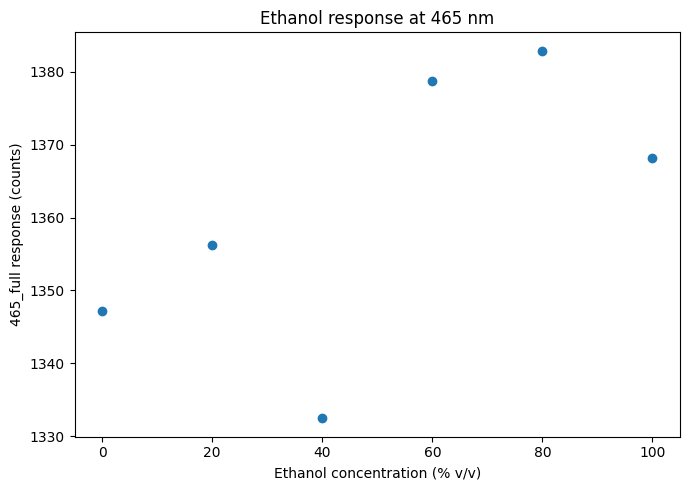

In [ ]:
for channel in ["625_full", "465_full"]:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        ethanol_means.index,
        ethanol_means[channel]
    )

    plt.xlabel("Ethanol concentration (% v/v)")
    plt.ylabel(f"{channel} response (counts)")
    plt.title(f"Ethanol response at {channel.replace('_full', ' nm')}")

    plt.tight_layout()
    plt.show()

In [ ]:
response_625 = ethanol_means["625_full"]

percent_change_625 = (
    (response_625 - response_625.loc[0])
    / response_625.loc[0]
) * 100

comparison_625 = pd.DataFrame({
    "Mean_response": response_625,
    "Change_from_water_%": percent_change_625
})

comparison_625.round(3)

,Mean_response,Change_from_water_%
Concentration,,
0,472.50,0.000
20,476.45,0.836
40,480.30,1.651
60,484.10,2.455
80,484.55,2.550
100,482.40,2.095


In [ ]:
y625 = ethanol_means["625_full"].to_numpy()

# Linear
linear_625_coeffs = np.polyfit(x, y625, 1)
linear_625_pred = np.polyval(linear_625_coeffs, x)

linear_625_r2 = r2_score(y625, linear_625_pred)
linear_625_rmse = np.sqrt(
    mean_squared_error(y625, linear_625_pred)
)

# Quadratic
quadratic_625_coeffs = np.polyfit(x, y625, 2)
quadratic_625_pred = np.polyval(
    quadratic_625_coeffs,
    x
)

quadratic_625_r2 = r2_score(
    y625,
    quadratic_625_pred
)

quadratic_625_rmse = np.sqrt(
    mean_squared_error(
        y625,
        quadratic_625_pred
    )
)

print("Linear R²:", linear_625_r2)
print("Linear RMSE:", linear_625_rmse)

print("Quadratic R²:", quadratic_625_r2)
print("Quadratic RMSE:", quadratic_625_rmse)

Linear R²: 0.7667125031830879
Linear RMSE: 2.0886541576997053
Quadratic R²: 0.9730627705627708
Quadratic RMSE: 0.7097367050365841


In [ ]:
y465 = ethanol_means["465_full"].to_numpy()

linear_465_coeffs = np.polyfit(x, y465, 1)
linear_465_pred = np.polyval(
    linear_465_coeffs,
    x
)

linear_465_r2 = r2_score(
    y465,
    linear_465_pred
)

linear_465_rmse = np.sqrt(
    mean_squared_error(
        y465,
        linear_465_pred
    )
)

print("Linear coefficients:", linear_465_coeffs)
print("Linear R²:", linear_465_r2)
print("Linear RMSE:", linear_465_rmse)

Linear coefficients: [3.30119048e-01 1.34445794e+03]
Linear R²: 0.4071376688640663
Linear RMSE: 13.6066202503947


In [ ]:
linear_465_cv_predictions = []

for i in range(len(x)):

    train_mask = np.arange(len(x)) != i

    coeffs = np.polyfit(
        x[train_mask],
        y465[train_mask],
        1
    )

    prediction = np.polyval(
        coeffs,
        x[i]
    )

    linear_465_cv_predictions.append(
        prediction
    )

linear_465_cv_predictions = np.array(
    linear_465_cv_predictions
)

linear_465_rmsecv = np.sqrt(
    mean_squared_error(
        y465,
        linear_465_cv_predictions
    )
)

linear_465_q2 = calculate_q2(
    y465,
    linear_465_cv_predictions
)

print("Linear RMSECV:", linear_465_rmsecv)
print("Linear Q²:", linear_465_q2)

Linear RMSECV: 18.34389562661859
Linear Q²: -0.07754761592993753


In [ ]:
ethanol_summary = ethanol_precision.pivot(
    index="Concentration",
    columns="Channel",
    values=["Mean", "SD", "RSD"]
).sort_index()

ethanol_summary.round(3)

Mean                                     SD           \
Channel        465_full 625_full  850_full   940_full 465_full 625_full   
Concentration                                                             
0              1347.233   472.50  2147.767  18354.167   11.423    2.606   
20             1356.250   476.45  2208.800  19269.750   17.607    2.051   
40             1332.450   480.30  2250.700  19811.650   49.992    2.404   
60             1378.750   484.10  2278.850  20433.900    2.192    0.707   
80             1382.900   484.55  2268.350  21000.100    6.930    0.071   
100            1368.200   482.40  2253.050  21619.750   21.355    0.424   

                                     RSD                             
Channel       850_full 940_full 465_full 625_full 850_full 940_full  
Concentration                                                        
0               11.711   41.009    0.848    0.551    0.545    0.223  
20               3.111   43.487    1.298    0.430    0.141    0.226  
40               9.617   23.122    3.752    0.501    0.427    0.117  
60              10.677    2.970    0.159    0.146    0.469    0.015  
80               6.293  114.551    0.501    0.015    0.277    0.545  
100             25.809   70.499    1.561    0.088    1.146    0.326

In [ ]:
output_path = (
    "/content/drive/MyDrive/"
    "Project_78/Results/"
    "ethanol_precision_summary.csv"
)

ethanol_precision.to_csv(
    output_path,
    index=False
)

In [ ]:
ethanol_relative = ethanol_means.copy()

for channel in ethanol_relative.columns:

    baseline = ethanol_relative.loc[0, channel]

    ethanol_relative[channel] = (
        (
            ethanol_relative[channel]
            - baseline
        )
        / baseline
    ) * 100

ethanol_relative.round(3)

Channel,465_full,625_full,850_full,940_full
Concentration,,,,
0,0.000,0.000,0.000,0.000
20,0.669,0.836,2.842,4.988
40,-1.097,1.651,4.793,7.941
60,2.339,2.455,6.103,11.331
80,2.647,2.550,5.614,14.416
100,1.556,2.095,4.902,17.792


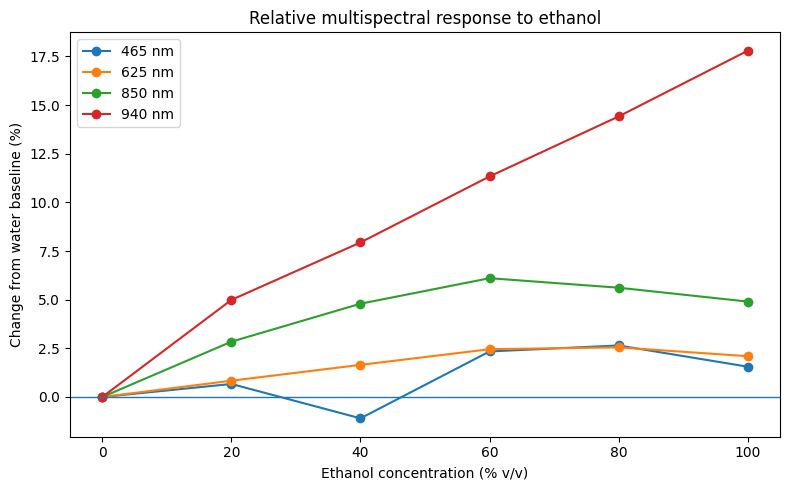

In [ ]:
plt.figure(figsize=(8, 5))

for channel in ethanol_relative.columns:

    wavelength = channel.replace(
        "_full",
        " nm"
    )

    plt.plot(
        ethanol_relative.index,
        ethanol_relative[channel],
        marker="o",
        label=wavelength
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Ethanol concentration (% v/v)")
plt.ylabel("Change from water baseline (%)")
plt.title(
    "Relative multispectral response to ethanol"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "Project_78/Results/"
    "ethanol_relative_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
ethanol_model_summary = pd.DataFrame({
    "Wavelength_nm": [465, 625, 850, 940],

    "Observed_behaviour": [
        "Irregular and non-monotonic",
        "Weak curved response",
        "Strong quadratic non-monotonic response",
        "Strong monotonic approximately linear response"
    ],

    "Recommended_role": [
        "Not suitable for standalone ethanol quantification",
        "Supplementary variable",
        "Multivariate/selectivity variable",
        "Primary concentration indicator"
    ]
})

ethanol_model_summary

,Wavelength_nm,Observed_behaviour,Recommended_role
0,465,Irregular and non-monotonic,Not suitable for standalone ethanol quantifica...
1,625,Weak curved response,Supplementary variable
2,850,Strong quadratic non-monotonic response,Multivariate/selectivity variable
3,940,Strong monotonic approximately linear response,Primary concentration indicator


In [ ]:
ethanol_model_summary.loc[
    ethanol_model_summary["Wavelength_nm"] == 850,
    ["Selected_model", "Q2", "RMSECV_counts"]
] = [
    "Quadratic",
    quadratic_850_q2,
    quadratic_850_rmsecv
]

ethanol_model_summary.loc[
    ethanol_model_summary["Wavelength_nm"] == 940,
    ["Selected_model", "Q2", "RMSECV_counts"]
] = [
    "Linear",
    linear_q2,
    linear_rmsecv
]

ethanol_model_summary

,Wavelength_nm,Observed_behaviour,Recommended_role,Selected_model,Q2,RMSECV_counts
0,465,Irregular and non-monotonic,Not suitable for standalone ethanol quantifica...,NaN,NaN,NaN
1,625,Weak curved response,Supplementary variable,NaN,NaN,NaN
2,850,Strong quadratic non-monotonic response,Multivariate/selectivity variable,Quadratic,0.982693,5.859416
3,940,Strong monotonic approximately linear response,Primary concentration indicator,Linear,0.979153,156.504162


In [ ]:
ethanol_model_summary.to_csv(
    "/content/drive/MyDrive/"
    "Project_78/Results/"
    "ethanol_model_summary.csv",
    index=False
)

### Ethanol analysis conclusion

The 940 nm channel was the most appropriate standalone
indicator of ethanol concentration. It increased monotonically
across 0-100% v/v and produced a linear sensitivity of
31.63 counts per % v/v, R² = 0.9934 and leave-one-level-out
Q² = 0.9792.

The 850 nm response was strongly nonlinear, increasing to a
maximum before declining at higher concentrations. A quadratic
model produced Q² = 0.9827 and RMSECV = 5.86 counts. However,
because the response was non-monotonic, it could not provide a
unique concentration estimate by itself and was retained as a
potential multivariate variable.

The 625 nm response was weak, while the 465 nm response was
irregular and unsuitable for standalone ethanol quantification.
The reported precision represents fill-to-fill repeatability
rather than independent standard-preparation reproducibility.

In [ ]:
methanol20_path = (
    "/content/drive/MyDrive/project_78/Methanol/20%meoh.csv"
)

methanol_20 = pd.read_csv(methanol20_path)

print("Shape:", methanol_20.shape)
methanol_20.head()
print()
print("Columns:")
print(methanol_20.columns.tolist())
print()
print("Data types:")
print(methanol_20.dtypes)
print()
print("Missing values:")
print(methanol_20.isnull().sum())

methanol_20

Shape: (1, 10)

Columns:
['sample', 'replicate', '465_full', '465_IR', '625_full', '625_IR', '850_full', '850_IR', '940_full', '940_IR']

Data types:
sample        object
replicate      int64
465_full     float64
465_IR         int64
625_full     float64
625_IR         int64
850_full     float64
850_IR       float64
940_full       int64
940_IR       float64
dtype: object

Missing values:
sample       0
replicate    0
465_full     0
465_IR       0
625_full     0
625_IR       0
850_full     0
850_IR       0
940_full     0
940_IR       0
dtype: int64


,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,meoh_20,3,1351.9,23,462.1,103,2102.3,1311.4,18889,13528.2


In [ ]:
methanol_20[
    [
        "sample",
        "replicate",
        "465_full",
        "625_full",
        "850_full",
        "940_full"
    ]
]

,sample,replicate,465_full,625_full,850_full,940_full
0,meoh_20,3,1351.9,462.1,2102.3,18889


In [ ]:
methanol_files = {
    0: "/content/drive/MyDrive/project_78/Methanol/water_baseline.csv",
    20: "/content/drive/MyDrive/project_78/Methanol/20%meoh.csv",
    40: "/content/drive/MyDrive/project_78/Methanol/40%meoh.csv",
    60: "/content/drive/MyDrive/project_78/Methanol/60%meoh.csv",
    80: "/content/drive/MyDrive/project_78/Methanol/80%meoh.csv",
    100: "/content/drive/MyDrive/project_78/Methanol/100%meoh.csv"
}

In [ ]:
methanol_rows = []

channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

for concentration, file_path in methanol_files.items():

    df_temp = pd.read_csv(file_path)

    print(
        concentration,
        df_temp.shape
    )

    if len(df_temp) != 1:
        print(
            "Warning:",
            concentration,
            "contains",
            len(df_temp),
            "rows"
        )

    row = {
        "Concentration": concentration
    }

    for channel in channels:
        row[channel] = df_temp[channel].iloc[0]

    methanol_rows.append(row)

0 (1, 10)
20 (1, 10)
40 (1, 10)
60 (1, 10)
80 (1, 10)
100 (1, 10)


In [ ]:
df_temp[channel].iloc[0]

np.float64(20636.6)

In [ ]:
methanol_means = pd.DataFrame(
    methanol_rows
)

methanol_means = (
    methanol_means
    .sort_values("Concentration")
    .set_index("Concentration")
)

methanol_means

,465_full,625_full,850_full,940_full
Concentration,,,,
0,1340.7,463.4,2086.7,18507.2
20,1351.9,462.1,2102.3,18889.0
40,1335.0,462.5,2124.0,19341.3
60,1357.5,461.6,2214.4,20069.1
80,1337.1,466.4,2130.8,20423.1
100,1330.5,462.2,2120.7,20636.6


In [ ]:
print(methanol_means)
print()
print("Missing values:")
print(methanol_means.isnull().sum())

               465_full  625_full  850_full  940_full
Concentration                                        
0                1340.7     463.4    2086.7   18507.2
20               1351.9     462.1    2102.3   18889.0
40               1335.0     462.5    2124.0   19341.3
60               1357.5     461.6    2214.4   20069.1
80               1337.1     466.4    2130.8   20423.1
100              1330.5     462.2    2120.7   20636.6

Missing values:
465_full    0
625_full    0
850_full    0
940_full    0
dtype: int64


### Methanol replication note

Each methanol concentration file contained one saved mean response.
The acquisition program calculated the mean from repeated detector
readings during each run, but the individual readings and displayed
RSD values were not retained. Consequently, standard deviations,
error bars and formal within-run RSD values could not be reconstructed
for the methanol calibration.

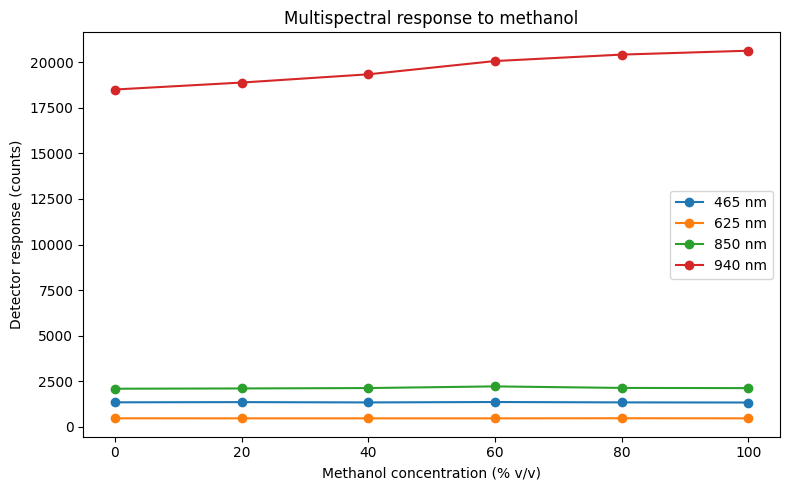

In [ ]:
plt.figure(figsize=(8, 5))

for channel in [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]:
    plt.plot(
        methanol_means.index,
        methanol_means[channel],
        marker="o",
        label=channel.replace("_full", " nm")
    )

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("Detector response (counts)")
plt.title("Multispectral response to methanol")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
methanol_relative = methanol_means.copy()

for channel in methanol_relative.columns:

    baseline = methanol_relative.loc[0, channel]

    methanol_relative[channel] = (
        (
            methanol_relative[channel]
            - baseline
        )
        / baseline
    ) * 100

methanol_relative.round(3)

,465_full,625_full,850_full,940_full
Concentration,,,,
0,0.000,0.000,0.000,0.000
20,0.835,-0.281,0.748,2.063
40,-0.425,-0.194,1.788,4.507
60,1.253,-0.388,6.120,8.439
80,-0.269,0.647,2.113,10.352
100,-0.761,-0.259,1.629,11.506


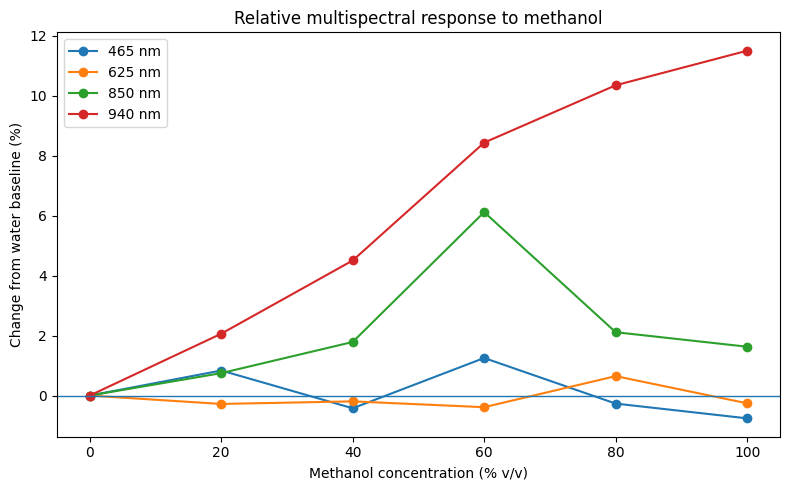

In [ ]:
plt.figure(figsize=(8, 5))

for channel in methanol_relative.columns:

    plt.plot(
        methanol_relative.index,
        methanol_relative[channel],
        marker="o",
        label=channel.replace("_full", " nm")
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("Change from water baseline (%)")
plt.title("Relative multispectral response to methanol")

plt.legend()
plt.tight_layout()
plt.show()

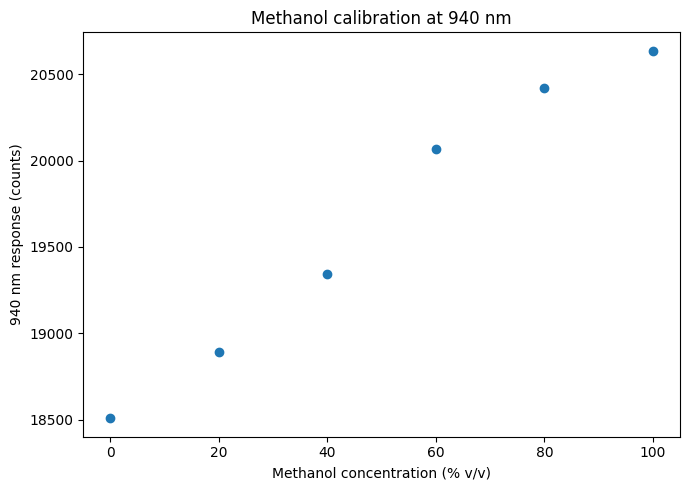

In [ ]:
x_meoh = methanol_means.index.to_numpy()
y940_meoh = methanol_means["940_full"].to_numpy()

plt.figure(figsize=(7, 5))

plt.scatter(
    x_meoh,
    y940_meoh
)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Methanol calibration at 940 nm")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import linregress

methanol_940_reg = linregress(
    x_meoh,
    y940_meoh
)

print("Slope:", methanol_940_reg.slope)
print("Intercept:", methanol_940_reg.intercept)
print("R²:", methanol_940_reg.rvalue**2)

Slope: 22.82442857142855
Intercept: 18503.161904761906
R²: 0.9784687368088205


In [ ]:
methanol_940_pred = (
    methanol_940_reg.intercept
    + methanol_940_reg.slope * x_meoh
)

methanol_940_residuals = (
    y940_meoh
    - methanol_940_pred
)

methanol_940_rmse = np.sqrt(
    mean_squared_error(
        y940_meoh,
        methanol_940_pred
    )
)

print("RMSE:", methanol_940_rmse)

RMSE: 115.64705720972631


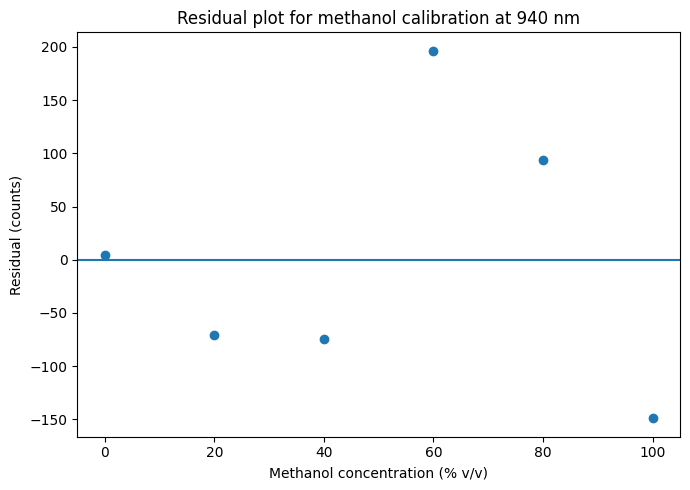

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x_meoh,
    methanol_940_residuals
)

plt.axhline(0)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("Residual (counts)")
plt.title("Residual plot for methanol calibration at 940 nm")

plt.tight_layout()
plt.show()

In [ ]:
print("Slope:", methanol_940_reg.slope)
print("Intercept:", methanol_940_reg.intercept)
print("R²:", methanol_940_reg.rvalue**2)
print("RMSE:", methanol_940_rmse)

Slope: 22.82442857142855
Intercept: 18503.161904761906
R²: 0.9784687368088205
RMSE: 115.64705720972631


In [ ]:
# Linear model
linear_meoh_coeffs = np.polyfit(
    x_meoh,
    y940_meoh,
    1
)

linear_meoh_pred = np.polyval(
    linear_meoh_coeffs,
    x_meoh
)

linear_meoh_r2 = r2_score(
    y940_meoh,
    linear_meoh_pred
)

linear_meoh_rmse = np.sqrt(
    mean_squared_error(
        y940_meoh,
        linear_meoh_pred
    )
)

# Quadratic model
quadratic_meoh_coeffs = np.polyfit(
    x_meoh,
    y940_meoh,
    2
)

quadratic_meoh_pred = np.polyval(
    quadratic_meoh_coeffs,
    x_meoh
)

quadratic_meoh_r2 = r2_score(
    y940_meoh,
    quadratic_meoh_pred
)

quadratic_meoh_rmse = np.sqrt(
    mean_squared_error(
        y940_meoh,
        quadratic_meoh_pred
    )
)

print("Linear coefficients:", linear_meoh_coeffs)
print("Linear R²:", linear_meoh_r2)
print("Linear RMSE:", linear_meoh_rmse)

print()

print("Quadratic coefficients:", quadratic_meoh_coeffs)
print("Quadratic R²:", quadratic_meoh_r2)
print("Quadratic RMSE:", quadratic_meoh_rmse)

Linear coefficients: [   22.82442857 18503.16190476]
Linear R²: 0.97846873680882
Linear RMSE: 115.64705720972744

Quadratic coefficients: [-5.51205357e-02  2.83364821e+01  1.84296679e+04]
Quadratic R²: 0.9833383301781451
Quadratic RMSE: 101.73235385770089


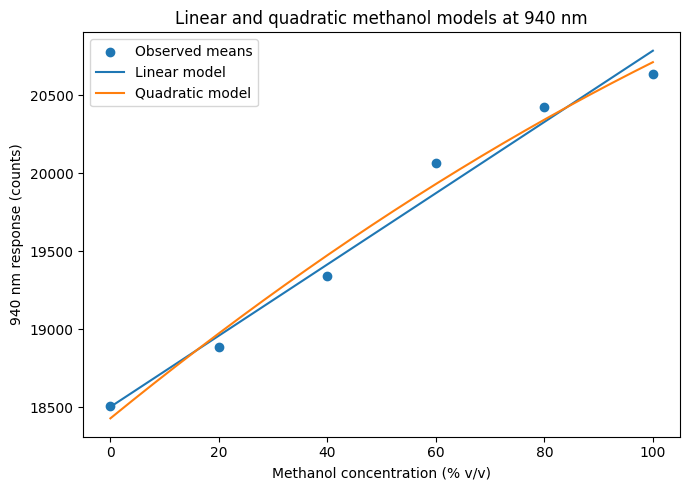

In [ ]:
x_smooth = np.linspace(0, 100, 200)

linear_meoh_smooth = np.polyval(
    linear_meoh_coeffs,
    x_smooth
)

quadratic_meoh_smooth = np.polyval(
    quadratic_meoh_coeffs,
    x_smooth
)

plt.figure(figsize=(7, 5))

plt.scatter(
    x_meoh,
    y940_meoh,
    label="Observed means"
)

plt.plot(
    x_smooth,
    linear_meoh_smooth,
    label="Linear model"
)

plt.plot(
    x_smooth,
    quadratic_meoh_smooth,
    label="Quadratic model"
)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Linear and quadratic methanol models at 940 nm")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
linear_meoh_cv_predictions = []
quadratic_meoh_cv_predictions = []

for i in range(len(x_meoh)):

    train_mask = np.arange(len(x_meoh)) != i

    x_train = x_meoh[train_mask]
    y_train = y940_meoh[train_mask]

    x_test = x_meoh[i]

    linear_cv_coeffs = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_cv_coeffs = np.polyfit(
        x_train,
        y_train,
        2
    )

    linear_meoh_cv_predictions.append(
        np.polyval(
            linear_cv_coeffs,
            x_test
        )
    )

    quadratic_meoh_cv_predictions.append(
        np.polyval(
            quadratic_cv_coeffs,
            x_test
        )
    )

linear_meoh_cv_predictions = np.array(
    linear_meoh_cv_predictions
)

quadratic_meoh_cv_predictions = np.array(
    quadratic_meoh_cv_predictions
)

In [ ]:
linear_meoh_rmsecv = np.sqrt(
    mean_squared_error(
        y940_meoh,
        linear_meoh_cv_predictions
    )
)

quadratic_meoh_rmsecv = np.sqrt(
    mean_squared_error(
        y940_meoh,
        quadratic_meoh_cv_predictions
    )
)

linear_meoh_q2 = calculate_q2(
    y940_meoh,
    linear_meoh_cv_predictions
)

quadratic_meoh_q2 = calculate_q2(
    y940_meoh,
    quadratic_meoh_cv_predictions
)

print("Linear RMSECV:", linear_meoh_rmsecv)
print("Linear Q²:", linear_meoh_q2)

print()

print("Quadratic RMSECV:", quadratic_meoh_rmsecv)
print("Quadratic Q²:", quadratic_meoh_q2)

Linear RMSECV: 178.7497334528501
Linear Q²: 0.9485611627188864

Quadratic RMSECV: 285.41363331493886
Quadratic Q²: 0.8688555953611197


In [ ]:
print(
    f"Slope: {methanol_940_reg.slope:.3f} "
    "counts per % v/v"
)

print(
    f"Intercept: {methanol_940_reg.intercept:.3f} "
    "counts"
)

print(
    f"R²: {methanol_940_reg.rvalue**2:.4f}"
)

print(
    f"Calibration RMSE: {methanol_940_rmse:.3f} "
    "counts"
)

print(
    f"Linear RMSECV: {linear_meoh_rmsecv:.3f} "
    "counts"
)

print(
    f"Linear Q²: {linear_meoh_q2:.4f}"
)

Slope: 22.824 counts per % v/v
Intercept: 18503.162 counts
R²: 0.9785
Calibration RMSE: 115.647 counts
Linear RMSECV: 178.750 counts
Linear Q²: 0.9486


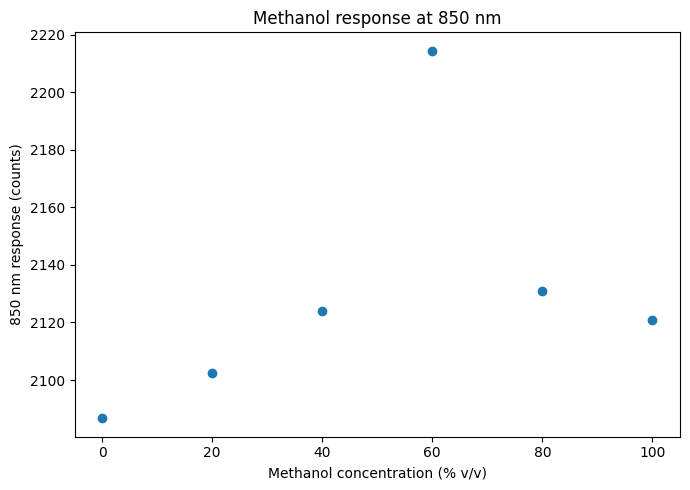

In [ ]:
x_meoh = methanol_means.index.to_numpy()
y850_meoh = methanol_means["850_full"].to_numpy()

plt.figure(figsize=(7, 5))

plt.scatter(x_meoh, y850_meoh)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Methanol response at 850 nm")

plt.tight_layout()
plt.show()

In [ ]:
# Linear model
linear_850_meoh_coeffs = np.polyfit(
    x_meoh,
    y850_meoh,
    1
)

linear_850_meoh_pred = np.polyval(
    linear_850_meoh_coeffs,
    x_meoh
)

linear_850_meoh_r2 = r2_score(
    y850_meoh,
    linear_850_meoh_pred
)

linear_850_meoh_rmse = np.sqrt(
    mean_squared_error(
        y850_meoh,
        linear_850_meoh_pred
    )
)

# Quadratic model
quadratic_850_meoh_coeffs = np.polyfit(
    x_meoh,
    y850_meoh,
    2
)

quadratic_850_meoh_pred = np.polyval(
    quadratic_850_meoh_coeffs,
    x_meoh
)

quadratic_850_meoh_r2 = r2_score(
    y850_meoh,
    quadratic_850_meoh_pred
)

quadratic_850_meoh_rmse = np.sqrt(
    mean_squared_error(
        y850_meoh,
        quadratic_850_meoh_pred
    )
)

print("Linear R²:", linear_850_meoh_r2)
print("Linear RMSE:", linear_850_meoh_rmse)

print()
print("Quadratic coefficients:", quadratic_850_meoh_coeffs)
print("Quadratic R²:", quadratic_850_meoh_r2)
print("Quadratic RMSE:", quadratic_850_meoh_rmse)

Linear R²: 0.17285185988768448
Linear RMSE: 36.92160205642088

Quadratic coefficients: [-2.45401786e-02  2.94816071e+00  2.07238929e+03]
Quadratic R²: 0.5366354970425289
Quadratic RMSE: 27.634414577617118


In [ ]:
linear_850_meoh_cv_predictions = []
quadratic_850_meoh_cv_predictions = []

for i in range(len(x_meoh)):

    train_mask = np.arange(len(x_meoh)) != i

    x_train = x_meoh[train_mask]
    y_train = y850_meoh[train_mask]

    x_test = x_meoh[i]

    linear_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        2
    )

    linear_850_meoh_cv_predictions.append(
        np.polyval(
            linear_coeffs_cv,
            x_test
        )
    )

    quadratic_850_meoh_cv_predictions.append(
        np.polyval(
            quadratic_coeffs_cv,
            x_test
        )
    )

linear_850_meoh_cv_predictions = np.array(
    linear_850_meoh_cv_predictions
)

quadratic_850_meoh_cv_predictions = np.array(
    quadratic_850_meoh_cv_predictions
)

methanol_850_cv_results = pd.DataFrame({
    "Concentration": x_meoh,
    "Observed": y850_meoh,
    "Linear_prediction": linear_850_meoh_cv_predictions,
    "Quadratic_prediction": quadratic_850_meoh_cv_predictions
})

methanol_850_cv_results["Linear_error"] = (
    methanol_850_cv_results["Observed"]
    - methanol_850_cv_results["Linear_prediction"]
)

methanol_850_cv_results["Quadratic_error"] = (
    methanol_850_cv_results["Observed"]
    - methanol_850_cv_results["Quadratic_prediction"]
)

methanol_850_cv_results.round(2)

,Concentration,Observed,Linear_prediction,Quadratic_prediction,Linear_error,Quadratic_error
0,0,2086.7,2125.36,2006.56,-38.66,80.14
1,20,2102.3,2120.31,2130.06,-18.01,-27.76
2,40,2124.0,2125.07,2167.04,-1.07,-43.04
3,60,2214.4,2117.16,2129.34,97.24,85.06
4,80,2130.8,2150.44,2160.22,-19.64,-29.42
5,100,2120.7,2191.73,2126.88,-71.03,-6.18


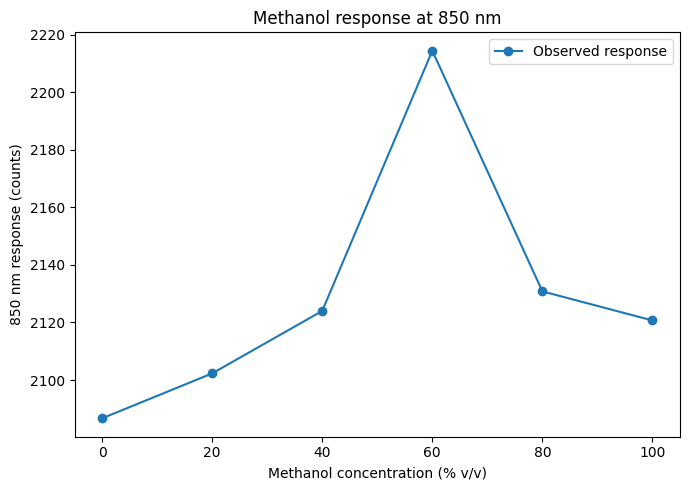

In [ ]:
x_meoh = methanol_means.index.to_numpy()
y850_meoh = methanol_means["850_full"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    x_meoh,
    y850_meoh,
    marker="o",
    linestyle="-",
    label="Observed response"
)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Methanol response at 850 nm")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "methanol_850_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

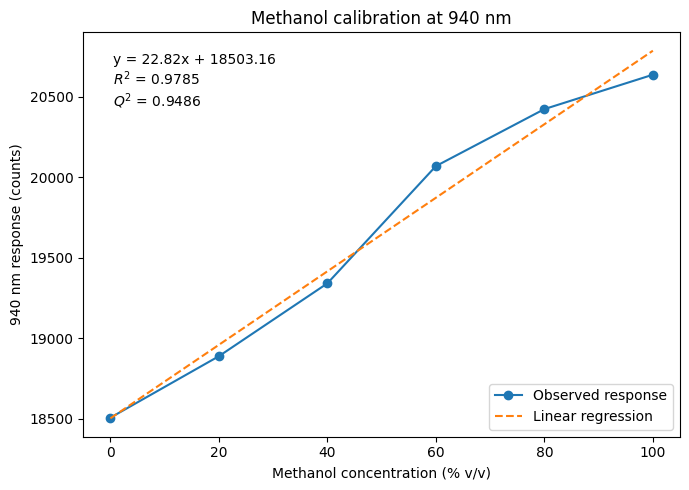

In [ ]:
x_meoh = methanol_means.index.to_numpy()
y940_meoh = methanol_means["940_full"].to_numpy()

reg_940_meoh = linregress(
    x_meoh,
    y940_meoh
)

x_smooth = np.linspace(0, 100, 200)

y940_fit = (
    reg_940_meoh.intercept
    + reg_940_meoh.slope * x_smooth
)

plt.figure(figsize=(7, 5))

# Connect the observed measurements
plt.plot(
    x_meoh,
    y940_meoh,
    marker="o",
    linestyle="-",
    label="Observed response"
)

# Add the fitted linear model
plt.plot(
    x_smooth,
    y940_fit,
    linestyle="--",
    label="Linear regression"
)

equation_text = (
    f"y = {reg_940_meoh.slope:.2f}x "
    f"+ {reg_940_meoh.intercept:.2f}\n"
    f"$R^2$ = {reg_940_meoh.rvalue**2:.4f}\n"
    f"$Q^2$ = {linear_meoh_q2:.4f}"
)

plt.text(
    0.05,
    0.95,
    equation_text,
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Methanol calibration at 940 nm")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "methanol_940_calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

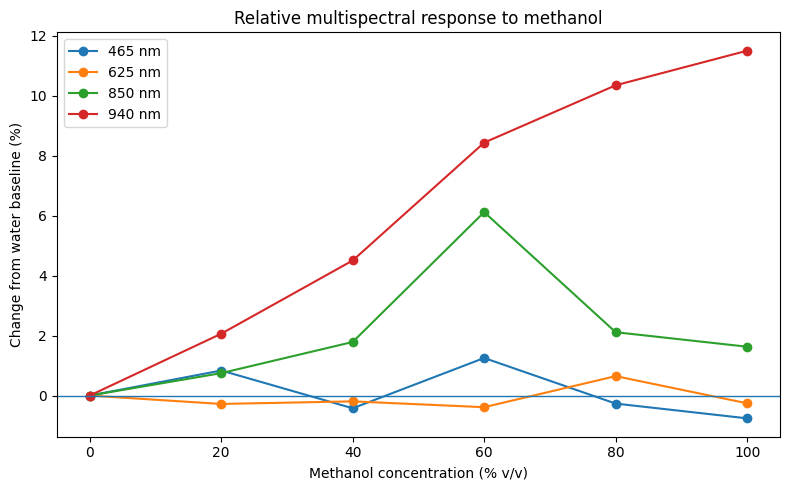

In [ ]:
plt.figure(figsize=(8, 5))

for channel in methanol_relative.columns:

    plt.plot(
        methanol_relative.index,
        methanol_relative[channel],
        marker="o",
        linestyle="-",
        label=channel.replace("_full", " nm")
    )

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Methanol concentration (% v/v)")
plt.ylabel("Change from water baseline (%)")
plt.title("Relative multispectral response to methanol")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "methanol_relative_multispectral_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
methanol_range_summary = []

for channel in methanol_relative.columns:

    relative_values = methanol_relative[channel]

    maximum_change = relative_values.max()
    minimum_change = relative_values.min()

    maximum_concentration = relative_values.idxmax()
    minimum_concentration = relative_values.idxmin()

    methanol_range_summary.append({
        "Channel": channel,
        "Minimum_change_%": minimum_change,
        "Minimum_at_%vv": minimum_concentration,
        "Maximum_change_%": maximum_change,
        "Maximum_at_%vv": maximum_concentration,
        "Total_range_percentage_points":
            maximum_change - minimum_change
    })

methanol_range_summary = pd.DataFrame(
    methanol_range_summary
)

methanol_range_summary.round(3)

,Channel,Minimum_change_%,Minimum_at_%vv,Maximum_change_%,Maximum_at_%vv,Total_range_percentage_points
0,465_full,-0.761,100,1.253,60,2.014
1,625_full,-0.388,60,0.647,80,1.036
2,850_full,0.000,0,6.120,60,6.120
3,940_full,0.000,0,11.506,100,11.506


In [ ]:
methanol_model_summary = pd.DataFrame({
    "Wavelength_nm": [465, 625, 850, 940],

    "Observed_behaviour": [
        "Small irregular response",
        "Very weak response near baseline",
        "Non-monotonic response with maximum at 60%",
        "Strong monotonic increase"
    ],

    "Selected_model": [
        "None",
        "None",
        "No quantitative model selected",
        "Linear"
    ],

    "Recommended_role": [
        "Not suitable for standalone methanol quantification",
        "Limited value for clear methanol standards",
        "Potential multivariate/selectivity variable",
        "Primary methanol concentration indicator"
    ]
})

methanol_model_summary

,Wavelength_nm,Observed_behaviour,Selected_model,Recommended_role
0,465,Small irregular response,None,Not suitable for standalone methanol quantific...
1,625,Very weak response near baseline,None,Limited value for clear methanol standards
2,850,Non-monotonic response with maximum at 60%,No quantitative model selected,Potential multivariate/selectivity variable
3,940,Strong monotonic increase,Linear,Primary methanol concentration indicator


In [ ]:
methanol_model_summary.loc[
    methanol_model_summary["Wavelength_nm"] == 940,
    ["R2", "Q2", "RMSE_counts", "RMSECV_counts"]
] = [
    0.9785,
    0.9486,
    115.647,
    178.750
]

methanol_model_summary

,Wavelength_nm,Observed_behaviour,Selected_model,Recommended_role,R2,Q2,RMSE_counts,RMSECV_counts
0,465,Small irregular response,None,Not suitable for standalone methanol quantific...,NaN,NaN,NaN,NaN
1,625,Very weak response near baseline,None,Limited value for clear methanol standards,NaN,NaN,NaN,NaN
2,850,Non-monotonic response with maximum at 60%,No quantitative model selected,Potential multivariate/selectivity variable,NaN,NaN,NaN,NaN
3,940,Strong monotonic increase,Linear,Primary methanol concentration indicator,0.9785,0.9486,115.647,178.75


In [ ]:
methanol_model_summary.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "methanol_model_summary.csv",
    index=False
)

### Acetone replication note

Each acetone concentration was represented by one saved acquisition
mean. The acquisition program calculated statistics from repeated
readings during each run, but the individual readings and displayed
RSD values were not retained. Therefore, standard deviations, error
bars and formal within-run precision values could not be reconstructed
for the acetone calibration.

In [ ]:
acetone_files = {
    0: "/content/drive/MyDrive/project_78/Acetone/water_baseline.csv",
    20: "/content/drive/MyDrive/project_78/Acetone/20%acetone.csv",
    40: "/content/drive/MyDrive/project_78/Acetone/40%acetone.csv",
    60: "/content/drive/MyDrive/project_78/Acetone/60%acetone.csv",
    80: "/content/drive/MyDrive/project_78/Acetone/80%acetone.csv",
    100: "/content/drive/MyDrive/project_78/Acetone/100%acetone.csv"
}

In [ ]:
channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

acetone_rows = []

for concentration, file_path in acetone_files.items():

    df_temp = pd.read_csv(file_path)

    print(
        f"{concentration}% acetone:",
        df_temp.shape
    )

    if len(df_temp) != 1:
        print(
            f"Warning: {concentration}% contains "
            f"{len(df_temp)} rows"
        )

    row = {
        "Concentration": concentration
    }

    for channel in channels:
        row[channel] = df_temp[channel].iloc[0]

    acetone_rows.append(row)

0% acetone: (1, 10)
20% acetone: (1, 10)
40% acetone: (1, 10)
60% acetone: (1, 10)
80% acetone: (1, 10)
100% acetone: (1, 10)


In [ ]:
acetone_means = pd.DataFrame(acetone_rows)

acetone_means = (
    acetone_means
    .sort_values("Concentration")
    .set_index("Concentration")
)

acetone_means

,465_full,625_full,850_full,940_full
Concentration,,,,
0,1340.7,463.4,2086.7,18507.2
20,1353.9,460.1,2104.1,18967.0
40,1353.7,461.7,2123.5,19868.2
60,1370.0,472.3,2157.8,20744.5
80,1374.6,471.0,2245.1,21714.2
100,1351.4,470.9,2293.4,22855.1


In [ ]:
acetone_means = pd.DataFrame(acetone_rows)

acetone_means = (
    acetone_means
    .sort_values("Concentration")
    .set_index("Concentration")
)

acetone_means

,465_full,625_full,850_full,940_full
Concentration,,,,
0,1340.7,463.4,2086.7,18507.2
20,1353.9,460.1,2104.1,18967.0
40,1353.7,461.7,2123.5,19868.2
60,1370.0,472.3,2157.8,20744.5
80,1374.6,471.0,2245.1,21714.2
100,1351.4,470.9,2293.4,22855.1


In [ ]:
print(acetone_means)

print("\nMissing values:")
print(acetone_means.isnull().sum())

               465_full  625_full  850_full  940_full
Concentration                                        
0                1340.7     463.4    2086.7   18507.2
20               1353.9     460.1    2104.1   18967.0
40               1353.7     461.7    2123.5   19868.2
60               1370.0     472.3    2157.8   20744.5
80               1374.6     471.0    2245.1   21714.2
100              1351.4     470.9    2293.4   22855.1

Missing values:
465_full    0
625_full    0
850_full    0
940_full    0
dtype: int64


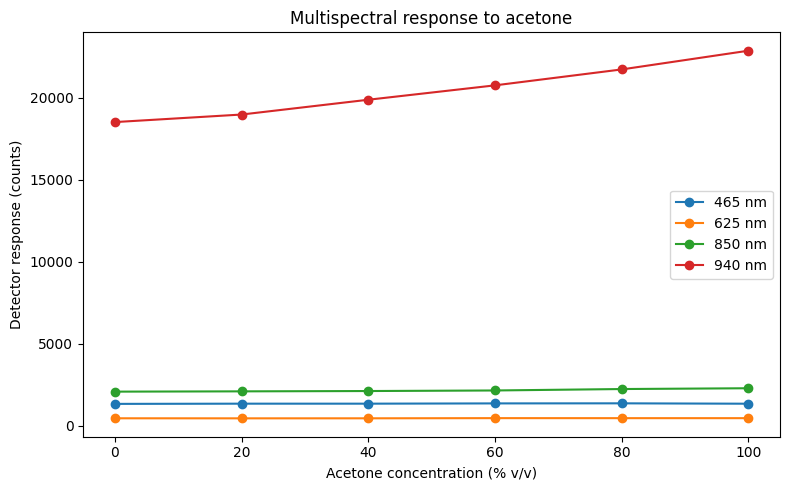

In [ ]:
plt.figure(figsize=(8, 5))

for channel in channels:

    plt.plot(
        acetone_means.index,
        acetone_means[channel],
        marker="o",
        linestyle="-",
        label=channel.replace("_full", " nm")
    )

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("Detector response (counts)")
plt.title("Multispectral response to acetone")

plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
acetone_relative = acetone_means.copy()

for channel in acetone_relative.columns:

    water_baseline = acetone_relative.loc[
        0,
        channel
    ]

    acetone_relative[channel] = (
        (
            acetone_relative[channel]
            - water_baseline
        )
        / water_baseline
    ) * 100

acetone_relative.round(3)

,465_full,625_full,850_full,940_full
Concentration,,,,
0,0.000,0.000,0.000,0.000
20,0.985,-0.712,0.834,2.484
40,0.970,-0.367,1.764,7.354
60,2.185,1.921,3.407,12.089
80,2.529,1.640,7.591,17.328
100,0.798,1.618,9.906,23.493


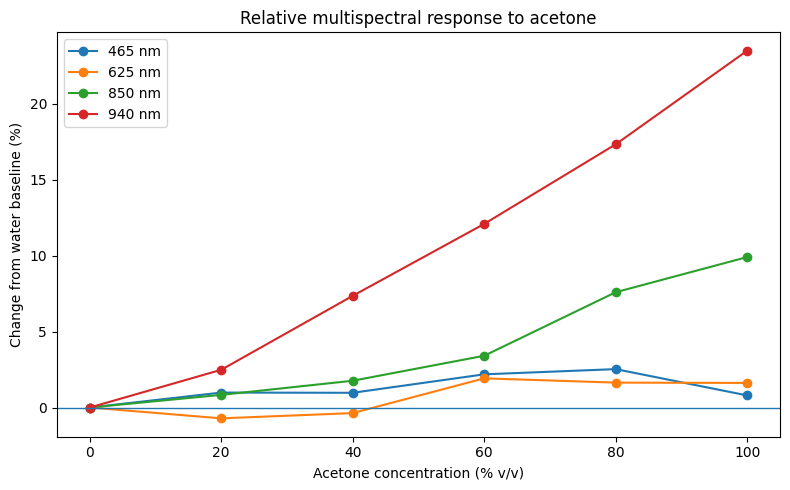

In [ ]:
plt.figure(figsize=(8, 5))

for channel in acetone_relative.columns:

    plt.plot(
        acetone_relative.index,
        acetone_relative[channel],
        marker="o",
        linestyle="-",
        label=channel.replace("_full", " nm")
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("Change from water baseline (%)")
plt.title("Relative multispectral response to acetone")

plt.legend()
plt.tight_layout()
plt.show()

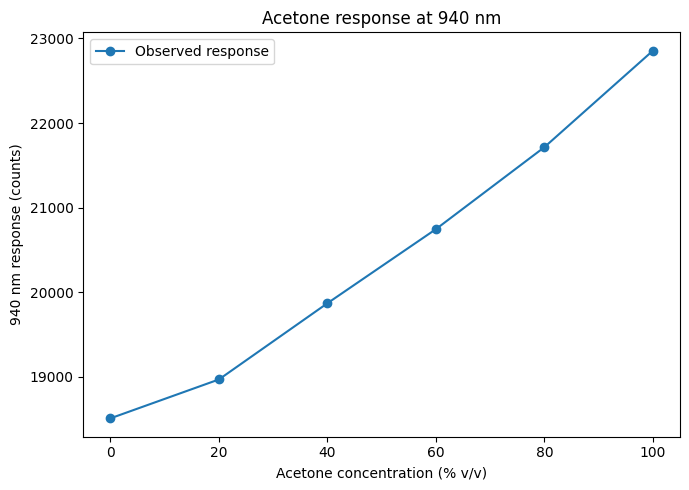

In [ ]:
x_acetone = acetone_means.index.to_numpy()
y940_acetone = acetone_means["940_full"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    x_acetone,
    y940_acetone,
    marker="o",
    linestyle="-",
    label="Observed response"
)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Acetone response at 940 nm")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import linregress

x_acetone = acetone_means.index.to_numpy()
y940_acetone = acetone_means["940_full"].to_numpy()

acetone_940_reg = linregress(
    x_acetone,
    y940_acetone
)

acetone_940_pred = (
    acetone_940_reg.intercept
    + acetone_940_reg.slope * x_acetone
)

acetone_940_residuals = (
    y940_acetone - acetone_940_pred
)

acetone_940_rmse = np.sqrt(
    mean_squared_error(
        y940_acetone,
        acetone_940_pred
    )
)

print(
    f"Slope: {acetone_940_reg.slope:.3f} "
    "counts per % v/v"
)

print(
    f"Intercept: {acetone_940_reg.intercept:.3f} counts"
)

print(
    f"R²: {acetone_940_reg.rvalue**2:.4f}"
)

print(
    f"RMSE: {acetone_940_rmse:.3f} counts"
)

Slope: 44.082 counts per % v/v
Intercept: 18238.600 counts
R²: 0.9870
RMSE: 172.632 counts


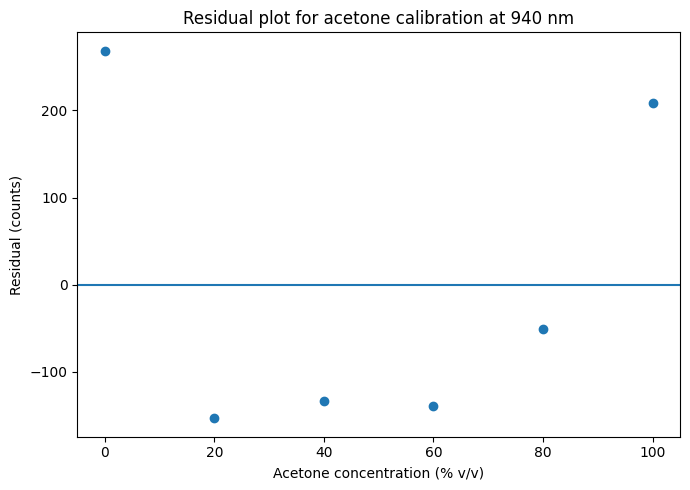

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x_acetone,
    acetone_940_residuals
)

plt.axhline(0)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("Residual (counts)")
plt.title(
    "Residual plot for acetone calibration at 940 nm"
)

plt.tight_layout()
plt.show()

In [ ]:
linear_acetone_cv = []
quadratic_acetone_cv = []

for i in range(len(x_acetone)):

    train_mask = (
        np.arange(len(x_acetone)) != i
    )

    x_train = x_acetone[train_mask]
    y_train = y940_acetone[train_mask]

    x_test = x_acetone[i]

    linear_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        2
    )

    linear_acetone_cv.append(
        np.polyval(
            linear_coeffs_cv,
            x_test
        )
    )

    quadratic_acetone_cv.append(
        np.polyval(
            quadratic_coeffs_cv,
            x_test
        )
    )

linear_acetone_cv = np.array(
    linear_acetone_cv
)

quadratic_acetone_cv = np.array(
    quadratic_acetone_cv
)

In [ ]:
linear_acetone_rmsecv = np.sqrt(
    mean_squared_error(
        y940_acetone,
        linear_acetone_cv
    )
)

quadratic_acetone_rmsecv = np.sqrt(
    mean_squared_error(
        y940_acetone,
        quadratic_acetone_cv
    )
)

linear_acetone_q2 = calculate_q2(
    y940_acetone,
    linear_acetone_cv
)

quadratic_acetone_q2 = calculate_q2(
    y940_acetone,
    quadratic_acetone_cv
)

print("Linear RMSECV:", linear_acetone_rmsecv)
print("Linear Q²:", linear_acetone_q2)

print()

print(
    "Quadratic RMSECV:",
    quadratic_acetone_rmsecv
)

print(
    "Quadratic Q²:",
    quadratic_acetone_q2
)

Linear RMSECV: 320.79679955373933
Linear Q²: 0.9551957817785518

Quadratic RMSECV: 137.49792295026916
Quadratic Q²: 0.9917690279762901


In [ ]:
quadratic_acetone_coeffs = np.polyfit(x_acetone, y940_acetone, 2)
quadratic_acetone_pred = np.polyval(quadratic_acetone_coeffs, x_acetone)

quadratic_acetone_r2 = r2_score(y940_acetone, quadratic_acetone_pred)
quadratic_acetone_rmse = np.sqrt(
    mean_squared_error(y940_acetone, quadratic_acetone_pred)
)

print("Quadratic coefficients:", quadratic_acetone_coeffs)
print("Quadratic R²:", quadratic_acetone_r2)
print("Quadratic RMSE:", quadratic_acetone_rmse)
print("Quadratic RMSECV:", quadratic_acetone_rmsecv)
print("Quadratic Q²:", quadratic_acetone_q2)

Quadratic coefficients: [1.64263393e-01 2.76556607e+01 1.84576179e+04]
Quadratic R²: 0.9987203064266147
Quadratic RMSE: 54.21551273785625
Quadratic RMSECV: 137.49792295026916
Quadratic Q²: 0.9917690279762901


In [ ]:
a, b, c = quadratic_acetone_coeffs

# Location of the quadratic turning point
vertex_concentration = -b / (2 * a)

# Predicted values over the calibration range
x_dense = np.linspace(0, 100, 1001)
y_dense = np.polyval(
    quadratic_acetone_coeffs,
    x_dense
)

is_monotonic_increasing = np.all(
    np.diff(y_dense) > 0
)

print(
    "Quadratic turning point:",
    vertex_concentration,
    "% v/v"
)

print(
    "Monotonic increase from 0–100%:",
    is_monotonic_increasing
)

Quadratic turning point: -84.18083978801346 % v/v
Monotonic increase from 0–100%: True


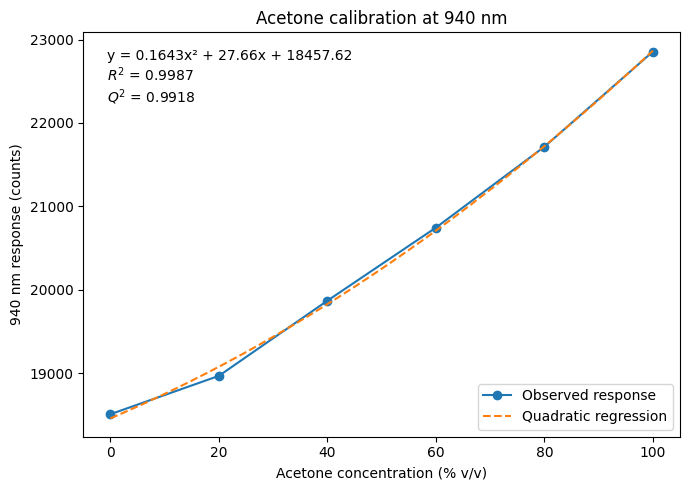

In [ ]:
x_acetone = acetone_means.index.to_numpy()
y940_acetone = acetone_means["940_full"].to_numpy()

x_smooth = np.linspace(0, 100, 300)

quadratic_smooth = np.polyval(
    quadratic_acetone_coeffs,
    x_smooth
)

a, b, c = quadratic_acetone_coeffs

plt.figure(figsize=(7, 5))

# Connect measured responses as a guide to the eye
plt.plot(
    x_acetone,
    y940_acetone,
    marker="o",
    linestyle="-",
    label="Observed response"
)

# Selected quadratic model
plt.plot(
    x_smooth,
    quadratic_smooth,
    linestyle="--",
    label="Quadratic regression"
)

equation_text = (
    f"y = {a:.4f}x² "
    f"+ {b:.2f}x "
    f"+ {c:.2f}\n"
    f"$R^2$ = {quadratic_acetone_r2:.4f}\n"
    f"$Q^2$ = {quadratic_acetone_q2:.4f}"
)

plt.text(
    0.04,
    0.96,
    equation_text,
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("940 nm response (counts)")
plt.title("Acetone calibration at 940 nm")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "acetone_940_quadratic_calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

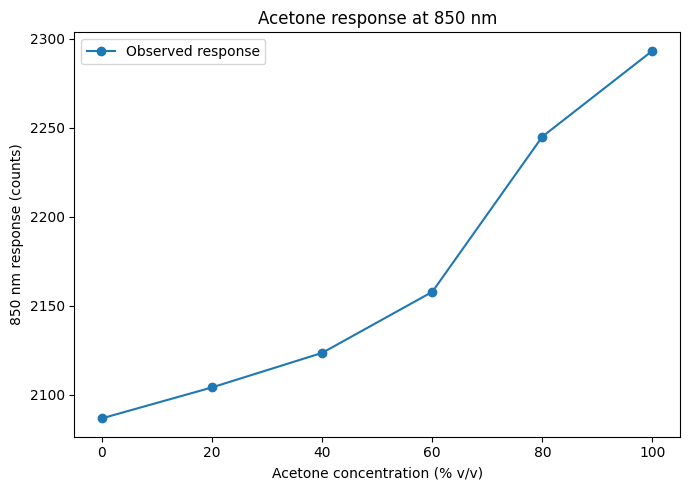

In [ ]:
x_acetone = acetone_means.index.to_numpy()
y850_acetone = acetone_means["850_full"].to_numpy()

plt.figure(figsize=(7, 5))

plt.plot(
    x_acetone,
    y850_acetone,
    marker="o",
    linestyle="-",
    label="Observed response"
)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Acetone response at 850 nm")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
x_acetone = acetone_means.index.to_numpy()
y850_acetone = acetone_means["850_full"].to_numpy()

# Linear model
linear_850_acetone_coeffs = np.polyfit(
    x_acetone,
    y850_acetone,
    1
)

linear_850_acetone_pred = np.polyval(
    linear_850_acetone_coeffs,
    x_acetone
)

linear_850_acetone_r2 = r2_score(
    y850_acetone,
    linear_850_acetone_pred
)

linear_850_acetone_rmse = np.sqrt(
    mean_squared_error(
        y850_acetone,
        linear_850_acetone_pred
    )
)

# Quadratic model
quadratic_850_acetone_coeffs = np.polyfit(
    x_acetone,
    y850_acetone,
    2
)

quadratic_850_acetone_pred = np.polyval(
    quadratic_850_acetone_coeffs,
    x_acetone
)

quadratic_850_acetone_r2 = r2_score(
    y850_acetone,
    quadratic_850_acetone_pred
)

quadratic_850_acetone_rmse = np.sqrt(
    mean_squared_error(
        y850_acetone,
        quadratic_850_acetone_pred
    )
)

print("Linear coefficients:", linear_850_acetone_coeffs)
print("Linear R²:", linear_850_acetone_r2)
print("Linear RMSE:", linear_850_acetone_rmse)

print()

print("Quadratic coefficients:", quadratic_850_acetone_coeffs)
print("Quadratic R²:", quadratic_850_acetone_r2)
print("Quadratic RMSE:", quadratic_850_acetone_rmse)

Linear coefficients: [   2.12971429 2061.94761905]
Linear R²: 0.9217360082824796
Linear RMSE: 21.196905284753043

Quadratic coefficients: [1.90223214e-02 2.27482143e-01 2.08731071e+03]
Quadratic R²: 0.984485412692438
Quadratic RMSE: 9.437600204450542


In [ ]:
a850, b850, c850 = quadratic_850_acetone_coeffs

x_dense = np.linspace(0, 100, 1001)

quadratic_850_dense = np.polyval(
    quadratic_850_acetone_coeffs,
    x_dense
)

is_monotonic_850 = np.all(
    np.diff(quadratic_850_dense) > 0
)

turning_point_850 = (
    -b850 / (2 * a850)
)

print(
    "Turning point:",
    turning_point_850,
    "% v/v"
)

print(
    "Monotonically increasing from 0–100%:",
    is_monotonic_850
)

Turning point: -5.979347570992861 % v/v
Monotonically increasing from 0–100%: True


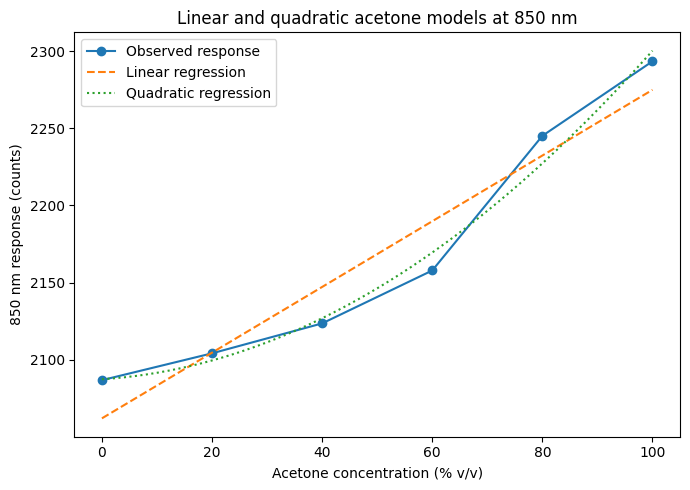

In [ ]:
x_smooth = np.linspace(0, 100, 300)

linear_850_smooth = np.polyval(
    linear_850_acetone_coeffs,
    x_smooth
)

quadratic_850_smooth = np.polyval(
    quadratic_850_acetone_coeffs,
    x_smooth
)

plt.figure(figsize=(7, 5))

plt.plot(
    x_acetone,
    y850_acetone,
    marker="o",
    linestyle="-",
    label="Observed response"
)

plt.plot(
    x_smooth,
    linear_850_smooth,
    linestyle="--",
    label="Linear regression"
)

plt.plot(
    x_smooth,
    quadratic_850_smooth,
    linestyle=":",
    label="Quadratic regression"
)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Linear and quadratic acetone models at 850 nm")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
linear_850_acetone_cv_predictions = []
quadratic_850_acetone_cv_predictions = []

for i in range(len(x_acetone)):

    train_mask = np.arange(len(x_acetone)) != i

    x_train = x_acetone[train_mask]
    y_train = y850_acetone[train_mask]

    x_test = x_acetone[i]

    linear_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        1
    )

    quadratic_coeffs_cv = np.polyfit(
        x_train,
        y_train,
        2
    )

    linear_850_acetone_cv_predictions.append(
        np.polyval(
            linear_coeffs_cv,
            x_test
        )
    )

    quadratic_850_acetone_cv_predictions.append(
        np.polyval(
            quadratic_coeffs_cv,
            x_test
        )
    )

linear_850_acetone_cv_predictions = np.array(
    linear_850_acetone_cv_predictions
)

quadratic_850_acetone_cv_predictions = np.array(
    quadratic_850_acetone_cv_predictions
)

linear_850_acetone_rmsecv = np.sqrt(
    mean_squared_error(
        y850_acetone,
        linear_850_acetone_cv_predictions
    )
)

quadratic_850_acetone_rmsecv = np.sqrt(
    mean_squared_error(
        y850_acetone,
        quadratic_850_acetone_cv_predictions
    )
)

linear_850_acetone_q2 = calculate_q2(
    y850_acetone,
    linear_850_acetone_cv_predictions
)

quadratic_850_acetone_q2 = calculate_q2(
    y850_acetone,
    quadratic_850_acetone_cv_predictions
)

print(
    "Linear RMSECV:",
    linear_850_acetone_rmsecv
)

print(
    "Linear Q²:",
    linear_850_acetone_q2
)

print()

print(
    "Quadratic RMSECV:",
    quadratic_850_acetone_rmsecv
)

print(
    "Quadratic Q²:",
    quadratic_850_acetone_q2
)

Linear RMSECV: 33.886408651750635
Linear Q²: 0.7999824221198634

Quadratic RMSECV: 20.72244637257427
Quadratic Q²: 0.925200425927661


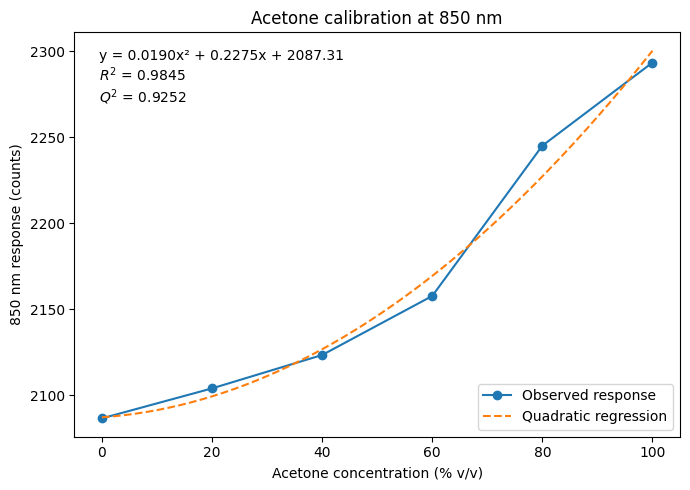

In [ ]:
x_acetone = acetone_means.index.to_numpy()
y850_acetone = acetone_means["850_full"].to_numpy()

x_smooth = np.linspace(0, 100, 300)

quadratic_850_smooth = np.polyval(
    quadratic_850_acetone_coeffs,
    x_smooth
)

a850, b850, c850 = quadratic_850_acetone_coeffs

plt.figure(figsize=(7, 5))

# Connected measured responses
plt.plot(
    x_acetone,
    y850_acetone,
    marker="o",
    linestyle="-",
    label="Observed response"
)

# Selected quadratic model
plt.plot(
    x_smooth,
    quadratic_850_smooth,
    linestyle="--",
    label="Quadratic regression"
)

equation_text = (
    f"y = {a850:.4f}x² "
    f"+ {b850:.4f}x "
    f"+ {c850:.2f}\n"
    f"$R^2$ = {quadratic_850_acetone_r2:.4f}\n"
    f"$Q^2$ = {quadratic_850_acetone_q2:.4f}"
)

plt.text(
    0.04,
    0.96,
    equation_text,
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.xlabel("Acetone concentration (% v/v)")
plt.ylabel("850 nm response (counts)")
plt.title("Acetone calibration at 850 nm")

plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "acetone_850_quadratic_calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def prepare_solvent_table(df, solvent_name):
    table = df.reset_index().copy()
    table["Solvent"] = solvent_name

    return table[
        [
            "Solvent",
            "Concentration",
            "465_full",
            "625_full",
            "850_full",
            "940_full"
        ]
    ]


ethanol_table = prepare_solvent_table(
    ethanol_means,
    "Ethanol"
)

methanol_table = prepare_solvent_table(
    methanol_means,
    "Methanol"
)

acetone_table = prepare_solvent_table(
    acetone_means,
    "Acetone"
)

combined_calibration = pd.concat(
    [
        ethanol_table,
        methanol_table,
        acetone_table
    ],
    ignore_index=True
)

combined_calibration

,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol,0,1347.233333,472.50,2147.766667,18354.166667
1,Ethanol,20,1356.250000,476.45,2208.800000,19269.750000
2,Ethanol,40,1332.450000,480.30,2250.700000,19811.650000
3,Ethanol,60,1378.750000,484.10,2278.850000,20433.900000
4,Ethanol,80,1382.900000,484.55,2268.350000,21000.100000
5,Ethanol,100,1368.200000,482.40,2253.050000,21619.750000
6,Methanol,0,1340.700000,463.40,2086.700000,18507.200000
7,Methanol,20,1351.900000,462.10,2102.300000,18889.000000
8,Methanol,40,1335.000000,462.50,2124.000000,19341.300000
9,Methanol,60,1357.500000,461.60,2214.400000,20069.100000


In [ ]:
print("Shape:", combined_calibration.shape)
print(combined_calibration.groupby("Solvent").size())
print(combined_calibration.isnull().sum())

Shape: (18, 6)
Solvent
Acetone     6
Ethanol     6
Methanol    6
dtype: int64
Solvent          0
Concentration    0
465_full         0
625_full         0
850_full         0
940_full         0
dtype: int64


In [ ]:
channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

combined_relative = combined_calibration.copy()

for solvent in combined_relative["Solvent"].unique():

    solvent_mask = (
        combined_relative["Solvent"] == solvent
    )

    solvent_data = combined_relative.loc[
        solvent_mask
    ]

    baseline_row = solvent_data[
        solvent_data["Concentration"] == 0
    ]

    for channel in channels:

        baseline = baseline_row[channel].iloc[0]

        combined_relative.loc[
            solvent_mask,
            channel
        ] = (
            (
                combined_relative.loc[
                    solvent_mask,
                    channel
                ]
                - baseline
            )
            / baseline
        ) * 100

combined_relative.round(3)

,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol,0,0.000,0.000,0.000,0.000
1,Ethanol,20,0.669,0.836,2.842,4.988
2,Ethanol,40,-1.097,1.651,4.793,7.941
3,Ethanol,60,2.339,2.455,6.103,11.331
4,Ethanol,80,2.647,2.550,5.614,14.416
5,Ethanol,100,1.556,2.095,4.902,17.792
6,Methanol,0,0.000,0.000,0.000,0.000
7,Methanol,20,0.835,-0.281,0.748,2.063
8,Methanol,40,-0.425,-0.194,1.788,4.507
9,Methanol,60,1.253,-0.388,6.120,8.439


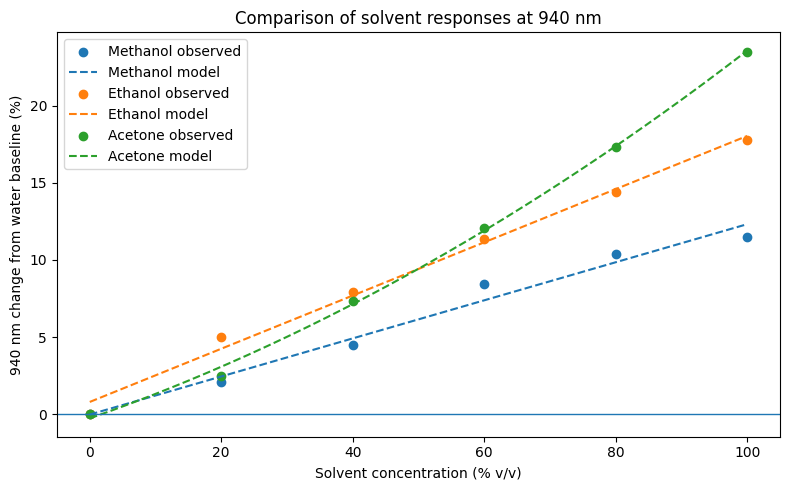

In [ ]:
plt.figure(figsize=(8, 5))

model_degrees = {
    "Methanol": 1,
    "Ethanol": 1,
    "Acetone": 2
}

for solvent in ["Methanol", "Ethanol", "Acetone"]:

    subset = combined_relative[
        combined_relative["Solvent"] == solvent
    ].sort_values("Concentration")

    x = subset["Concentration"].to_numpy()
    y = subset["940_full"].to_numpy()

    # Plot measured values only
    plt.scatter(
        x,
        y,
        label=f"{solvent} observed"
    )

    # Fit the selected model
    degree = model_degrees[solvent]

    coefficients = np.polyfit(
        x,
        y,
        degree
    )

    x_smooth = np.linspace(0, 100, 300)

    y_smooth = np.polyval(
        coefficients,
        x_smooth
    )

    plt.plot(
        x_smooth,
        y_smooth,
        linestyle="--",
        label=f"{solvent} model"
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Solvent concentration (% v/v)")
plt.ylabel("940 nm change from water baseline (%)")
plt.title("Comparison of solvent responses at 940 nm")

plt.legend()
plt.tight_layout()
plt.show()

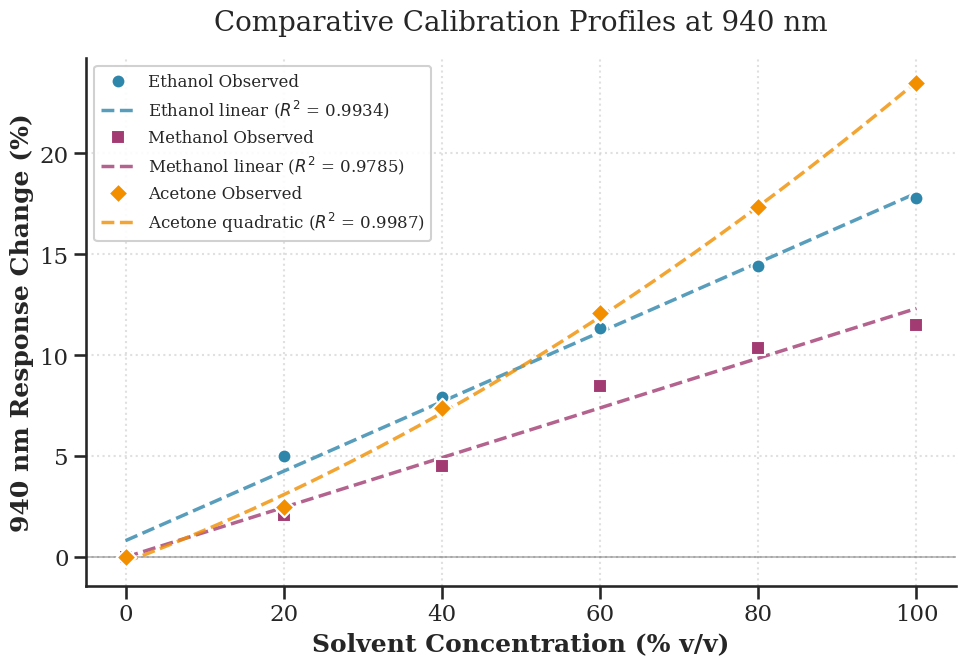

In [ ]:
import seaborn as sns

# Configure global plotting aesthetics for a professional look
sns.set_theme(style='ticks', context='talk')
plt.rcParams['font.family'] = 'serif'

plt.figure(figsize=(10, 7))

# Define professional color palette and marker styles
model_settings = {
    "Ethanol":  {"degree": 1, "marker": "o", "color": "#2E86AB"},
    "Methanol": {"degree": 1, "marker": "s", "color": "#A23B72"},
    "Acetone":  {"degree": 2, "marker": "D", "color": "#F18F01"}
}

for solvent, settings in model_settings.items():
    subset = combined_relative[combined_relative["Solvent"] == solvent].sort_values("Concentration")
    x = subset["Concentration"].to_numpy()
    y = subset["940_full"].to_numpy()

    degree = settings["degree"]
    marker = settings["marker"]
    color = settings["color"]

    # Regression model
    coefficients = np.polyfit(x, y, degree)
    r2 = r2_score(y, np.polyval(coefficients, x))

    x_smooth = np.linspace(0, 100, 300)
    y_smooth = np.polyval(coefficients, x_smooth)

    # Plot observed points with white edge for contrast
    plt.scatter(x, y, marker=marker, s=100, color=color,
                edgecolor='white', linewidth=1.5, label=f"{solvent} Observed", zorder=3)

    model_name = "quadratic" if degree == 2 else "linear"

    # Plot regression lines
    plt.plot(x_smooth, y_smooth, linewidth=2.5, color=color, linestyle='--', alpha=0.8,
             label=f"{solvent} {model_name} ($R^2$ = {r2:.4f})")

# Baseline indicator
plt.axhline(y=0, color='black', linewidth=1.2, alpha=0.3, linestyle='-', zorder=1)

# Refine labels and titles
plt.xlabel("Solvent Concentration (% v/v)", fontweight='bold')
plt.ylabel("940 nm Response Change (%)", fontweight='bold')
plt.title("Comparative Calibration Profiles at 940 nm", fontsize=20, pad=20)

plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
sns.despine()
plt.tight_layout()

# Save the enhanced version
plt.savefig("/content/drive/MyDrive/Project_78/Results/enhanced_940_calibrations.png",
            dpi=300, bbox_inches="tight")

plt.show()

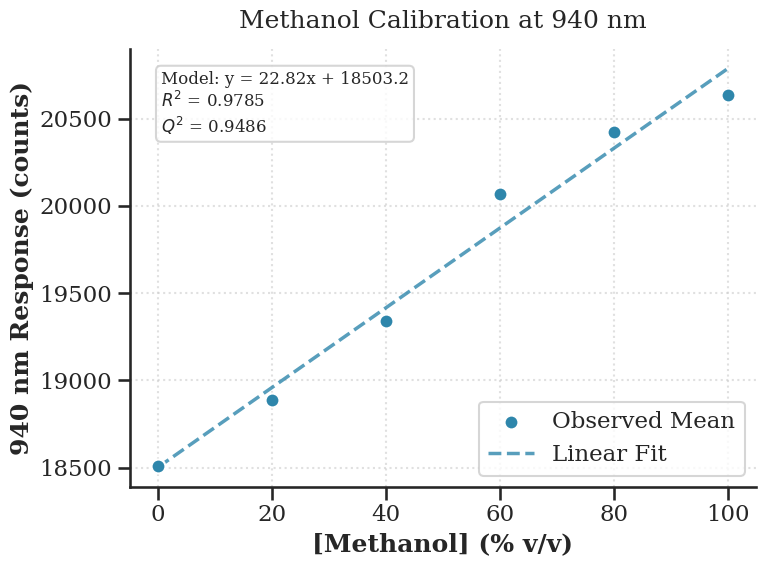

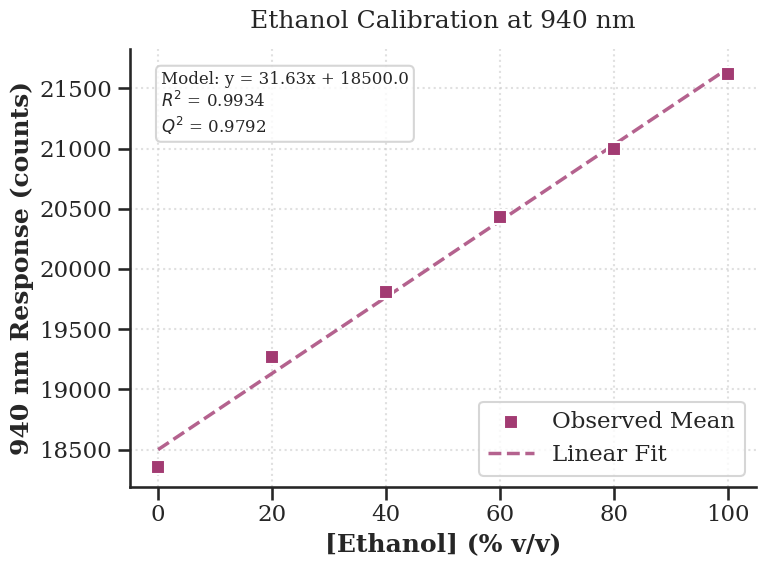

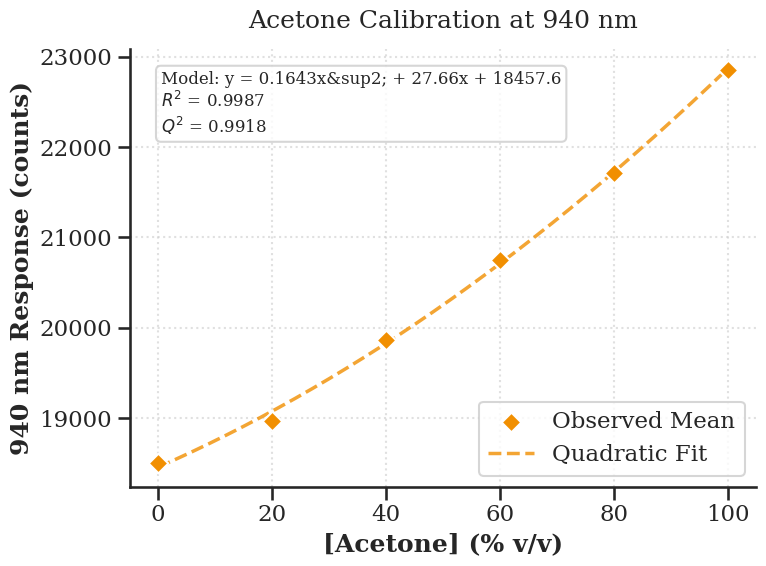

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Configure global aesthetics for publication quality
sns.set_theme(style='ticks', context='talk')
plt.rcParams['font.family'] = 'serif'

# Final cross-validated Q&sup2; values
q2_values = {
    "Methanol": 0.9486,
    "Ethanol": 0.9792,
    "Acetone": 0.9918
}

# Professional model configurations
model_configs = {
    "Methanol": {"degree": 1, "marker": "o", "color": "#2E86AB"},
    "Ethanol":  {"degree": 1, "marker": "s", "color": "#A23B72"},
    "Acetone":  {"degree": 2, "marker": "D", "color": "#F18F01"}
}

for solvent, config in model_configs.items():
    # Extract data
    subset = combined_calibration[combined_calibration["Solvent"] == solvent].sort_values("Concentration")
    x = subset["Concentration"].to_numpy()
    y = subset["940_full"].to_numpy()

    degree = config["degree"]
    marker = config["marker"]
    color = config["color"]

    # Fit model
    coeffs = np.polyfit(x, y, degree)
    predicted = np.polyval(coeffs, x)
    r2 = r2_score(y, predicted)
    q2 = q2_values[solvent]

    # Generate smooth fit line
    x_smooth = np.linspace(0, 100, 300)
    y_smooth = np.polyval(coeffs, x_smooth)

    # Create Figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot observed values with enhanced visibility
    ax.scatter(x, y, marker=marker, color=color, s=100,
               edgecolor='white', linewidth=1.5, label="Observed Mean", zorder=3)

    # Plot regression line
    model_label = "Quadratic Fit" if degree == 2 else "Linear Fit"
    ax.plot(x_smooth, y_smooth, color=color, linestyle='--',
            linewidth=2.5, alpha=0.8, label=model_label)

    # Generate equation string
    if degree == 1:
        slope, intercept = coeffs
        equation = f"y = {slope:.2f}x + {intercept:.1f}"
    else:
        a, b, c = coeffs
        equation = f"y = {a:.4f}x&sup2; + {b:.2f}x + {c:.1f}"

    stats_text = (f"Model: {equation}\n"
                  f"$R^2$ = {r2:.4f}\n"
                  f"$Q^2$ = {q2:.4f}")

    # Add statistics box
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

    # Refine Labels
    ax.set_xlabel(f"[{solvent}] (% v/v)", fontweight='bold')
    ax.set_ylabel("940 nm Response (counts)", fontweight='bold')
    ax.set_title(f"{solvent} Calibration at 940 nm", fontsize=18, pad=15)

    ax.legend(loc='lower right', frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)
    sns.despine()
    plt.tight_layout()

    # Save high-resolution image
    save_path = f"/content/drive/MyDrive/Project_78/Results/{solvent.lower()}_enhanced_calibration.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

### Performance Metrics Summary Table
Summary of the instrumental Limit of Detection (LoD) and modeling accuracy for the 940 nm channel.

In [ ]:
import numpy as np
import pandas as pd

# --- Calculations for ethanol_lod ---
ethanol_blank_mean = ethanol_means.loc[0, "940_full"]
ethanol_blank_rsd = 0.2234 # % (from ethanol_precision of water-baseline)
ethanol_blank_sd = (ethanol_blank_mean * ethanol_blank_rsd / 100)
x_ethanol = ethanol_means.index.to_numpy(dtype=float)
y_ethanol = ethanol_means["940_full"].to_numpy(dtype=float)
ethanol_coefficients = np.polyfit(x_ethanol, y_ethanol, 1)
ethanol_slope = ethanol_coefficients[0]
ethanol_lod = (3.3 * ethanol_blank_sd / abs(ethanol_slope))

# --- Calculations for methanol_lod ---
methanol_blank_rsd = 0.049   # % (recovered blank RSD value from notebook history)
methanol_blank_mean = methanol_means.loc[0, "940_full"]
methanol_blank_sd = (methanol_blank_mean * methanol_blank_rsd / 100)
x_meoh = methanol_means.index.to_numpy(dtype=float)
y_meoh = methanol_means["940_full"].to_numpy(dtype=float)
methanol_coefficients = np.polyfit(x_meoh, y_meoh, 1)
methanol_slope = methanol_coefficients[0]
methanol_lod = (3.3 * methanol_blank_sd / abs(methanol_slope))

# --- Calculations for acetone_lod ---
acetone_blank_rsd = 0.016    # % (recovered blank RSD value from notebook history)
acetone_blank_mean = acetone_means.loc[0, "940_full"]
acetone_blank_sd = (acetone_blank_mean * acetone_blank_rsd / 100)
x_acet = acetone_means.index.to_numpy(dtype=float)
y_acet = acetone_means["940_full"].to_numpy(dtype=float)
acetone_coefficients = np.polyfit(x_acet, y_acet, 2)
a, b, c = acetone_coefficients

def quadratic_detection_limit(
    multiplier,
    blank_sd
):
    response_threshold = (
        multiplier * blank_sd
    )
    roots = np.roots([
        a,
        b,
        -response_threshold
    ])
    positive_real_roots = [
        root.real
        for root in roots
        if np.isreal(root)
        and root.real >= 0
    ]
    if not positive_real_roots:
        return np.nan # Return NaN if no positive real roots are found
    return min(positive_real_roots)

acetone_lod = quadratic_detection_limit(
    3.3,
    acetone_blank_sd
)

summary_metrics = pd.DataFrame({
    'Solvent': ['Ethanol', 'Methanol', 'Acetone'],
    'Model Type': ['Linear', 'Linear', 'Quadratic'],
    'R²': [linear_r2, linear_meoh_r2, quadratic_acetone_r2],
    'Q²': [linear_q2, linear_meoh_q2, quadratic_acetone_q2],
    'LoD (% v/v)': [ethanol_lod, methanol_lod, acetone_lod]
})

display(summary_metrics.round(3))

,Solvent,Model Type,R²,Q²,LoD (% v/v)
0,Ethanol,Linear,0.993,0.979,4.278
1,Methanol,Linear,0.978,0.949,1.311
2,Acetone,Quadratic,0.999,0.992,0.353


In [ ]:
print("Ethanol shape:", ethanol_means.shape)
print("Methanol shape:", methanol_means.shape)
print("Acetone shape:", acetone_means.shape)

display(ethanol_means)
display(methanol_means)
display(acetone_means)

Ethanol shape: (6, 4)
Methanol shape: (6, 4)
Acetone shape: (6, 4)


Channel,465_full,625_full,850_full,940_full
Concentration,,,,
0,1347.233333,472.50,2147.766667,18354.166667
20,1356.250000,476.45,2208.800000,19269.750000
40,1332.450000,480.30,2250.700000,19811.650000
60,1378.750000,484.10,2278.850000,20433.900000
80,1382.900000,484.55,2268.350000,21000.100000
100,1368.200000,482.40,2253.050000,21619.750000


,465_full,625_full,850_full,940_full
Concentration,,,,
0,1340.7,463.4,2086.7,18507.2
20,1351.9,462.1,2102.3,18889.0
40,1335.0,462.5,2124.0,19341.3
60,1357.5,461.6,2214.4,20069.1
80,1337.1,466.4,2130.8,20423.1
100,1330.5,462.2,2120.7,20636.6


,465_full,625_full,850_full,940_full
Concentration,,,,
0,1340.7,463.4,2086.7,18507.2
20,1353.9,460.1,2104.1,18967.0
40,1353.7,461.7,2123.5,19868.2
60,1370.0,472.3,2157.8,20744.5
80,1374.6,471.0,2245.1,21714.2
100,1351.4,470.9,2293.4,22855.1


In [ ]:
channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]


def prepare_solvent_table(table, solvent_name):

    prepared = table.reset_index().copy()

    prepared["Solvent"] = solvent_name

    return prepared[
        ["Solvent", "Concentration"] + channels
    ]


ethanol_table = prepare_solvent_table(
    ethanol_means,
    "Ethanol"
)

methanol_table = prepare_solvent_table(
    methanol_means,
    "Methanol"
)

acetone_table = prepare_solvent_table(
    acetone_means,
    "Acetone"
)

combined_calibration = pd.concat(
    [
        ethanol_table,
        methanol_table,
        acetone_table
    ],
    ignore_index=True
)

display(combined_calibration)

print(
    "Combined table shape:",
    combined_calibration.shape
)

,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol,0,1347.233333,472.50,2147.766667,18354.166667
1,Ethanol,20,1356.250000,476.45,2208.800000,19269.750000
2,Ethanol,40,1332.450000,480.30,2250.700000,19811.650000
3,Ethanol,60,1378.750000,484.10,2278.850000,20433.900000
4,Ethanol,80,1382.900000,484.55,2268.350000,21000.100000
5,Ethanol,100,1368.200000,482.40,2253.050000,21619.750000
6,Methanol,0,1340.700000,463.40,2086.700000,18507.200000
7,Methanol,20,1351.900000,462.10,2102.300000,18889.000000
8,Methanol,40,1335.000000,462.50,2124.000000,19341.300000
9,Methanol,60,1357.500000,461.60,2214.400000,20069.100000


Combined table shape: (18, 6)


### Multivariate Comparison from Combined Calibration

Using the `combined_calibration` table, we can compare how different solvents affect each sensor channel simultaneously.

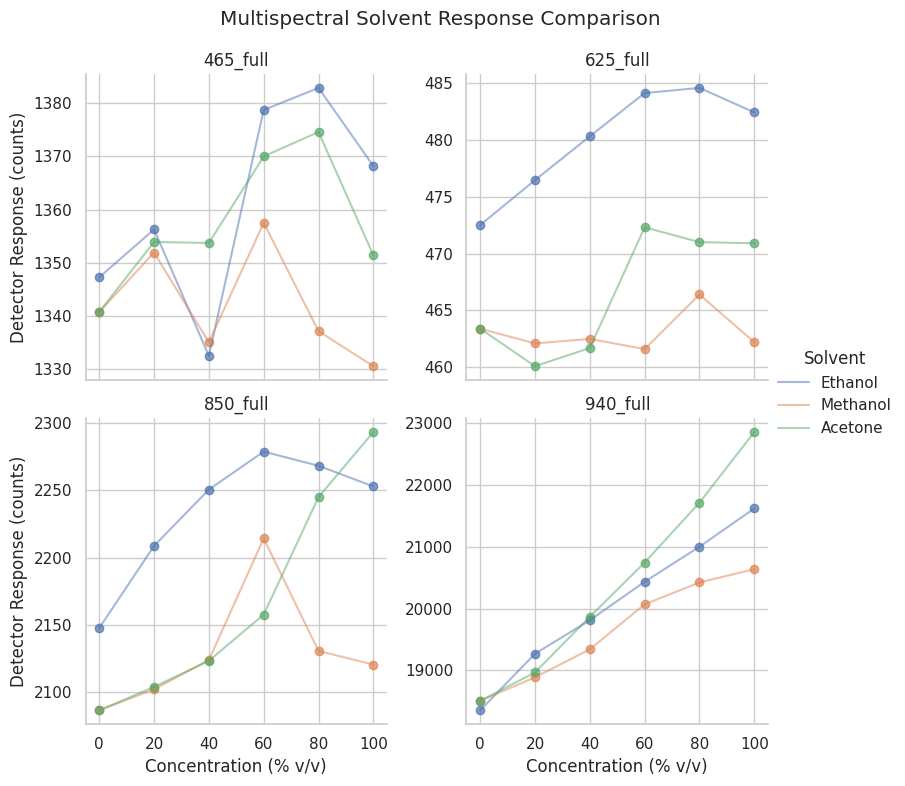

In [ ]:
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')

# Reshape data for easier plotting with seaborn
plot_df = combined_calibration.melt(
    id_vars=['Solvent', 'Concentration'],
    value_vars=['465_full', '625_full', '850_full', '940_full'],
    var_name='Channel',
    value_name='Response'
)

# Create a multi-panel plot
g = sns.FacetGrid(plot_df, col='Channel', hue='Solvent', col_wrap=2, height=4, sharey=False)
g.map(plt.scatter, 'Concentration', 'Response', alpha=0.7)
g.map(plt.plot, 'Concentration', 'Response', alpha=0.5)

g.add_legend()
g.set_axis_labels('Concentration (% v/v)', 'Detector Response (counts)')
g.set_titles('{col_name}')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Multispectral Solvent Response Comparison')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Recovered blank RSD values
methanol_blank_rsd = 0.049   # %
acetone_blank_rsd = 0.016    # %

# Exact water baseline means from your calibration tables
methanol_blank_mean = methanol_means.loc[0, "940_full"]
acetone_blank_mean = acetone_means.loc[0, "940_full"]

# Convert RSD to standard deviation
methanol_blank_sd = (
    methanol_blank_mean
    * methanol_blank_rsd
    / 100
)

acetone_blank_sd = (
    acetone_blank_mean
    * acetone_blank_rsd
    / 100
)

print("Methanol blank mean:", methanol_blank_mean)
print("Methanol blank SD:", methanol_blank_sd)

print("Acetone blank mean:", acetone_blank_mean)
print("Acetone blank SD:", acetone_blank_sd)

Methanol blank mean: 18507.2
Methanol blank SD: 9.068528
Acetone blank mean: 18507.2
Acetone blank SD: 2.9611520000000002


In [ ]:
x_meoh = methanol_means.index.to_numpy(dtype=float)
y_meoh = methanol_means["940_full"].to_numpy(dtype=float)

methanol_coefficients = np.polyfit(
    x_meoh,
    y_meoh,
    1
)

methanol_slope, methanol_intercept = (
    methanol_coefficients
)

methanol_lod = (
    3.3 * methanol_blank_sd
    / abs(methanol_slope)
)

methanol_loq = (
    10 * methanol_blank_sd
    / abs(methanol_slope)
)

print("Methanol slope:", methanol_slope)
print("Methanol instrumental LoD:", methanol_lod, "% v/v")
print("Methanol instrumental LoQ:", methanol_loq, "% v/v")

Methanol slope: 22.82442857142853
Methanol instrumental LoD: 1.3111453067202457 % v/v
Methanol instrumental LoQ: 3.973167596121957 % v/v


In [ ]:
x_acet = acetone_means.index.to_numpy(dtype=float)
y_acet = acetone_means["940_full"].to_numpy(dtype=float)

acetone_coefficients = np.polyfit(
    x_acet,
    y_acet,
    2
)

a, b, c = acetone_coefficients


def quadratic_detection_limit(
    multiplier,
    blank_sd
):
    response_threshold = (
        multiplier * blank_sd
    )

    # Solve:
    # a*x² + b*x = response threshold
    roots = np.roots([
        a,
        b,
        -response_threshold
    ])

    positive_real_roots = [
        root.real
        for root in roots
        if np.isreal(root)
        and root.real >= 0
    ]

    return min(positive_real_roots)


acetone_lod = quadratic_detection_limit(
    3.3,
    acetone_blank_sd
)

acetone_loq = quadratic_detection_limit(
    10,
    acetone_blank_sd
)

print("Acetone coefficients:", acetone_coefficients)
print("Acetone instrumental LoD:", acetone_lod, "% v/v")
print("Acetone instrumental LoQ:", acetone_loq, "% v/v")

Acetone coefficients: [1.64263393e-01 2.76556607e+01 1.84576179e+04]
Acetone instrumental LoD: 0.3525997586274478 % v/v
Acetone instrumental LoQ: 1.063997681503073 % v/v


In [ ]:
# Ethanol blank information
ethanol_blank_mean = ethanol_means.loc[
    0,
    "940_full"
]

# RSD calculated from the saved ethanol water-baseline replicates
ethanol_blank_rsd = 0.2234  # %

# Convert blank RSD to standard deviation
ethanol_blank_sd = (
    ethanol_blank_mean
    * ethanol_blank_rsd
    / 100
)

# Fit the selected linear calibration
x_ethanol = ethanol_means.index.to_numpy(
    dtype=float
)

y_ethanol = ethanol_means[
    "940_full"
].to_numpy(dtype=float)

ethanol_coefficients = np.polyfit(
    x_ethanol,
    y_ethanol,
    1
)

ethanol_slope, ethanol_intercept = (
    ethanol_coefficients
)

# Calculate preliminary LoD and LoQ
ethanol_lod = (
    3.3
    * ethanol_blank_sd
    / abs(ethanol_slope)
)

ethanol_loq = (
    10
    * ethanol_blank_sd
    / abs(ethanol_slope)
)

print(
    "Ethanol blank mean:",
    ethanol_blank_mean
)

print(
    "Ethanol blank RSD:",
    ethanol_blank_rsd,
    "%"
)

print(
    "Ethanol blank SD:",
    ethanol_blank_sd,
    "counts"
)

print(
    "Ethanol calibration slope:",
    ethanol_slope,
    "counts per % v/v"
)

print(
    "Estimated ethanol LoD:",
    ethanol_lod,
    "% v/v"
)

print(
    "Estimated ethanol LoQ:",
    ethanol_loq,
    "% v/v"
)

Ethanol blank mean: 18354.166666666668
Ethanol blank RSD: 0.2234 %
Ethanol blank SD: 41.00320833333333 counts
Ethanol calibration slope: 31.63030952380956 counts per % v/v
Estimated ethanol LoD: 4.2778774389844525 % v/v
Estimated ethanol LoQ: 12.963264966619555 % v/v


# Principal Component Analysis of Pure-Solvent Standards

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

print("Combined relative table shape:", combined_relative.shape)

display(
    combined_relative[
        ["Solvent", "Concentration"] + channels
    ].round(3)
)

print("\nMissing values:")
print(combined_relative[channels].isnull().sum())

Combined relative table shape: (18, 6)


,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol,0,0.000,0.000,0.000,0.000
1,Ethanol,20,0.669,0.836,2.842,4.988
2,Ethanol,40,-1.097,1.651,4.793,7.941
3,Ethanol,60,2.339,2.455,6.103,11.331
4,Ethanol,80,2.647,2.550,5.614,14.416
5,Ethanol,100,1.556,2.095,4.902,17.792
6,Methanol,0,0.000,0.000,0.000,0.000
7,Methanol,20,0.835,-0.281,0.748,2.063
8,Methanol,40,-0.425,-0.194,1.788,4.507
9,Methanol,60,1.253,-0.388,6.120,8.439



Missing values:
465_full    0
625_full    0
850_full    0
940_full    0
dtype: int64


In [ ]:
baseline_check = combined_relative[
    combined_relative["Concentration"] == 0
][
    ["Solvent", "Concentration"] + channels
]

display(baseline_check.round(8))

,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol,0,0.0,0.0,0.0,0.0
6,Methanol,0,0.0,0.0,0.0,0.0
12,Acetone,0,0.0,0.0,0.0,0.0


In [ ]:
pca_table = combined_relative[
    combined_relative["Concentration"] > 0
].copy()

pca_table["Sample_ID"] = (
    pca_table["Solvent"]
    + "_"
    + pca_table["Concentration"]
        .astype(int)
        .astype(str)
)

pca_table = pca_table[
    [
        "Sample_ID",
        "Solvent",
        "Concentration"
    ] + channels
].reset_index(drop=True)

display(pca_table.round(3))

print("PCA table shape:", pca_table.shape)

,Sample_ID,Solvent,Concentration,465_full,625_full,850_full,940_full
0,Ethanol_20,Ethanol,20,0.669,0.836,2.842,4.988
1,Ethanol_40,Ethanol,40,-1.097,1.651,4.793,7.941
2,Ethanol_60,Ethanol,60,2.339,2.455,6.103,11.331
3,Ethanol_80,Ethanol,80,2.647,2.550,5.614,14.416
4,Ethanol_100,Ethanol,100,1.556,2.095,4.902,17.792
5,Methanol_20,Methanol,20,0.835,-0.281,0.748,2.063
6,Methanol_40,Methanol,40,-0.425,-0.194,1.788,4.507
7,Methanol_60,Methanol,60,1.253,-0.388,6.120,8.439
8,Methanol_80,Methanol,80,-0.269,0.647,2.113,10.352
9,Methanol_100,Methanol,100,-0.761,-0.259,1.629,11.506


PCA table shape: (15, 7)


In [ ]:
X = pca_table[channels].copy()

print("PCA input shape:", X.shape)
display(X.round(3))

PCA input shape: (15, 4)


,465_full,625_full,850_full,940_full
0,0.669,0.836,2.842,4.988
1,-1.097,1.651,4.793,7.941
2,2.339,2.455,6.103,11.331
3,2.647,2.550,5.614,14.416
4,1.556,2.095,4.902,17.792
5,0.835,-0.281,0.748,2.063
6,-0.425,-0.194,1.788,4.507
7,1.253,-0.388,6.120,8.439
8,-0.269,0.647,2.113,10.352
9,-0.761,-0.259,1.629,11.506


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_table = pd.DataFrame(
    X_scaled,
    columns=channels,
    index=pca_table["Sample_ID"]
)

display(scaled_table.round(3))

,465_full,625_full,850_full,940_full
Sample_ID,,,,
Ethanol_20,-0.242,-0.040,-0.448,-0.929
Ethanol_40,-1.775,0.682,0.300,-0.422
Ethanol_60,1.208,1.395,0.802,0.159
Ethanol_80,1.476,1.479,0.615,0.687
Ethanol_100,0.528,1.076,0.342,1.266
Methanol_20,-0.097,-1.029,-1.250,-1.430
Methanol_40,-1.192,-0.953,-0.852,-1.011
Methanol_60,0.265,-1.125,0.809,-0.337
Methanol_80,-1.056,-0.207,-0.727,-0.009


In [ ]:
scaling_check = pd.DataFrame({
    "Channel": channels,
    "Scaled_mean": X_scaled.mean(axis=0),
    "Scaled_SD": X_scaled.std(axis=0)
})

display(scaling_check.round(6))

,Channel,Scaled_mean,Scaled_SD
0,465_full,0.0,1.0
1,625_full,0.0,1.0
2,850_full,0.0,1.0
3,940_full,-0.0,1.0


In [ ]:
pca_model = PCA(n_components=2)

pca_scores = pca_model.fit_transform(
    X_scaled
)

explained_variance = (
    pca_model.explained_variance_ratio_
    * 100
)

print(
    f"PC1 explained variance: "
    f"{explained_variance[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance[1]:.2f}%"
)

print(
    f"PC1 + PC2 cumulative variance: "
    f"{explained_variance.sum():.2f}%"
)

PC1 explained variance: 68.58%
PC2 explained variance: 18.05%
PC1 + PC2 cumulative variance: 86.63%


In [ ]:
scores_table = pca_table[
    [
        "Sample_ID",
        "Solvent",
        "Concentration"
    ]
].copy()

scores_table["PC1"] = pca_scores[:, 0]
scores_table["PC2"] = pca_scores[:, 1]

display(scores_table.round(3))

,Sample_ID,Solvent,Concentration,PC1,PC2
0,Ethanol_20,Ethanol,20,-0.852,0.291
1,Ethanol_40,Ethanol,40,-0.409,-1.419
2,Ethanol_60,Ethanol,60,1.719,0.827
3,Ethanol_80,Ethanol,80,2.049,0.908
4,Ethanol_100,Ethanol,100,1.626,-0.085
5,Methanol_20,Methanol,20,-2.009,0.796
6,Methanol_40,Methanol,40,-1.963,-0.432
7,Methanol_60,Methanol,60,-0.224,0.059
8,Methanol_80,Methanol,80,-0.921,-0.707
9,Methanol_100,Methanol,100,-1.502,-1.148


In [ ]:
water_relative = pd.DataFrame(
    [[0, 0, 0, 0]],
    columns=channels
)

water_scaled = scaler.transform(
    water_relative
)

water_score = pca_model.transform(
    water_scaled
)

print(
    "Projected water coordinates:",
    water_score
)

Projected water coordinates: [[-2.50873991  0.40804722]]


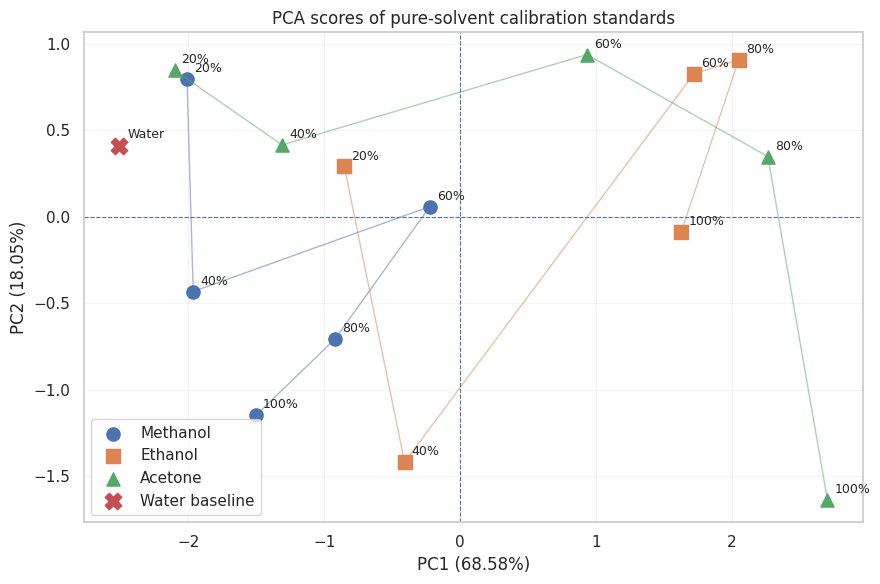

In [ ]:
plt.figure(figsize=(9, 6))

markers = {
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in [
    "Methanol",
    "Ethanol",
    "Acetone"
]:

    subset = scores_table[
        scores_table["Solvent"] == solvent
    ].sort_values("Concentration")

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        marker=markers[solvent],
        s=90,
        label=solvent
    )

    # Connect concentrations in order
    plt.plot(
        subset["PC1"],
        subset["PC2"],
        linewidth=1,
        alpha=0.5
    )

    # Label each concentration
    for _, row in subset.iterrows():

        plt.annotate(
            f"{int(row['Concentration'])}%",
            (
                row["PC1"],
                row["PC2"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

# Add the projected water point
plt.scatter(
    water_score[0, 0],
    water_score[0, 1],
    marker="X",
    s=140,
    label="Water baseline"
)

plt.annotate(
    "Water",
    (
        water_score[0, 0],
        water_score[0, 1]
    ),
    xytext=(6, 6),
    textcoords="offset points",
    fontsize=9
)

plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.2f}%)"
)

plt.title(
    "PCA scores of pure-solvent calibration standards"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
loadings_table = pd.DataFrame(
    pca_model.components_.T,
    index=channels,
    columns=[
        "PC1_loading",
        "PC2_loading"
    ]
)

display(loadings_table.round(4))

,PC1_loading,PC2_loading
465_full,0.3945,0.8661
625_full,0.5199,0.0581
850_full,0.5389,-0.2964
940_full,0.5326,-0.3983


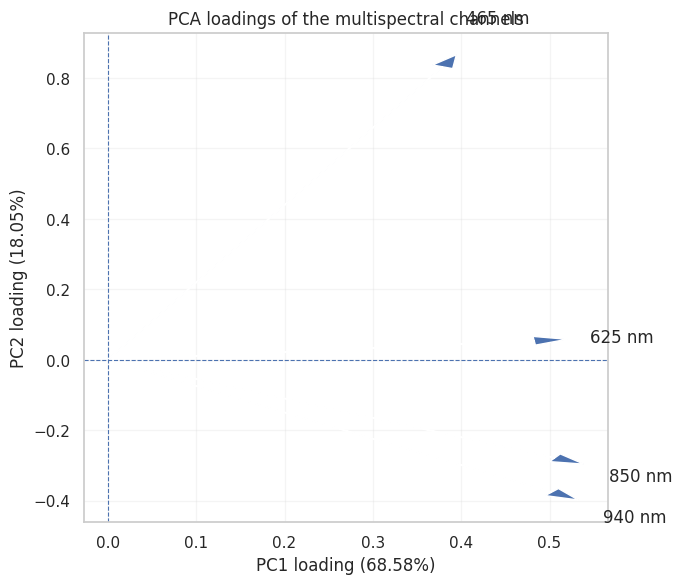

In [ ]:
plt.figure(figsize=(7, 6))

for channel in channels:

    pc1_loading = loadings_table.loc[
        channel,
        "PC1_loading"
    ]

    pc2_loading = loadings_table.loc[
        channel,
        "PC2_loading"
    ]

    plt.arrow(
        0,
        0,
        pc1_loading,
        pc2_loading,
        head_width=0.025,
        length_includes_head=True
    )

    plt.text(
        pc1_loading * 1.12,
        pc2_loading * 1.12,
        channel.replace("_full", " nm"),
        ha="center",
        va="center"
    )

plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel(
    f"PC1 loading ({explained_variance[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 loading ({explained_variance[1]:.2f}%)"
)

plt.title(
    "PCA loadings of the multispectral channels"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_loadings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
pca_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_input.csv",
    index=False
)

scores_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_scores.csv",
    index=False
)

loadings_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_loadings.csv"
)

explained_variance_table = pd.DataFrame({
    "Principal_component": ["PC1", "PC2"],
    "Explained_variance_percent": explained_variance
})

explained_variance_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_explained_variance.csv",
    index=False
)

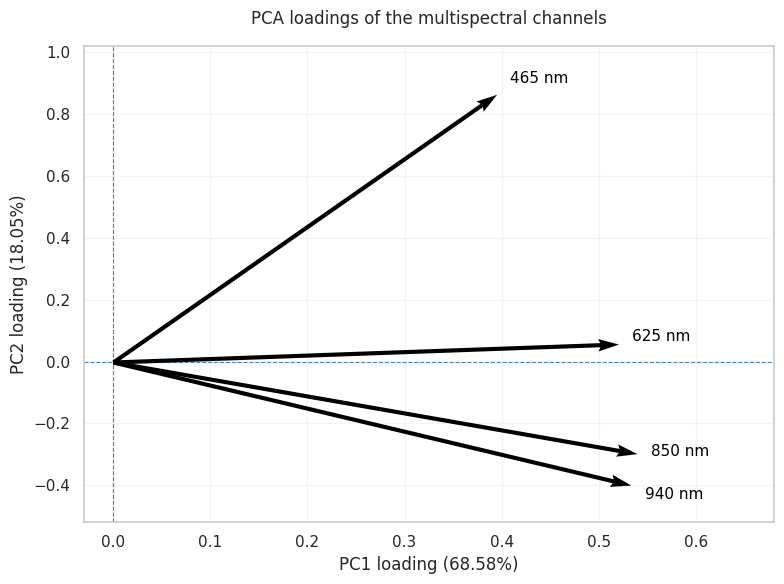

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Draw reference axes first
ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
    color="steelblue",
    zorder=1
)

ax.axvline(
    0,
    linewidth=0.8,
    linestyle="--",
    color="steelblue",
    zorder=1
)

label_offsets = {
    "465_full": (10, 8),
    "625_full": (10, 2),
    "850_full": (10, -2),
    "940_full": (10, -10)
}

for channel in channels:

    pc1_loading = loadings_table.loc[
        channel,
        "PC1_loading"
    ]

    pc2_loading = loadings_table.loc[
        channel,
        "PC2_loading"
    ]

    # Clearly visible vector from the origin
    ax.quiver(
        0,
        0,
        pc1_loading,
        pc2_loading,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.006,
        color="black",
        zorder=5
    )

    wavelength_label = channel.replace(
        "_full",
        " nm"
    )

    ax.annotate(
        wavelength_label,
        xy=(pc1_loading, pc2_loading),
        xytext=label_offsets[channel],
        textcoords="offset points",
        fontsize=11,
        color="black",
        zorder=6
    )

ax.set_xlim(-0.03, 0.68)
ax.set_ylim(-0.52, 1.02)

ax.set_xlabel(
    f"PC1 loading ({explained_variance[0]:.2f}%)"
)

ax.set_ylabel(
    f"PC2 loading ({explained_variance[1]:.2f}%)"
)

ax.set_title(
    "PCA loadings of the multispectral channels",
    pad=16
)

ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_loadings_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Save scores table
scores_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_scores.csv",
    index=False
)

# Save loadings table
loadings_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_loadings.csv"
)

# Save explained variance
explained_variance_table = pd.DataFrame({
    "Principal_component": ["PC1", "PC2"],
    "Explained_variance_percent": explained_variance
})

explained_variance_table.to_csv(
    "/content/drive/MyDrive/Project_78/Results/"
    "pure_solvent_pca_explained_variance.csv",
    index=False
)

print("PCA tables saved successfully.")

PCA tables saved successfully.


# Analysis of the Solvent-Spiking Experiment

1. Import spike files
2. Check sample names and concentrations
3. Calculate response relative to the unspiked waste baseline
4. Plot each wavelength against added solvent concentration
5. Calculate slopes, R² and precision
6. Run PCA
7. Build cross-validated PLS for total added concentration
8. Calculate VIP scores
9. Interpret monitoring performance

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SPIKE_DIR = (
    "/content/drive/MyDrive/project_78/Spike"
)

channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

spike_files = {
    # Methanol series
    ("Methanol", 0): "sw01-C0.csv",
    ("Methanol", 5): "sw02-M5.csv",
    ("Methanol", 10): "sw03-M10.csv",
    ("Methanol", 15): "sw04-M15.csv",
    ("Methanol", 20): "sw05-M20.csv",

    # Ethanol series
    ("Ethanol", 0): "sw01-E0.csv",
    ("Ethanol", 5): "sw01-E5.csv",
    ("Ethanol", 10): "sw01-E10.csv",
    ("Ethanol", 15): "sw01-E15.csv",
    ("Ethanol", 20): "sw01-E20.csv",

    # Acetone series
    ("Acetone", 0): "sw01-A0.csv",
    ("Acetone", 5): "sw02-A5.csv",
    ("Acetone", 10): "sw02-A10.csv",
    ("Acetone", 15): "sw02-A15.csv",
    ("Acetone", 20): "sw02-A20.csv"
}

In [ ]:
file_audit = []

for (solvent, spike_level), filename in spike_files.items():

    filepath = os.path.join(
        SPIKE_DIR,
        filename
    )

    file_audit.append({
        "Solvent": solvent,
        "Spike_percent_vv": spike_level,
        "Filename": filename,
        "File_exists": os.path.exists(filepath)
    })

file_audit = pd.DataFrame(file_audit)

display(file_audit)

print(
    "Files found:",
    file_audit["File_exists"].sum(),
    "out of",
    len(file_audit)
)

,Solvent,Spike_percent_vv,Filename,File_exists
0,Methanol,0,sw01-C0.csv,True
1,Methanol,5,sw02-M5.csv,True
2,Methanol,10,sw03-M10.csv,True
3,Methanol,15,sw04-M15.csv,True
4,Methanol,20,sw05-M20.csv,True
5,Ethanol,0,sw01-E0.csv,True
6,Ethanol,5,sw01-E5.csv,True
7,Ethanol,10,sw01-E10.csv,True
8,Ethanol,15,sw01-E15.csv,True
9,Ethanol,20,sw01-E20.csv,True


Files found: 15 out of 15


In [ ]:
expected_columns = [
    "sample",
    "replicate",
    "465_full",
    "465_IR",
    "625_full",
    "625_IR",
    "850_full",
    "850_IR",
    "940_full",
    "940_IR"
]

spike_audit_rows = []

for (solvent, spike_level), filename in spike_files.items():

    filepath = os.path.join(
        SPIKE_DIR,
        filename
    )

    df = pd.read_csv(filepath)

    missing_columns = [
        column
        for column in expected_columns
        if column not in df.columns
    ]

    spike_audit_rows.append({
        "Solvent": solvent,
        "Spike_percent_vv": spike_level,
        "Filename": filename,
        "Saved_rows": len(df),
        "Missing_columns": (
            ", ".join(missing_columns)
            if missing_columns
            else "None"
        ),
        "Missing_values": int(
            df.isna().sum().sum()
        )
    })

spike_audit = pd.DataFrame(
    spike_audit_rows
).sort_values(
    ["Solvent", "Spike_percent_vv"]
)

display(spike_audit)

,Solvent,Spike_percent_vv,Filename,Saved_rows,Missing_columns,Missing_values
10,Acetone,0,sw01-A0.csv,1,None,0
11,Acetone,5,sw02-A5.csv,1,None,0
12,Acetone,10,sw02-A10.csv,1,None,0
13,Acetone,15,sw02-A15.csv,1,None,0
14,Acetone,20,sw02-A20.csv,1,None,0
5,Ethanol,0,sw01-E0.csv,1,None,0
6,Ethanol,5,sw01-E5.csv,1,None,0
7,Ethanol,10,sw01-E10.csv,1,None,0
8,Ethanol,15,sw01-E15.csv,1,None,0
9,Ethanol,20,sw01-E20.csv,1,None,0


In [ ]:
spike_rows = []

for (solvent, spike_level), filename in spike_files.items():

    filepath = os.path.join(
        SPIKE_DIR,
        filename
    )

    df = pd.read_csv(filepath)

    row = {
        "Solvent": solvent,
        "Spike_percent_vv": spike_level,
        "Source_file": filename,
        "Saved_rows": len(df)
    }

    for channel in channels:
        row[channel] = df[channel].mean()

    spike_rows.append(row)

spike_raw = (
    pd.DataFrame(spike_rows)
    .sort_values(
        ["Solvent", "Spike_percent_vv"]
    )
    .reset_index(drop=True)
)

display(spike_raw.round(3))

print(
    "Spike table shape:",
    spike_raw.shape
)

,Solvent,Spike_percent_vv,Source_file,Saved_rows,465_full,625_full,850_full,940_full
0,Acetone,0,sw01-A0.csv,1,941.8,342.10,2061.30,17132.30
1,Acetone,5,sw02-A5.csv,1,933.8,328.50,2078.00,17201.30
2,Acetone,10,sw02-A10.csv,1,938.1,295.00,2102.80,17520.40
3,Acetone,15,sw02-A15.csv,1,953.4,275.40,2097.40,17653.90
4,Acetone,20,sw02-A20.csv,1,941.4,237.80,2149.10,17990.10
5,Ethanol,0,sw01-E0.csv,1,945.4,343.30,2128.60,17134.80
6,Ethanol,5,sw01-E5.csv,1,956.6,330.90,2107.70,17476.70
7,Ethanol,10,sw01-E10.csv,1,937.4,312.90,2114.50,17577.00
8,Ethanol,15,sw01-E15.csv,1,930.6,274.10,2103.90,17705.10
9,Ethanol,20,sw01-E20.csv,1,930.1,263.00,2107.00,17913.70


Spike table shape: (15, 8)


In [ ]:
spike_structure = (
    spike_raw
    .groupby("Solvent")["Spike_percent_vv"]
    .apply(list)
    .reset_index(name="Spike_levels")
)

display(spike_structure)

,Solvent,Spike_levels
0,Acetone,"[0, 5, 10, 15, 20]"
1,Ethanol,"[0, 5, 10, 15, 20]"
2,Methanol,"[0, 5, 10, 15, 20]"


In [ ]:
spike_relative = spike_raw.copy()

for solvent in spike_raw["Solvent"].unique():

    solvent_mask = (
        spike_raw["Solvent"] == solvent
    )

    baseline_row = spike_raw[
        solvent_mask
        & (spike_raw["Spike_percent_vv"] == 0)
    ]

    if len(baseline_row) != 1:
        raise ValueError(
            f"{solvent} must have exactly one 0% baseline."
        )

    for channel in channels:

        baseline_value = (
            baseline_row[channel]
            .iloc[0]
        )

        # Change in detector counts
        spike_relative.loc[
            solvent_mask,
            f"{channel}_delta"
        ] = (
            spike_raw.loc[
                solvent_mask,
                channel
            ]
            - baseline_value
        )

        # Percentage change from baseline
        spike_relative.loc[
            solvent_mask,
            f"{channel}_pct"
        ] = (
            (
                spike_raw.loc[
                    solvent_mask,
                    channel
                ]
                - baseline_value
            )
            / baseline_value
        ) * 100

In [ ]:
percentage_columns = [
    "465_full_pct",
    "625_full_pct",
    "850_full_pct",
    "940_full_pct"
]

display(
    spike_relative[
        [
            "Solvent",
            "Spike_percent_vv"
        ] + percentage_columns
    ].round(3)
)

,Solvent,Spike_percent_vv,465_full_pct,625_full_pct,850_full_pct,940_full_pct
0,Acetone,0,0.000,0.000,0.000,0.000
1,Acetone,5,-0.849,-3.975,0.810,0.403
2,Acetone,10,-0.393,-13.768,2.013,2.265
3,Acetone,15,1.232,-19.497,1.751,3.045
4,Acetone,20,-0.042,-30.488,4.259,5.007
5,Ethanol,0,0.000,0.000,0.000,0.000
6,Ethanol,5,1.185,-3.612,-0.982,1.995
7,Ethanol,10,-0.846,-8.855,-0.662,2.581
8,Ethanol,15,-1.565,-20.157,-1.160,3.328
9,Ethanol,20,-1.618,-23.391,-1.015,4.546


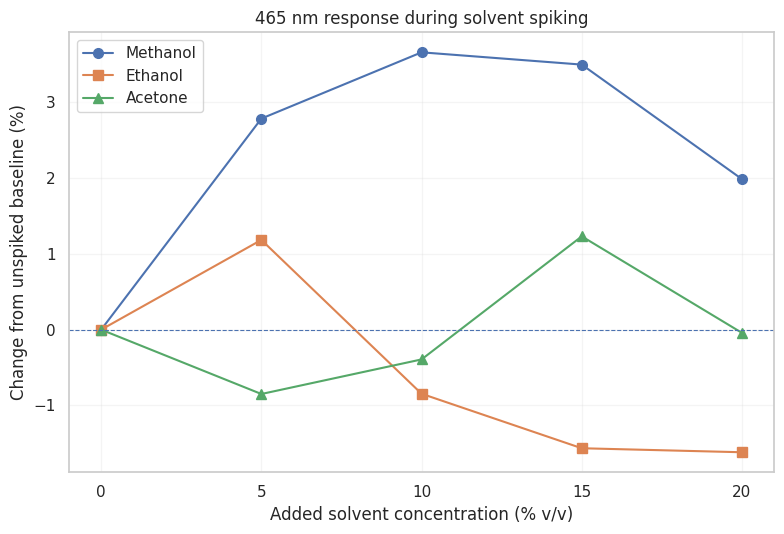

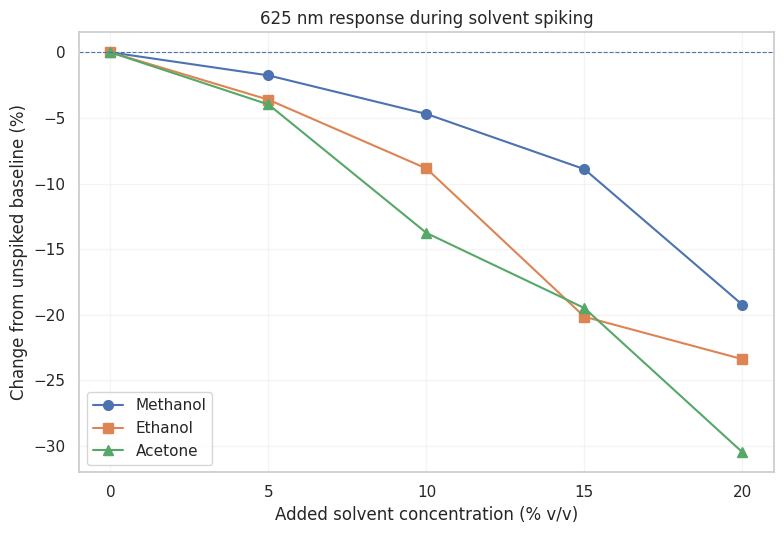

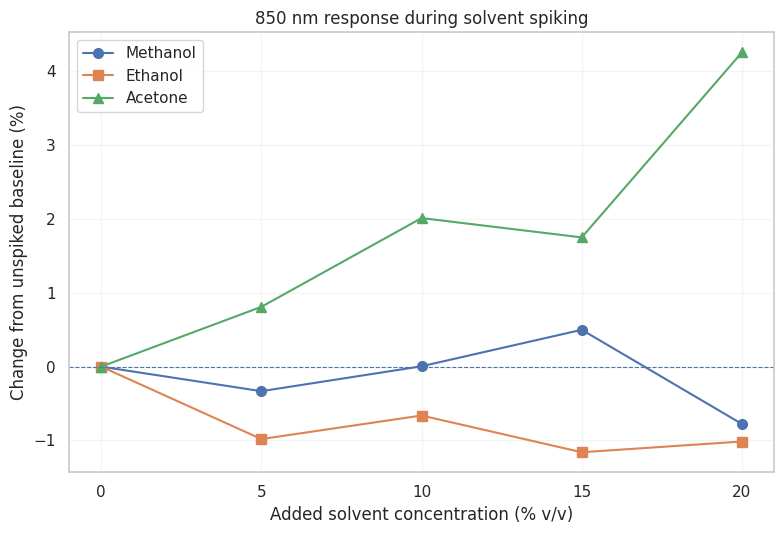

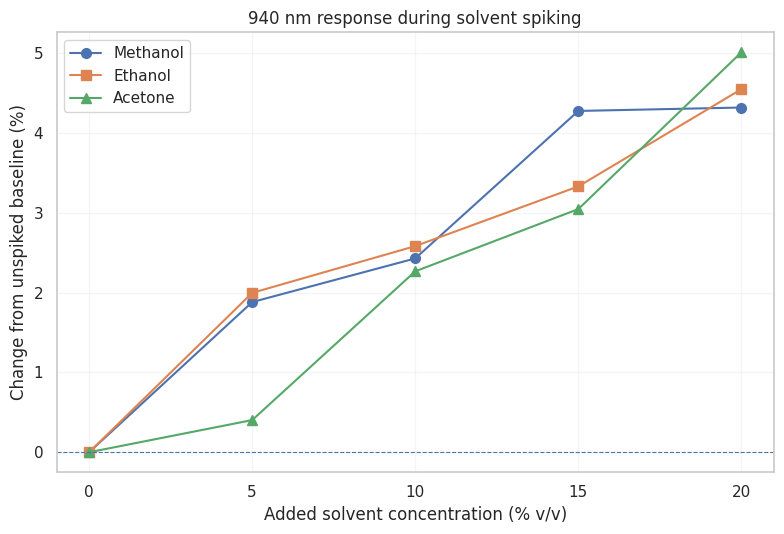

In [ ]:
plot_channels = {
    "465_full_pct": "465 nm",
    "625_full_pct": "625 nm",
    "850_full_pct": "850 nm",
    "940_full_pct": "940 nm"
}

markers = {
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for response_column, wavelength_label in plot_channels.items():

    plt.figure(figsize=(8, 5.5))

    for solvent in [
        "Methanol",
        "Ethanol",
        "Acetone"
    ]:

        subset = spike_relative[
            spike_relative["Solvent"] == solvent
        ].sort_values("Spike_percent_vv")

        plt.plot(
            subset["Spike_percent_vv"],
            subset[response_column],
            marker=markers[solvent],
            linewidth=1.5,
            markersize=7,
            label=solvent
        )

    plt.axhline(
        0,
        linewidth=0.8,
        linestyle="--"
    )

    plt.xlabel("Added solvent concentration (% v/v)")
    plt.ylabel("Change from unspiked baseline (%)")

    plt.title(
        f"{wavelength_label} response during solvent spiking"
    )

    plt.xticks([0, 5, 10, 15, 20])
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()

    plt.savefig(
        "/content/drive/MyDrive/Project_78/Results/"
        f"spike_{wavelength_label.replace(' ', '_')}_response.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

regression_rows = []

for solvent in ["Methanol", "Ethanol", "Acetone"]:

    subset = spike_relative[
        spike_relative["Solvent"] == solvent
    ].sort_values("Spike_percent_vv")

    x = subset[
        "Spike_percent_vv"
    ].to_numpy(dtype=float)

    y = subset[
        "940_full_pct"
    ].to_numpy(dtype=float)

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    predicted = (
        slope * x
        + intercept
    )

    r_squared = r2_score(
        y,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            predicted
        )
    )

    regression_rows.append({
        "Solvent": solvent,
        "Slope_pct_response_per_pct_vv": slope,
        "Intercept": intercept,
        "R_squared": r_squared,
        "RMSE_response_percent": rmse
    })

spike_940_regression = pd.DataFrame(
    regression_rows
)

display(
    spike_940_regression.round(4)
)

,Solvent,Slope_pct_response_per_pct_vv,Intercept,R_squared,RMSE_response_percent
0,Methanol,0.2205,0.3742,0.9314,0.4230
1,Ethanol,0.2085,0.4051,0.9548,0.3209
2,Acetone,0.2531,-0.3872,0.9619,0.3561


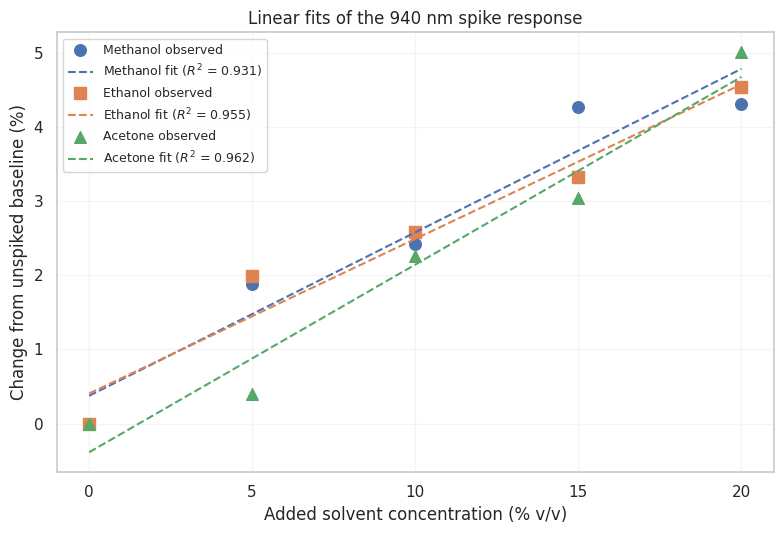

In [ ]:
plt.figure(figsize=(8, 5.5))

markers = {
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in ["Methanol", "Ethanol", "Acetone"]:

    subset = spike_relative[
        spike_relative["Solvent"] == solvent
    ].sort_values("Spike_percent_vv")

    x = subset[
        "Spike_percent_vv"
    ].to_numpy(dtype=float)

    y = subset[
        "940_full_pct"
    ].to_numpy(dtype=float)

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    x_fit = np.linspace(
        0,
        20,
        100
    )

    y_fit = (
        slope * x_fit
        + intercept
    )

    plt.scatter(
        x,
        y,
        marker=markers[solvent],
        s=70,
        label=f"{solvent} observed"
    )

    plt.plot(
        x_fit,
        y_fit,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"{solvent} fit "
            f"($R^2$ = "
            f"{r2_score(y, slope*x + intercept):.3f})"
        )
    )

plt.xlabel(
    "Added solvent concentration (% v/v)"
)

plt.ylabel(
    "Change from unspiked baseline (%)"
)

plt.title(
    "Linear fits of the 940 nm spike response"
)

plt.xticks([0, 5, 10, 15, 20])
plt.grid(alpha=0.2)
plt.legend(fontsize=9)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_940_linear_fits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison of wavelength sensitivity during spiking

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

response_columns = {
    "465 nm": "465_full_pct",
    "625 nm": "625_full_pct",
    "850 nm": "850_full_pct",
    "940 nm": "940_full_pct"
}

all_regression_rows = []

for solvent in ["Methanol", "Ethanol", "Acetone"]:

    subset = (
        spike_relative[
            spike_relative["Solvent"] == solvent
        ]
        .sort_values("Spike_percent_vv")
    )

    x = subset[
        "Spike_percent_vv"
    ].to_numpy(dtype=float)

    for wavelength, response_column in response_columns.items():

        y = subset[
            response_column
        ].to_numpy(dtype=float)

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        predicted = (
            slope * x
            + intercept
        )

        r_squared = r2_score(
            y,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                y,
                predicted
            )
        )

        all_regression_rows.append({
            "Solvent": solvent,
            "Wavelength": wavelength,
            "Slope_response_per_percent_vv": slope,
            "Intercept": intercept,
            "R_squared": r_squared,
            "RMSE_response_percent": rmse
        })

spike_regression_summary = pd.DataFrame(
    all_regression_rows
)

display(
    spike_regression_summary.round(4)
)

,Solvent,Wavelength,Slope_response_per_percent_vv,Intercept,R_squared,RMSE_response_percent
0,Methanol,465 nm,0.0937,1.4492,0.2475,1.1558
1,Methanol,625 nm,-0.9127,2.2052,0.8852,2.3240
2,Methanol,850 nm,-0.0145,0.0233,0.0586,0.4095
3,Methanol,940 nm,0.2205,0.3742,0.9314,0.4230
4,Ethanol,465 nm,-0.1197,0.6283,0.6435,0.6302
5,Ethanol,625 nm,-1.2665,1.4623,0.9609,1.8075
6,Ethanol,850 nm,-0.0442,-0.3223,0.5659,0.2735
7,Ethanol,940 nm,0.2085,0.4051,0.9548,0.3209
8,Acetone,465 nm,0.0399,-0.4099,0.1664,0.6318
9,Acetone,625 nm,-1.5300,1.7539,0.9793,1.5746


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

spike_pca_channels = [
    "465_full_pct",
    "625_full_pct",
    "850_full_pct",
    "940_full_pct"
]

# Exclude duplicate zero baselines
spike_pca_table = spike_relative[
    spike_relative["Spike_percent_vv"] > 0
].copy()

spike_pca_table["Sample_ID"] = (
    spike_pca_table["Solvent"]
    + "_"
    + spike_pca_table["Spike_percent_vv"]
        .astype(int)
        .astype(str)
)

spike_pca_table = spike_pca_table[
    [
        "Sample_ID",
        "Solvent",
        "Spike_percent_vv"
    ] + spike_pca_channels
].reset_index(drop=True)

display(spike_pca_table.round(3))

print(
    "Spike PCA table shape:",
    spike_pca_table.shape
)

,Sample_ID,Solvent,Spike_percent_vv,465_full_pct,625_full_pct,850_full_pct,940_full_pct
0,Acetone_5,Acetone,5,-0.849,-3.975,0.810,0.403
1,Acetone_10,Acetone,10,-0.393,-13.768,2.013,2.265
2,Acetone_15,Acetone,15,1.232,-19.497,1.751,3.045
3,Acetone_20,Acetone,20,-0.042,-30.488,4.259,5.007
4,Ethanol_5,Ethanol,5,1.185,-3.612,-0.982,1.995
5,Ethanol_10,Ethanol,10,-0.846,-8.855,-0.662,2.581
6,Ethanol_15,Ethanol,15,-1.565,-20.157,-1.160,3.328
7,Ethanol_20,Ethanol,20,-1.618,-23.391,-1.015,4.546
8,Methanol_5,Methanol,5,2.786,-1.758,-0.333,1.880
9,Methanol_10,Methanol,10,3.661,-4.699,0.005,2.427


Spike PCA table shape: (12, 7)


In [ ]:
X_spike_pca = spike_pca_table[
    spike_pca_channels
].copy()

spike_scaler = StandardScaler()

X_spike_scaled = spike_scaler.fit_transform(
    X_spike_pca
)

spike_pca_model = PCA(
    n_components=2
)

spike_scores = spike_pca_model.fit_transform(
    X_spike_scaled
)

spike_explained_variance = (
    spike_pca_model.explained_variance_ratio_
    * 100
)

print(
    f"PC1 explained variance: "
    f"{spike_explained_variance[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{spike_explained_variance[1]:.2f}%"
)

print(
    f"Cumulative PC1 + PC2: "
    f"{spike_explained_variance.sum():.2f}%"
)

PC1 explained variance: 51.56%
PC2 explained variance: 25.88%
Cumulative PC1 + PC2: 77.44%


In [ ]:
spike_scores_table = spike_pca_table[
    [
        "Sample_ID",
        "Solvent",
        "Spike_percent_vv"
    ]
].copy()

spike_scores_table["PC1"] = spike_scores[:, 0]
spike_scores_table["PC2"] = spike_scores[:, 1]

display(
    spike_scores_table.round(3)
)

,Sample_ID,Solvent,Spike_percent_vv,PC1,PC2
0,Acetone_5,Acetone,5,1.495,-1.278
1,Acetone_10,Acetone,10,-0.288,-0.418
2,Acetone_15,Acetone,15,-0.755,0.470
3,Acetone_20,Acetone,20,-3.251,0.769
4,Ethanol_5,Ethanol,5,1.565,-0.242
5,Ethanol_10,Ethanol,10,0.515,-1.057
6,Ethanol_15,Ethanol,15,-0.674,-1.408
7,Ethanol_20,Ethanol,20,-1.498,-1.120
8,Methanol_5,Methanol,5,1.853,0.652
9,Methanol_10,Methanol,10,1.444,1.260


In [ ]:
spike_zero_baseline = pd.DataFrame(
    [[0, 0, 0, 0]],
    columns=spike_pca_channels
)

spike_zero_scaled = spike_scaler.transform(
    spike_zero_baseline
)

spike_zero_score = spike_pca_model.transform(
    spike_zero_scaled
)

print(
    "Projected unspiked baseline coordinates:",
    spike_zero_score
)

Projected unspiked baseline coordinates: [[ 2.30023465 -1.09934099]]


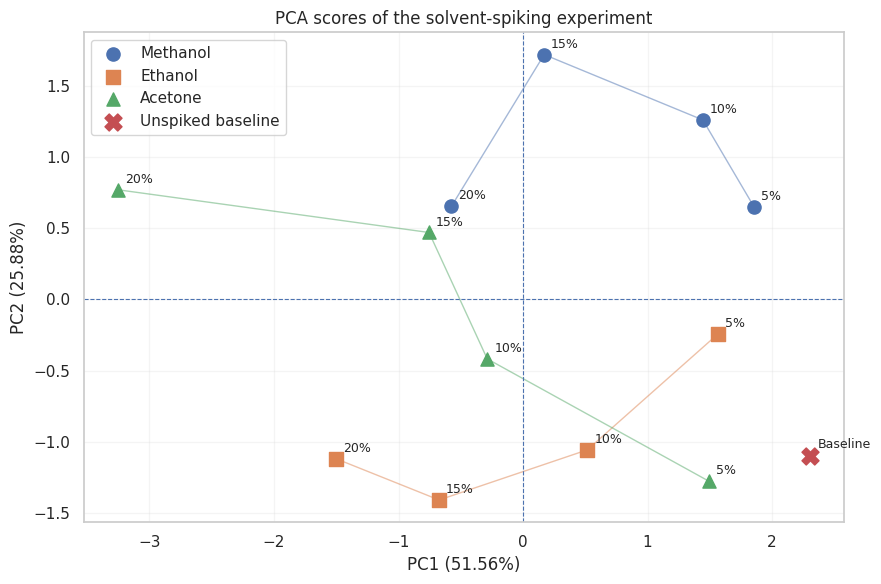

In [ ]:
plt.figure(figsize=(9, 6))

markers = {
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in [
    "Methanol",
    "Ethanol",
    "Acetone"
]:

    subset = (
        spike_scores_table[
            spike_scores_table["Solvent"] == solvent
        ]
        .sort_values("Spike_percent_vv")
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        marker=markers[solvent],
        s=90,
        label=solvent
    )

    # Show concentration sequence
    plt.plot(
        subset["PC1"],
        subset["PC2"],
        linewidth=1,
        alpha=0.5
    )

    for _, row in subset.iterrows():

        plt.annotate(
            f"{int(row['Spike_percent_vv'])}%",
            (
                row["PC1"],
                row["PC2"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

# Projected unspiked baseline
plt.scatter(
    spike_zero_score[0, 0],
    spike_zero_score[0, 1],
    marker="X",
    s=150,
    label="Unspiked baseline"
)

plt.annotate(
    "Baseline",
    (
        spike_zero_score[0, 0],
        spike_zero_score[0, 1]
    ),
    xytext=(6, 6),
    textcoords="offset points",
    fontsize=9
)

plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.axvline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.xlabel(
    f"PC1 ({spike_explained_variance[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({spike_explained_variance[1]:.2f}%)"
)

plt.title(
    "PCA scores of the solvent-spiking experiment"
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_pca_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
spike_loadings_table = pd.DataFrame(
    spike_pca_model.components_.T,
    index=[
        "465 nm",
        "625 nm",
        "850 nm",
        "940 nm"
    ],
    columns=[
        "PC1_loading",
        "PC2_loading"
    ]
)

display(
    spike_loadings_table.round(4)
)

,PC1_loading,PC2_loading
465 nm,0.2839,0.8872
625 nm,0.6820,0.0733
850 nm,-0.3685,0.3142
940 nm,-0.5643,0.3297


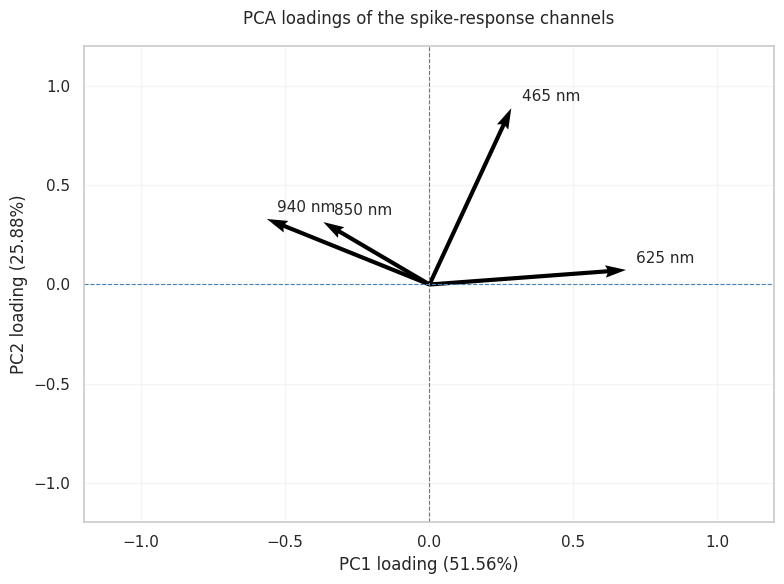

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--",
    color="steelblue"
)

ax.axvline(
    0,
    linewidth=0.8,
    linestyle="--",
    color="steelblue"
)

for wavelength in spike_loadings_table.index:

    pc1_loading = spike_loadings_table.loc[
        wavelength,
        "PC1_loading"
    ]

    pc2_loading = spike_loadings_table.loc[
        wavelength,
        "PC2_loading"
    ]

    ax.quiver(
        0,
        0,
        pc1_loading,
        pc2_loading,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.006,
        color="black"
    )

    ax.annotate(
        wavelength,
        xy=(
            pc1_loading,
            pc2_loading
        ),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=11
    )

maximum_loading = (
    np.abs(
        spike_loadings_table[
            ["PC1_loading", "PC2_loading"]
        ].to_numpy()
    ).max()
)

axis_limit = maximum_loading * 1.35

ax.set_xlim(
    -axis_limit,
    axis_limit
)

ax.set_ylim(
    -axis_limit,
    axis_limit
)

ax.set_xlabel(
    f"PC1 loading "
    f"({spike_explained_variance[0]:.2f}%)"
)

ax.set_ylabel(
    f"PC2 loading "
    f"({spike_explained_variance[1]:.2f}%)"
)

ax.set_title(
    "PCA loadings of the spike-response channels",
    pad=16
)

ax.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_pca_loadings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# PLS Prediction of Added Solvent Concentration

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# One unspiked baseline reference
baseline_pls_row = pd.DataFrame([{
    "Sample_ID": "Baseline_0",
    "Solvent": "Baseline",
    "Spike_percent_vv": 0,
    "465_full_pct": 0,
    "625_full_pct": 0,
    "850_full_pct": 0,
    "940_full_pct": 0
}])

# Combine one baseline with the 12 spiked samples
spike_pls_table = pd.concat(
    [
        baseline_pls_row,
        spike_pca_table
    ],
    ignore_index=True
)

display(spike_pls_table.round(3))

print(
    "PLS table shape:",
    spike_pls_table.shape
)

,Sample_ID,Solvent,Spike_percent_vv,465_full_pct,625_full_pct,850_full_pct,940_full_pct
0,Baseline_0,Baseline,0,0.000,0.000,0.000,0.000
1,Acetone_5,Acetone,5,-0.849,-3.975,0.810,0.403
2,Acetone_10,Acetone,10,-0.393,-13.768,2.013,2.265
3,Acetone_15,Acetone,15,1.232,-19.497,1.751,3.045
4,Acetone_20,Acetone,20,-0.042,-30.488,4.259,5.007
5,Ethanol_5,Ethanol,5,1.185,-3.612,-0.982,1.995
6,Ethanol_10,Ethanol,10,-0.846,-8.855,-0.662,2.581
7,Ethanol_15,Ethanol,15,-1.565,-20.157,-1.160,3.328
8,Ethanol_20,Ethanol,20,-1.618,-23.391,-1.015,4.546
9,Methanol_5,Methanol,5,2.786,-1.758,-0.333,1.880


PLS table shape: (13, 7)


In [ ]:
X_spike_pls = spike_pls_table[
    spike_pca_channels
].astype(float)

y_spike_pls = spike_pls_table[
    "Spike_percent_vv"
].to_numpy(dtype=float)

groups_spike_pls = spike_pls_table[
    "Spike_percent_vv"
].to_numpy()

print("Predictor shape:", X_spike_pls.shape)
print(
    "Concentration levels:",
    np.unique(y_spike_pls)
)

Predictor shape: (13, 4)
Concentration levels: [ 0.  5. 10. 15. 20.]


In [ ]:
unique_spike_levels = np.unique(
    groups_spike_pls
)

spike_group_cv = GroupKFold(
    n_splits=len(unique_spike_levels)
)

spike_component_results = []
spike_cv_predictions = {}

for n_components in range(1, 5):

    y_cv_pred = np.full(
        len(y_spike_pls),
        np.nan,
        dtype=float
    )

    for train_index, test_index in spike_group_cv.split(
        X_spike_pls,
        y_spike_pls,
        groups_spike_pls
    ):

        X_train = X_spike_pls.iloc[
            train_index
        ]

        X_test = X_spike_pls.iloc[
            test_index
        ]

        y_train = y_spike_pls[
            train_index
        ]

        pls_cv_model = PLSRegression(
            n_components=n_components,
            scale=True,
            max_iter=1000
        )

        pls_cv_model.fit(
            X_train,
            y_train
        )

        y_cv_pred[test_index] = (
            pls_cv_model
            .predict(X_test)
            .ravel()
        )

    press = np.sum(
        (
            y_spike_pls
            - y_cv_pred
        ) ** 2
    )

    total_sum_squares = np.sum(
        (
            y_spike_pls
            - y_spike_pls.mean()
        ) ** 2
    )

    rmsecv = np.sqrt(
        mean_squared_error(
            y_spike_pls,
            y_cv_pred
        )
    )

    mae_cv = mean_absolute_error(
        y_spike_pls,
        y_cv_pred
    )

    q_squared = (
        1
        - press / total_sum_squares
    )

    spike_component_results.append({
        "PLS_components": n_components,
        "RMSECV_percent_vv": rmsecv,
        "MAE_CV_percent_vv": mae_cv,
        "Q_squared": q_squared
    })

    spike_cv_predictions[
        n_components
    ] = y_cv_pred

In [ ]:
spike_component_results_table = pd.DataFrame(
    spike_component_results
)

display(
    spike_component_results_table.round(4)
)

,PLS_components,RMSECV_percent_vv,MAE_CV_percent_vv,Q_squared
0,1,2.2621,1.8471,0.8719
1,2,2.0419,1.6026,0.8956
2,3,2.0684,1.7045,0.8929
3,4,2.4608,2.1344,0.8484


In [ ]:
best_n_components = 2

best_spike_cv_predictions = (
    spike_cv_predictions[
        best_n_components
    ]
)

spike_prediction_table = (
    spike_pls_table[
        [
            "Sample_ID",
            "Solvent",
            "Spike_percent_vv"
        ]
    ]
    .copy()
)

spike_prediction_table[
    "Predicted_percent_vv"
] = best_spike_cv_predictions

spike_prediction_table[
    "Prediction_error"
] = (
    spike_prediction_table[
        "Predicted_percent_vv"
    ]
    - spike_prediction_table[
        "Spike_percent_vv"
    ]
)

spike_prediction_table[
    "Absolute_error"
] = np.abs(
    spike_prediction_table[
        "Prediction_error"
    ]
)

display(
    spike_prediction_table.round(3)
)

,Sample_ID,Solvent,Spike_percent_vv,Predicted_percent_vv,Prediction_error,Absolute_error
0,Baseline_0,Baseline,0,0.934,0.934,0.934
1,Acetone_5,Acetone,5,1.793,-3.207,3.207
2,Acetone_10,Acetone,10,9.915,-0.085,0.085
3,Acetone_15,Acetone,15,14.122,-0.878,0.878
4,Acetone_20,Acetone,20,24.165,4.165,4.165
5,Ethanol_5,Ethanol,5,7.972,2.972,2.972
6,Ethanol_10,Ethanol,10,9.973,-0.027,0.027
7,Ethanol_15,Ethanol,15,15.613,0.613,0.613
8,Ethanol_20,Ethanol,20,18.687,-1.313,1.313
9,Methanol_5,Methanol,5,7.439,2.439,2.439


In [ ]:
selected_press = np.sum(
    (
        y_spike_pls
        - best_spike_cv_predictions
    ) ** 2
)

selected_tss = np.sum(
    (
        y_spike_pls
        - y_spike_pls.mean()
    ) ** 2
)

selected_rmsecv = np.sqrt(
    mean_squared_error(
        y_spike_pls,
        best_spike_cv_predictions
    )
)

selected_mae = mean_absolute_error(
    y_spike_pls,
    best_spike_cv_predictions
)

selected_q_squared = (
    1
    - selected_press / selected_tss
)

print(
    f"Selected components: "
    f"{best_n_components}"
)

print(
    f"RMSECV: "
    f"{selected_rmsecv:.4f}% v/v"
)

print(
    f"MAE: "
    f"{selected_mae:.4f}% v/v"
)

print(
    f"Q²: "
    f"{selected_q_squared:.4f}"
)

Selected components: 2
RMSECV: 2.0419% v/v
MAE: 1.6026% v/v
Q²: 0.8956


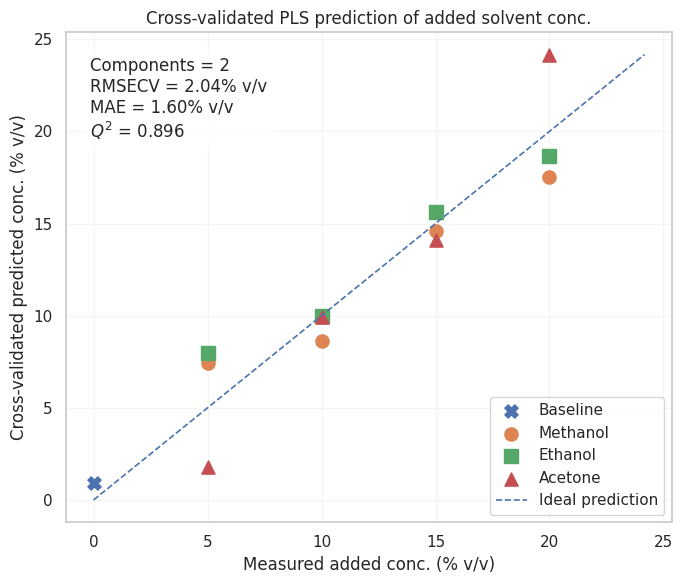

In [ ]:
plt.figure(figsize=(7, 6))

markers = {
    "Baseline": "X",
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in [
    "Baseline",
    "Methanol",
    "Ethanol",
    "Acetone"
]:

    subset = spike_prediction_table[
        spike_prediction_table[
            "Solvent"
        ] == solvent
    ]

    if len(subset) == 0:
        continue

    plt.scatter(
        subset["Spike_percent_vv"],
        subset["Predicted_percent_vv"],
        marker=markers[solvent],
        s=90,
        label=solvent
    )

# Ideal prediction line
minimum_value = min(
    spike_prediction_table[
        "Spike_percent_vv"
    ].min(),
    spike_prediction_table[
        "Predicted_percent_vv"
    ].min()
)

maximum_value = max(
    spike_prediction_table[
        "Spike_percent_vv"
    ].max(),
    spike_prediction_table[
        "Predicted_percent_vv"
    ].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.2,
    label="Ideal prediction"
)

plt.xlabel(
    "Measured added conc. (% v/v)"
)

plt.ylabel(
    "Cross-validated predicted conc. (% v/v)"
)

plt.title(
    "Cross-validated PLS prediction of added solvent conc."
)

plt.text(
    0.04,
    0.95,
    (
        f"Components = 2\n"
        f"RMSECV = {selected_rmsecv:.2f}% v/v\n"
        f"MAE = {selected_mae:.2f}% v/v\n"
        f"$Q^2$ = {selected_q_squared:.3f}"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_pls_cross_validated_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
concentration_performance = (
    spike_prediction_table
    .groupby("Spike_percent_vv")
    .agg(
        Mean_predicted=(
            "Predicted_percent_vv",
            "mean"
        ),
        Mean_error=(
            "Prediction_error",
            "mean"
        ),
        Mean_absolute_error=(
            "Absolute_error",
            "mean"
        ),
        Maximum_absolute_error=(
            "Absolute_error",
            "max"
        )
    )
    .reset_index()
)

display(
    concentration_performance.round(3)
)

,Spike_percent_vv,Mean_predicted,Mean_error,Mean_absolute_error,Maximum_absolute_error
0,0,0.934,0.934,0.934,0.934
1,5,5.735,0.735,2.873,3.207
2,10,9.507,-0.493,0.493,1.367
3,15,14.785,-0.215,0.624,0.878
4,20,20.133,0.133,2.644,4.165


In [ ]:
final_spike_pls = PLSRegression(
    n_components=2,
    scale=True,
    max_iter=1000
)

final_spike_pls.fit(
    X_spike_pls,
    y_spike_pls
)

calibration_predictions = (
    final_spike_pls
    .predict(X_spike_pls)
    .ravel()
)

calibration_rmse = np.sqrt(
    mean_squared_error(
        y_spike_pls,
        calibration_predictions
    )
)

calibration_r_squared = r2_score(
    y_spike_pls,
    calibration_predictions
)

print(
    f"Calibration R²: "
    f"{calibration_r_squared:.4f}"
)

print(
    f"Calibration RMSE: "
    f"{calibration_rmse:.4f}% v/v"
)

Calibration R²: 0.9567
Calibration RMSE: 1.3157% v/v


In [ ]:
final_spike_pls = PLSRegression(
    n_components=2,
    scale=True,
    max_iter=1000
)

final_spike_pls.fit(
    X_spike_pls,
    y_spike_pls
)

PLSRegression(max_iter=1000)

In [ ]:
def calculate_vip(pls_model, variable_names):

    scores = pls_model.x_scores_
    weights = pls_model.x_weights_
    y_loadings = pls_model.y_loadings_

    number_variables, number_components = weights.shape

    # Variation in Y explained by each component
    component_importance = np.diag(
        scores.T
        @ scores
        @ y_loadings.T
        @ y_loadings
    )

    total_importance = component_importance.sum()

    vip_scores = np.zeros(
        number_variables
    )

    for variable_index in range(
        number_variables
    ):

        weighted_contribution = 0

        for component_index in range(
            number_components
        ):

            normalised_weight = (
                weights[
                    variable_index,
                    component_index
                ] ** 2
                / np.sum(
                    weights[
                        :,
                        component_index
                    ] ** 2
                )
            )

            weighted_contribution += (
                component_importance[
                    component_index
                ]
                * normalised_weight
            )

        vip_scores[variable_index] = np.sqrt(
            number_variables
            * weighted_contribution
            / total_importance
        )

    return pd.DataFrame({
        "Wavelength": variable_names,
        "VIP_score": vip_scores
    }).sort_values(
        "VIP_score",
        ascending=False
    ).reset_index(drop=True)

In [ ]:
wavelength_names = [
    "465 nm",
    "625 nm",
    "850 nm",
    "940 nm"
]

spike_vip_table = calculate_vip(
    final_spike_pls,
    wavelength_names
)

display(
    spike_vip_table.round(3)
)

,Wavelength,VIP_score
0,940 nm,1.398
1,625 nm,1.323
2,850 nm,0.489
3,465 nm,0.235


In [ ]:
def vip_category(vip):

    if vip >= 1:
        return "Important"

    elif vip >= 0.8:
        return "Moderate"

    else:
        return "Lower contribution"


spike_vip_table[
    "Interpretation"
] = spike_vip_table[
    "VIP_score"
].apply(vip_category)

display(
    spike_vip_table.round(3)
)

,Wavelength,VIP_score,Interpretation
0,940 nm,1.398,Important
1,625 nm,1.323,Important
2,850 nm,0.489,Lower contribution
3,465 nm,0.235,Lower contribution


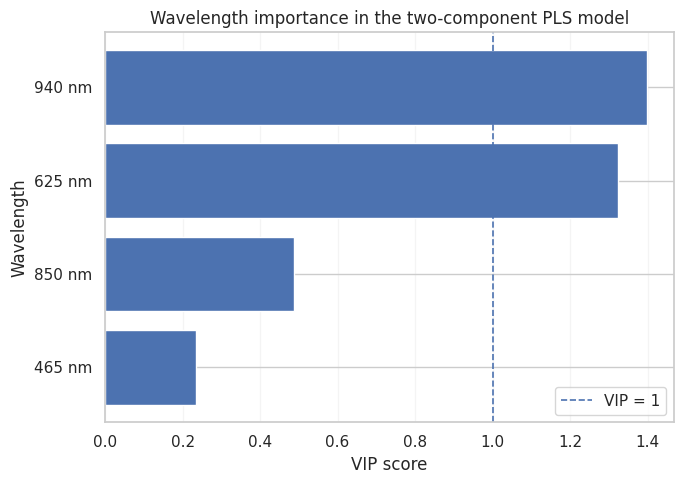

In [ ]:
vip_plot_table = (
    spike_vip_table
    .sort_values("VIP_score")
)

plt.figure(figsize=(7, 5))

plt.barh(
    vip_plot_table["Wavelength"],
    vip_plot_table["VIP_score"]
)

plt.axvline(
    1,
    linestyle="--",
    linewidth=1.2,
    label="VIP = 1"
)

plt.xlabel("VIP score")
plt.ylabel("Wavelength")

plt.title(
    "Wavelength importance in the two-component PLS model"
)

plt.legend()
plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_pls_vip_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
RSD_PATH = (
    "/content/drive/MyDrive/project_78/Spike/RSD.xlsx"
)

rsd_table = pd.read_excel(
    RSD_PATH
)

display(rsd_table)

,Solvent,465_RSD,625_RSD,850_RSD,940_RSD,spike%
0,methanol,0.469,0.164,0.033,0.025,0
1,methanol,0.040,0.152,0.046,0.047,5
2,methanol,0.033,0.156,0.051,0.042,10
3,methanol,0.055,0.149,0.035,0.042,15
4,methanol,0.114,0.210,0.015,0.012,20
5,ethanol,0.074,0.141,0.024,0.117,0
6,ethanol,0.073,0.214,0.039,0.051,5
7,ethanol,0.055,0.101,0.046,0.173,10
8,ethanol,0.116,0.207,0.027,0.035,15
9,ethanol,0.129,0.196,0.025,0.040,20


In [ ]:
# Remove accidental spaces from headings
rsd_table.columns = (
    rsd_table.columns
    .str.strip()
)

# Standardise solvent names
rsd_table["Solvent"] = (
    rsd_table["Solvent"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Rename columns to match the spike dataset
rsd_table = rsd_table.rename(
    columns={
        "spike%": "Spike_percent_vv",
        "465_RSD": "465_RSD_percent",
        "625_RSD": "625_RSD_percent",
        "850_RSD": "850_RSD_percent",
        "940_RSD": "940_RSD_percent"
    }
)

display(
    rsd_table.round(3)
)

,Solvent,465_RSD_percent,625_RSD_percent,850_RSD_percent,940_RSD_percent,Spike_percent_vv
0,Methanol,0.469,0.164,0.033,0.025,0
1,Methanol,0.040,0.152,0.046,0.047,5
2,Methanol,0.033,0.156,0.051,0.042,10
3,Methanol,0.055,0.149,0.035,0.042,15
4,Methanol,0.114,0.210,0.015,0.012,20
5,Ethanol,0.074,0.141,0.024,0.117,0
6,Ethanol,0.073,0.214,0.039,0.051,5
7,Ethanol,0.055,0.101,0.046,0.173,10
8,Ethanol,0.116,0.207,0.027,0.035,15
9,Ethanol,0.129,0.196,0.025,0.040,20


In [ ]:
spike_with_rsd = spike_relative.merge(
    rsd_table,
    on=[
        "Solvent",
        "Spike_percent_vv"
    ],
    how="left",
    validate="one_to_one"
)

rsd_columns = [
    "465_RSD_percent",
    "625_RSD_percent",
    "850_RSD_percent",
    "940_RSD_percent"
]

display(
    spike_with_rsd[
        [
            "Solvent",
            "Spike_percent_vv",
            "465_full_pct",
            "625_full_pct",
            "850_full_pct",
            "940_full_pct"
        ] + rsd_columns
    ].round(3)
)

print(
    "Merged table shape:",
    spike_with_rsd.shape
)

print(
    "\nMissing RSD values:"
)

print(
    spike_with_rsd[
        rsd_columns
    ].isna().sum()
)

,Solvent,Spike_percent_vv,465_full_pct,625_full_pct,850_full_pct,940_full_pct,465_RSD_percent,625_RSD_percent,850_RSD_percent,940_RSD_percent
0,Acetone,0,0.000,0.000,0.000,0.000,0.045,0.166,0.033,0.058
1,Acetone,5,-0.849,-3.975,0.810,0.403,0.068,0.206,0.338,0.039
2,Acetone,10,-0.393,-13.768,2.013,2.265,0.034,0.160,0.045,0.055
3,Acetone,15,1.232,-19.497,1.751,3.045,0.054,0.254,0.046,0.022
4,Acetone,20,-0.042,-30.488,4.259,5.007,0.168,0.386,0.015,0.051
5,Ethanol,0,0.000,0.000,0.000,0.000,0.074,0.141,0.024,0.117
6,Ethanol,5,1.185,-3.612,-0.982,1.995,0.073,0.214,0.039,0.051
7,Ethanol,10,-0.846,-8.855,-0.662,2.581,0.055,0.101,0.046,0.173
8,Ethanol,15,-1.565,-20.157,-1.160,3.328,0.116,0.207,0.027,0.035
9,Ethanol,20,-1.618,-23.391,-1.015,4.546,0.129,0.196,0.025,0.040


Merged table shape: (15, 20)

Missing RSD values:
465_RSD_percent    0
625_RSD_percent    0
850_RSD_percent    0
940_RSD_percent    0
dtype: int64


In [ ]:
rsd_summary = (
    spike_with_rsd[
        rsd_columns
    ]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .T
)

rsd_summary.index = [
    "465 nm",
    "625 nm",
    "850 nm",
    "940 nm"
]

display(
    rsd_summary.round(3)
)

,mean,median,min,max
465 nm,0.102,0.068,0.033,0.469
625 nm,0.191,0.166,0.101,0.386
850 nm,0.055,0.035,0.015,0.338
940 nm,0.054,0.042,0.012,0.173


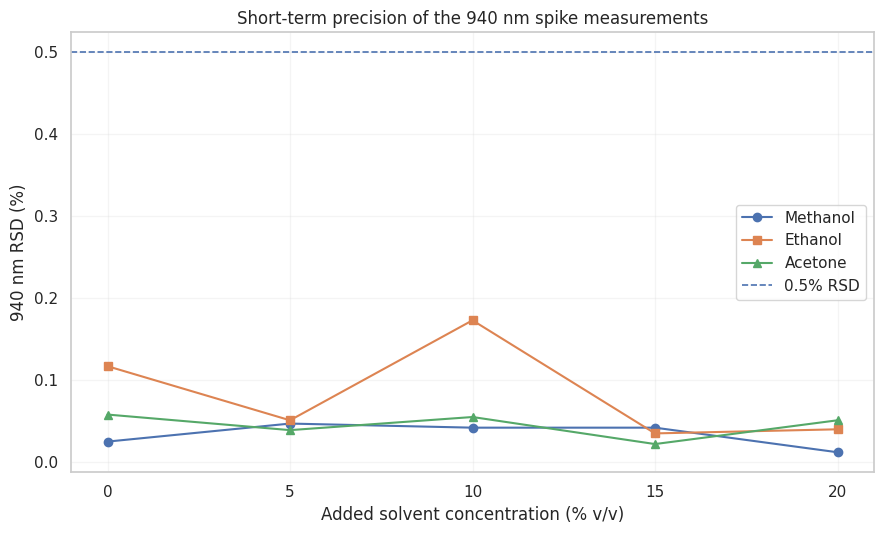

In [ ]:
plt.figure(figsize=(9, 5.5))

markers = {
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in [
    "Methanol",
    "Ethanol",
    "Acetone"
]:

    subset = (
        spike_with_rsd[
            spike_with_rsd["Solvent"] == solvent
        ]
        .sort_values("Spike_percent_vv")
    )

    plt.plot(
        subset["Spike_percent_vv"],
        subset["940_RSD_percent"],
        marker=markers[solvent],
        linewidth=1.5,
        label=solvent
    )

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label="0.5% RSD"
)

plt.xlabel(
    "Added solvent concentration (% v/v)"
)

plt.ylabel(
    "940 nm RSD (%)"
)

plt.title(
    "Short-term precision of the 940 nm spike measurements"
)

plt.xticks([0, 5, 10, 15, 20])
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "spike_940_precision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Comparison of Real Waste Samples with Final GC Results

In [ ]:
import os
import glob
import pandas as pd

REAL_WASTE_DIR = (
    "/content/drive/MyDrive/project_78/Waste"
)

waste_file_paths = sorted(
    glob.glob(
        os.path.join(
            REAL_WASTE_DIR,
            "*.csv"
        )
    )
)

print(
    "Number of CSV files found:",
    len(waste_file_paths)
)

for path in waste_file_paths:
    print(os.path.basename(path))

Number of CSV files found: 11
NEW_BASELINE.csv
x1.csv
x10.csv
x2.csv
x3.csv
x4.csv
x5.csv
x6.csv
x7.csv
x8.csv
x9.csv


In [ ]:
waste_file_audit = []

for path in waste_file_paths:

    df = pd.read_csv(path)

    sample_value = (
        df["sample"].iloc[0]
        if "sample" in df.columns and len(df) > 0
        else "Not available"
    )

    waste_file_audit.append({
        "Filename": os.path.basename(path),
        "Saved_sample_name": sample_value,
        "Rows": len(df),
        "Columns": ", ".join(df.columns)
    })

waste_file_audit = pd.DataFrame(
    waste_file_audit
)

display(waste_file_audit)

,Filename,Saved_sample_name,Rows,Columns
0,NEW_BASELINE.csv,water_blank,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
1,x1.csv,x1,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
2,x10.csv,x10,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
3,x2.csv,x2,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
4,x3.csv,x3,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
5,x4.csv,x4,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
6,x5.csv,x5,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
7,x6.csv,x6,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
8,x7.csv,x7,2,"sample, replicate, 465_full, 465_IR, 625_full,..."
9,x8.csv,x8,2,"sample, replicate, 465_full, 465_IR, 625_full,..."


In [ ]:
import os
import re
import numpy as np
import pandas as pd

channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

waste_optical_rows = []

for sample_number in range(1, 11):

    sample_id = f"X{sample_number}"

    filepath = os.path.join(
        REAL_WASTE_DIR,
        f"x{sample_number}.csv"
    )

    df = pd.read_csv(filepath)

    row = {
        "Sample_ID": sample_id,
        "Saved_rows": len(df)
    }

    for channel in channels:

        channel_mean = df[channel].mean()

        # Sample SD across the two saved measurements
        channel_sd = df[channel].std(ddof=1)

        channel_rsd = (
            channel_sd / channel_mean * 100
            if channel_mean != 0
            else np.nan
        )

        row[channel] = channel_mean
        row[f"{channel}_SD"] = channel_sd
        row[f"{channel}_RSD"] = channel_rsd

    waste_optical_rows.append(row)

waste_optical = pd.DataFrame(
    waste_optical_rows
)

display(
    waste_optical.round(3)
)

print(
    "Optical table shape:",
    waste_optical.shape
)

,Sample_ID,Saved_rows,465_full,465_full_SD,465_full_RSD,625_full,625_full_SD,625_full_RSD,850_full,850_full_SD,850_full_RSD,940_full,940_full_SD,940_full_RSD
0,X1,2,9.00,0.000,0.000,17.90,0.000,0.000,140.50,0.707,0.503,1766.10,2.121,0.120
1,X2,2,905.40,1.980,0.219,432.95,4.172,0.964,1924.35,6.010,0.312,17004.10,17.395,0.102
2,X3,2,846.65,9.122,1.077,316.50,1.980,0.626,2060.65,0.495,0.024,17627.95,90.298,0.512
3,X4,2,6.00,0.000,0.000,9.15,0.212,2.318,39.70,0.000,0.000,538.85,0.495,0.092
4,X5,2,1069.10,0.141,0.013,332.60,0.283,0.085,2091.20,6.223,0.298,17290.85,2.758,0.016
5,X6,2,999.25,3.748,0.375,224.50,0.990,0.441,2107.95,8.556,0.406,17307.50,55.437,0.320
6,X7,2,1103.60,6.364,0.577,439.10,0.283,0.064,2124.50,7.637,0.359,17515.30,21.072,0.120
7,X8,2,1019.40,23.476,2.303,362.40,3.394,0.937,2119.75,4.313,0.203,17441.40,23.052,0.132
8,X9,2,1078.35,2.051,0.190,387.25,4.879,1.260,2031.05,0.354,0.017,17661.30,6.505,0.037
9,X10,2,898.75,17.041,1.896,171.25,3.748,2.188,2116.65,11.102,0.524,18042.10,15.556,0.086


Optical table shape: (10, 14)


In [ ]:
baseline_path = os.path.join(
    REAL_WASTE_DIR,
    "NEW_BASELINE.csv"
)

baseline_df = pd.read_csv(
    baseline_path
)

water_baseline = baseline_df[
    channels
].mean()

print("Water baseline means:")

display(
    water_baseline
    .to_frame("Mean_response")
    .round(3)
)

Water baseline means:


,Mean_response
465_full,1344.35
625_full,465.20
850_full,2140.20
940_full,17821.35


In [ ]:
waste_relative = waste_optical.copy()

for channel in channels:

    baseline_value = water_baseline[channel]

    waste_relative[
        f"{channel}_pct"
    ] = (
        (
            waste_relative[channel]
            - baseline_value
        )
        / baseline_value
    ) * 100

In [ ]:
relative_columns = [
    "465_full_pct",
    "625_full_pct",
    "850_full_pct",
    "940_full_pct"
]

display(
    waste_relative[
        ["Sample_ID"] + relative_columns
    ].round(3)
)

,Sample_ID,465_full_pct,625_full_pct,850_full_pct,940_full_pct
0,X1,-99.331,-96.152,-93.435,-90.090
1,X2,-32.651,-6.933,-10.086,-4.586
2,X3,-37.022,-31.965,-3.717,-1.085
3,X4,-99.554,-98.033,-98.145,-96.976
4,X5,-20.475,-28.504,-2.290,-2.977
5,X6,-25.670,-51.741,-1.507,-2.883
6,X7,-17.908,-5.610,-0.734,-1.717
7,X8,-24.172,-22.098,-0.956,-2.132
8,X9,-19.787,-16.756,-5.100,-0.898
9,X10,-33.146,-63.188,-1.100,1.239


In [ ]:
GC_PATH = (
    "/content/drive/MyDrive/project_78/"
    "Final_GC_Clean_Table.xlsx"
)

gc_final = pd.read_excel(
    GC_PATH,
    sheet_name="Model Ready",
    skiprows=3
)

gc_final = gc_final.rename(
    columns={"Sample": "Sample_ID"}
)

display(gc_final)

,Sample_ID,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L
0,X1,536.451296,2869.911311,397.850368
1,X2,9987.726947,29449.488512,NaN
2,X3,603.748253,1660.474382,707.566393
3,X4,5094.414812,76176.693287,7916.896068
4,X5,21852.746664,661.643398,2602.018098
5,X6,NaN,3790.514213,2704.457492
6,X7,23350.840420,NaN,74.029943
7,X8,288.354911,3571.110853,8501.418694
8,X9,28140.562044,NaN,2030.985301
9,X10,11322.756886,NaN,4599.986036


In [ ]:
gc_columns = [
    "Methanol_mg_L",
    "Ethanol_mg_L",
    "Acetone_mg_L"
]

gc_final[
    "Quantified_solvent_count"
] = gc_final[
    gc_columns
].notna().sum(axis=1)

gc_final[
    "Total_quantified_solvent_mg_L"
] = gc_final[
    gc_columns
].sum(
    axis=1,
    skipna=True
)

display(
    gc_final.round(3)
)

,Sample_ID,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Quantified_solvent_count,Total_quantified_solvent_mg_L
0,X1,536.451,2869.911,397.850,3,3804.213
1,X2,9987.727,29449.489,NaN,2,39437.215
2,X3,603.748,1660.474,707.566,3,2971.789
3,X4,5094.415,76176.693,7916.896,3,89188.004
4,X5,21852.747,661.643,2602.018,3,25116.408
5,X6,NaN,3790.514,2704.457,2,6494.972
6,X7,23350.840,NaN,74.030,2,23424.870
7,X8,288.355,3571.111,8501.419,3,12360.884
8,X9,28140.562,NaN,2030.985,2,30171.547
9,X10,11322.757,NaN,4599.986,2,15922.743


In [ ]:
waste_gc_combined = waste_relative.merge(
    gc_final,
    on="Sample_ID",
    how="left",
    validate="one_to_one"
)

display(
    waste_gc_combined.round(3)
)

print(
    "Combined table shape:",
    waste_gc_combined.shape
)

print(
    "\nMissing GC sample rows:",
    waste_gc_combined[
        "Total_quantified_solvent_mg_L"
    ].isna().sum()
)

,Sample_ID,Saved_rows,465_full,465_full_SD,465_full_RSD,625_full,625_full_SD,625_full_RSD,850_full,850_full_SD,...,940_full_RSD,465_full_pct,625_full_pct,850_full_pct,940_full_pct,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Quantified_solvent_count,Total_quantified_solvent_mg_L
0,X1,2,9.00,0.000,0.000,17.90,0.000,0.000,140.50,0.707,...,0.120,-99.331,-96.152,-93.435,-90.090,536.451,2869.911,397.850,3,3804.213
1,X2,2,905.40,1.980,0.219,432.95,4.172,0.964,1924.35,6.010,...,0.102,-32.651,-6.933,-10.086,-4.586,9987.727,29449.489,NaN,2,39437.215
2,X3,2,846.65,9.122,1.077,316.50,1.980,0.626,2060.65,0.495,...,0.512,-37.022,-31.965,-3.717,-1.085,603.748,1660.474,707.566,3,2971.789
3,X4,2,6.00,0.000,0.000,9.15,0.212,2.318,39.70,0.000,...,0.092,-99.554,-98.033,-98.145,-96.976,5094.415,76176.693,7916.896,3,89188.004
4,X5,2,1069.10,0.141,0.013,332.60,0.283,0.085,2091.20,6.223,...,0.016,-20.475,-28.504,-2.290,-2.977,21852.747,661.643,2602.018,3,25116.408
5,X6,2,999.25,3.748,0.375,224.50,0.990,0.441,2107.95,8.556,...,0.320,-25.670,-51.741,-1.507,-2.883,NaN,3790.514,2704.457,2,6494.972
6,X7,2,1103.60,6.364,0.577,439.10,0.283,0.064,2124.50,7.637,...,0.120,-17.908,-5.610,-0.734,-1.717,23350.840,NaN,74.030,2,23424.870
7,X8,2,1019.40,23.476,2.303,362.40,3.394,0.937,2119.75,4.313,...,0.132,-24.172,-22.098,-0.956,-2.132,288.355,3571.111,8501.419,3,12360.884
8,X9,2,1078.35,2.051,0.190,387.25,4.879,1.260,2031.05,0.354,...,0.037,-19.787,-16.756,-5.100,-0.898,28140.562,NaN,2030.985,2,30171.547
9,X10,2,898.75,17.041,1.896,171.25,3.748,2.188,2116.65,11.102,...,0.086,-33.146,-63.188,-1.100,1.239,11322.757,NaN,4599.986,2,15922.743


Combined table shape: (10, 23)

Missing GC sample rows: 0


In [ ]:
waste_gc_combined = waste_relative.merge(
    gc_final,
    on="Sample_ID",
    how="left",
    validate="one_to_one"
)

display(
    waste_gc_combined.round(3)
)

print(
    "Combined table shape:",
    waste_gc_combined.shape
)

print(
    "\nMissing GC sample rows:",
    waste_gc_combined[
        "Total_quantified_solvent_mg_L"
    ].isna().sum()
)

,Sample_ID,Saved_rows,465_full,465_full_SD,465_full_RSD,625_full,625_full_SD,625_full_RSD,850_full,850_full_SD,...,940_full_RSD,465_full_pct,625_full_pct,850_full_pct,940_full_pct,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Quantified_solvent_count,Total_quantified_solvent_mg_L
0,X1,2,9.00,0.000,0.000,17.90,0.000,0.000,140.50,0.707,...,0.120,-99.331,-96.152,-93.435,-90.090,536.451,2869.911,397.850,3,3804.213
1,X2,2,905.40,1.980,0.219,432.95,4.172,0.964,1924.35,6.010,...,0.102,-32.651,-6.933,-10.086,-4.586,9987.727,29449.489,NaN,2,39437.215
2,X3,2,846.65,9.122,1.077,316.50,1.980,0.626,2060.65,0.495,...,0.512,-37.022,-31.965,-3.717,-1.085,603.748,1660.474,707.566,3,2971.789
3,X4,2,6.00,0.000,0.000,9.15,0.212,2.318,39.70,0.000,...,0.092,-99.554,-98.033,-98.145,-96.976,5094.415,76176.693,7916.896,3,89188.004
4,X5,2,1069.10,0.141,0.013,332.60,0.283,0.085,2091.20,6.223,...,0.016,-20.475,-28.504,-2.290,-2.977,21852.747,661.643,2602.018,3,25116.408
5,X6,2,999.25,3.748,0.375,224.50,0.990,0.441,2107.95,8.556,...,0.320,-25.670,-51.741,-1.507,-2.883,NaN,3790.514,2704.457,2,6494.972
6,X7,2,1103.60,6.364,0.577,439.10,0.283,0.064,2124.50,7.637,...,0.120,-17.908,-5.610,-0.734,-1.717,23350.840,NaN,74.030,2,23424.870
7,X8,2,1019.40,23.476,2.303,362.40,3.394,0.937,2119.75,4.313,...,0.132,-24.172,-22.098,-0.956,-2.132,288.355,3571.111,8501.419,3,12360.884
8,X9,2,1078.35,2.051,0.190,387.25,4.879,1.260,2031.05,0.354,...,0.037,-19.787,-16.756,-5.100,-0.898,28140.562,NaN,2030.985,2,30171.547
9,X10,2,898.75,17.041,1.896,171.25,3.748,2.188,2116.65,11.102,...,0.086,-33.146,-63.188,-1.100,1.239,11322.757,NaN,4599.986,2,15922.743


Combined table shape: (10, 23)

Missing GC sample rows: 0


In [ ]:
gc_final = gc_final.rename(
    columns={
        "Sample": "Sample_ID"
    }
)

gc_final["Sample_ID"] = (
    gc_final["Sample_ID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

display(gc_final.round(3))

print("GC table shape:", gc_final.shape)
print("GC columns:", gc_final.columns.tolist())

,Sample_ID,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Quantified_solvent_count,Total_quantified_solvent_mg_L
0,X1,536.451,2869.911,397.850,3,3804.213
1,X2,9987.727,29449.489,NaN,2,39437.215
2,X3,603.748,1660.474,707.566,3,2971.789
3,X4,5094.415,76176.693,7916.896,3,89188.004
4,X5,21852.747,661.643,2602.018,3,25116.408
5,X6,NaN,3790.514,2704.457,2,6494.972
6,X7,23350.840,NaN,74.030,2,23424.870
7,X8,288.355,3571.111,8501.419,3,12360.884
8,X9,28140.562,NaN,2030.985,2,30171.547
9,X10,11322.757,NaN,4599.986,2,15922.743


GC table shape: (10, 6)
GC columns: ['Sample_ID', 'Methanol_mg_L', 'Ethanol_mg_L', 'Acetone_mg_L', 'Quantified_solvent_count', 'Total_quantified_solvent_mg_L']


In [ ]:
print("Missing quantitative results:")

print(
    gc_final[
        [
            "Methanol_mg_L",
            "Ethanol_mg_L",
            "Acetone_mg_L"
        ]
    ].isna().sum()
)

Missing quantitative results:
Methanol_mg_L    1
Ethanol_mg_L     3
Acetone_mg_L     1
dtype: int64


In [ ]:
display(
    gc_final.style.format({
        "Methanol_mg_L": "{:,.2f}",
        "Ethanol_mg_L": "{:,.2f}",
        "Acetone_mg_L": "{:,.2f}"
    })
)

,Sample_ID,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Quantified_solvent_count,Total_quantified_solvent_mg_L
0,X1,536.45,"2,869.91",397.85,3,3804.212975
1,X2,"9,987.73","29,449.49",nan,2,39437.215458
2,X3,603.75,"1,660.47",707.57,3,2971.789029
3,X4,"5,094.41","76,176.69","7,916.90",3,89188.004168
4,X5,"21,852.75",661.64,"2,602.02",3,25116.408160
5,X6,nan,"3,790.51","2,704.46",2,6494.971705
6,X7,"23,350.84",nan,74.03,2,23424.870363
7,X8,288.35,"3,571.11","8,501.42",3,12360.884459
8,X9,"28,140.56",nan,"2,030.99",2,30171.547345
9,X10,"11,322.76",nan,"4,599.99",2,15922.742922


In [ ]:
import os
import numpy as np
import pandas as pd

REAL_WASTE_DIR = (
    "/content/drive/MyDrive/project_78/Waste"
)

print("Folder found:", os.path.exists(REAL_WASTE_DIR))

Folder found: True


In [ ]:
optical_channels = [
    "465_full",
    "625_full",
    "850_full",
    "940_full"
]

In [ ]:
waste_optical_rows = []

for sample_number in range(1, 11):

    sample_id = f"X{sample_number}"

    file_path = os.path.join(
        REAL_WASTE_DIR,
        f"x{sample_number}.csv"
    )

    sample_df = pd.read_csv(file_path)

    row = {
        "Sample_ID": sample_id,
        "Number_of_saved_measurements": len(sample_df)
    }

    for channel in optical_channels:

        mean_value = sample_df[channel].mean()
        sd_value = sample_df[channel].std(ddof=1)

        if mean_value != 0:
            rsd_value = (
                sd_value / mean_value
            ) * 100
        else:
            rsd_value = np.nan

        row[channel] = mean_value
        row[f"{channel}_SD"] = sd_value
        row[f"{channel}_RSD_percent"] = rsd_value

    waste_optical_rows.append(row)

waste_optical = pd.DataFrame(
    waste_optical_rows
)

display(
    waste_optical.round(3)
)

print(
    "Optical table shape:",
    waste_optical.shape
)

,Sample_ID,Number_of_saved_measurements,465_full,465_full_SD,465_full_RSD_percent,625_full,625_full_SD,625_full_RSD_percent,850_full,850_full_SD,850_full_RSD_percent,940_full,940_full_SD,940_full_RSD_percent
0,X1,2,9.00,0.000,0.000,17.90,0.000,0.000,140.50,0.707,0.503,1766.10,2.121,0.120
1,X2,2,905.40,1.980,0.219,432.95,4.172,0.964,1924.35,6.010,0.312,17004.10,17.395,0.102
2,X3,2,846.65,9.122,1.077,316.50,1.980,0.626,2060.65,0.495,0.024,17627.95,90.298,0.512
3,X4,2,6.00,0.000,0.000,9.15,0.212,2.318,39.70,0.000,0.000,538.85,0.495,0.092
4,X5,2,1069.10,0.141,0.013,332.60,0.283,0.085,2091.20,6.223,0.298,17290.85,2.758,0.016
5,X6,2,999.25,3.748,0.375,224.50,0.990,0.441,2107.95,8.556,0.406,17307.50,55.437,0.320
6,X7,2,1103.60,6.364,0.577,439.10,0.283,0.064,2124.50,7.637,0.359,17515.30,21.072,0.120
7,X8,2,1019.40,23.476,2.303,362.40,3.394,0.937,2119.75,4.313,0.203,17441.40,23.052,0.132
8,X9,2,1078.35,2.051,0.190,387.25,4.879,1.260,2031.05,0.354,0.017,17661.30,6.505,0.037
9,X10,2,898.75,17.041,1.896,171.25,3.748,2.188,2116.65,11.102,0.524,18042.10,15.556,0.086


Optical table shape: (10, 14)


In [ ]:
rsd_columns = [
    "465_full_RSD_percent",
    "625_full_RSD_percent",
    "850_full_RSD_percent",
    "940_full_RSD_percent"
]

waste_rsd_summary = (
    waste_optical[
        rsd_columns
    ]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .T
)

waste_rsd_summary.index = [
    "465 nm",
    "625 nm",
    "850 nm",
    "940 nm"
]

display(
    waste_rsd_summary.round(3)
)

,mean,median,min,max
465 nm,0.665,0.297,0.000,2.303
625 nm,0.888,0.781,0.000,2.318
850 nm,0.265,0.305,0.000,0.524
940 nm,0.154,0.111,0.016,0.512


In [ ]:
for column in rsd_columns:

    print(
        "\n",
        column
    )

    display(
        waste_optical[
            [
                "Sample_ID",
                column
            ]
        ]
        .sort_values(
            column,
            ascending=False
        )
        .head(3)
        .round(3)
    )


 465_full_RSD_percent


,Sample_ID,465_full_RSD_percent
7,X8,2.303
9,X10,1.896
2,X3,1.077



 625_full_RSD_percent


,Sample_ID,625_full_RSD_percent
3,X4,2.318
9,X10,2.188
8,X9,1.260



 850_full_RSD_percent


,Sample_ID,850_full_RSD_percent
9,X10,0.524
0,X1,0.503
5,X6,0.406



 940_full_RSD_percent


,Sample_ID,940_full_RSD_percent
2,X3,0.512
5,X6,0.320
7,X8,0.132


In [ ]:
baseline_path = os.path.join(
    REAL_WASTE_DIR,
    "NEW_BASELINE.csv"
)

baseline_df = pd.read_csv(
    baseline_path
)

display(
    baseline_df
)

,sample,replicate,465_full,465_IR,625_full,625_IR,850_full,850_IR,940_full,940_IR
0,water_blank,1,1335.3,22.0,469.2,104.7,2140.8,1334.3,17899.1,12828.5
1,water_blank,2,1353.4,23.0,461.2,102.9,2139.6,1333.8,17743.6,12716.4


In [ ]:
water_baseline = (
    baseline_df[
        optical_channels
    ]
    .mean()
)

water_baseline_table = (
    water_baseline
    .to_frame(
        name="Mean_water_response"
    )
)

display(
    water_baseline_table.round(3)
)

,Mean_water_response
465_full,1344.35
625_full,465.20
850_full,2140.20
940_full,17821.35


In [ ]:
baseline_precision_rows = []

for channel in optical_channels:

    mean_value = baseline_df[channel].mean()
    sd_value = baseline_df[channel].std(ddof=1)

    rsd_value = (
        sd_value / mean_value * 100
        if mean_value != 0
        else np.nan
    )

    baseline_precision_rows.append({
        "Channel": channel,
        "Mean": mean_value,
        "SD": sd_value,
        "RSD_percent": rsd_value
    })

baseline_precision = pd.DataFrame(
    baseline_precision_rows
)

display(
    baseline_precision.round(3)
)

,Channel,Mean,SD,RSD_percent
0,465_full,1344.35,12.799,0.952
1,625_full,465.20,5.657,1.216
2,850_full,2140.20,0.849,0.040
3,940_full,17821.35,109.955,0.617


## Water-relative response of real waste samples

In [ ]:
waste_relative = waste_optical.copy()

for channel in optical_channels:

    baseline_value = water_baseline[channel]

    waste_relative[f"{channel}_pct_change"] = (
        (
            waste_relative[channel]
            - baseline_value
        )
        / baseline_value
    ) * 100

In [ ]:
relative_columns = [
    "465_full_pct_change",
    "625_full_pct_change",
    "850_full_pct_change",
    "940_full_pct_change"
]

display(
    waste_relative[
        ["Sample_ID"] + relative_columns
    ].round(3)
)

,Sample_ID,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change
0,X1,-99.331,-96.152,-93.435,-90.090
1,X2,-32.651,-6.933,-10.086,-4.586
2,X3,-37.022,-31.965,-3.717,-1.085
3,X4,-99.554,-98.033,-98.145,-96.976
4,X5,-20.475,-28.504,-2.290,-2.977
5,X6,-25.670,-51.741,-1.507,-2.883
6,X7,-17.908,-5.610,-0.734,-1.717
7,X8,-24.172,-22.098,-0.956,-2.132
8,X9,-19.787,-16.756,-5.100,-0.898
9,X10,-33.146,-63.188,-1.100,1.239


In [ ]:
for column in relative_columns:

    print(f"\n{column}")

    display(
        waste_relative[
            ["Sample_ID", column]
        ]
        .sort_values(column)
        .round(3)
    )


465_full_pct_change


,Sample_ID,465_full_pct_change
3,X4,-99.554
0,X1,-99.331
2,X3,-37.022
9,X10,-33.146
1,X2,-32.651
5,X6,-25.670
7,X8,-24.172
4,X5,-20.475
8,X9,-19.787
6,X7,-17.908



625_full_pct_change


,Sample_ID,625_full_pct_change
3,X4,-98.033
0,X1,-96.152
9,X10,-63.188
5,X6,-51.741
2,X3,-31.965
4,X5,-28.504
7,X8,-22.098
8,X9,-16.756
1,X2,-6.933
6,X7,-5.610



850_full_pct_change


,Sample_ID,850_full_pct_change
3,X4,-98.145
0,X1,-93.435
1,X2,-10.086
8,X9,-5.100
2,X3,-3.717
4,X5,-2.290
5,X6,-1.507
9,X10,-1.100
7,X8,-0.956
6,X7,-0.734



940_full_pct_change


,Sample_ID,940_full_pct_change
3,X4,-96.976
0,X1,-90.090
1,X2,-4.586
4,X5,-2.977
5,X6,-2.883
7,X8,-2.132
6,X7,-1.717
2,X3,-1.085
8,X9,-0.898
9,X10,1.239


In [ ]:
waste_gc_combined = waste_relative.merge(
    gc_final,
    on="Sample_ID",
    how="left",
    validate="one_to_one"
)

print(
    "Combined table shape:",
    waste_gc_combined.shape
)

display(
    waste_gc_combined[
        [
            "Sample_ID",
            "465_full_pct_change",
            "625_full_pct_change",
            "850_full_pct_change",
            "940_full_pct_change",
            "Methanol_mg_L",
            "Ethanol_mg_L",
            "Acetone_mg_L"
        ]
    ].round(3)
)

Combined table shape: (10, 23)


,Sample_ID,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L
0,X1,-99.331,-96.152,-93.435,-90.090,536.451,2869.911,397.850
1,X2,-32.651,-6.933,-10.086,-4.586,9987.727,29449.489,NaN
2,X3,-37.022,-31.965,-3.717,-1.085,603.748,1660.474,707.566
3,X4,-99.554,-98.033,-98.145,-96.976,5094.415,76176.693,7916.896
4,X5,-20.475,-28.504,-2.290,-2.977,21852.747,661.643,2602.018
5,X6,-25.670,-51.741,-1.507,-2.883,NaN,3790.514,2704.457
6,X7,-17.908,-5.610,-0.734,-1.717,23350.840,NaN,74.030
7,X8,-24.172,-22.098,-0.956,-2.132,288.355,3571.111,8501.419
8,X9,-19.787,-16.756,-5.100,-0.898,28140.562,NaN,2030.985
9,X10,-33.146,-63.188,-1.100,1.239,11322.757,NaN,4599.986


In [ ]:
print(
    "Rows without any matched GC result:",
    waste_gc_combined[
        [
            "Methanol_mg_L",
            "Ethanol_mg_L",
            "Acetone_mg_L"
        ]
    ].isna().all(axis=1).sum()
)

Rows without any matched GC result: 0


In [ ]:
gc_analyte_columns = [
    "Methanol_mg_L",
    "Ethanol_mg_L",
    "Acetone_mg_L"
]

waste_gc_combined[
    "Quantified_solvent_count"
] = (
    waste_gc_combined[
        gc_analyte_columns
    ]
    .notna()
    .sum(axis=1)
)

waste_gc_combined[
    "Total_quantified_solvent_mg_L"
] = (
    waste_gc_combined[
        gc_analyte_columns
    ]
    .sum(
        axis=1,
        skipna=True
    )
)

waste_gc_combined[
    "Total_status"
] = np.where(
    waste_gc_combined[
        "Quantified_solvent_count"
    ] == 3,
    "Complete quantified sum",
    "Partial quantified sum"
)

display(
    waste_gc_combined[
        [
            "Sample_ID",
            "Methanol_mg_L",
            "Ethanol_mg_L",
            "Acetone_mg_L",
            "Total_quantified_solvent_mg_L",
            "Quantified_solvent_count",
            "Total_status"
        ]
    ].round(3)
)

,Sample_ID,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Total_quantified_solvent_mg_L,Quantified_solvent_count,Total_status
0,X1,536.451,2869.911,397.850,3804.213,3,Complete quantified sum
1,X2,9987.727,29449.489,NaN,39437.215,2,Partial quantified sum
2,X3,603.748,1660.474,707.566,2971.789,3,Complete quantified sum
3,X4,5094.415,76176.693,7916.896,89188.004,3,Complete quantified sum
4,X5,21852.747,661.643,2602.018,25116.408,3,Complete quantified sum
5,X6,NaN,3790.514,2704.457,6494.972,2,Partial quantified sum
6,X7,23350.840,NaN,74.030,23424.870,2,Partial quantified sum
7,X8,288.355,3571.111,8501.419,12360.884,3,Complete quantified sum
8,X9,28140.562,NaN,2030.985,30171.547,2,Partial quantified sum
9,X10,11322.757,NaN,4599.986,15922.743,2,Partial quantified sum


In [ ]:
documented_cloudy_samples = [
    "X1",
    "X4"
]

waste_gc_combined["Appearance"] = np.where(
    waste_gc_combined["Sample_ID"].isin(
        documented_cloudy_samples
    ),
    "Cloudy",
    "Clear"
)

In [ ]:
waste_gc_combined[
    "Extreme_optical_attenuation"
] = np.where(
    waste_gc_combined[
        [
            "465_full_pct_change",
            "625_full_pct_change",
            "850_full_pct_change",
            "940_full_pct_change"
        ]
    ].min(axis=1) <= -80,
    "Yes",
    "No"
)

display(
    waste_gc_combined[
        [
            "Sample_ID",
            "Appearance",
            "Extreme_optical_attenuation",
            "465_full_pct_change",
            "625_full_pct_change",
            "850_full_pct_change",
            "940_full_pct_change"
        ]
    ].round(3)
)

,Sample_ID,Appearance,Extreme_optical_attenuation,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change
0,X1,Cloudy,Yes,-99.331,-96.152,-93.435,-90.090
1,X2,Clear,No,-32.651,-6.933,-10.086,-4.586
2,X3,Clear,No,-37.022,-31.965,-3.717,-1.085
3,X4,Cloudy,Yes,-99.554,-98.033,-98.145,-96.976
4,X5,Clear,No,-20.475,-28.504,-2.290,-2.977
5,X6,Clear,No,-25.670,-51.741,-1.507,-2.883
6,X7,Clear,No,-17.908,-5.610,-0.734,-1.717
7,X8,Clear,No,-24.172,-22.098,-0.956,-2.132
8,X9,Clear,No,-19.787,-16.756,-5.100,-0.898
9,X10,Clear,No,-33.146,-63.188,-1.100,1.239


In [ ]:
gc_analyte_columns = [
    "Methanol_mg_L",
    "Ethanol_mg_L",
    "Acetone_mg_L"
]

waste_gc_combined[
    "Quantified_solvent_count"
] = (
    waste_gc_combined[
        gc_analyte_columns
    ]
    .notna()
    .sum(axis=1)
)

waste_gc_combined[
    "Total_quantified_solvent_mg_L"
] = (
    waste_gc_combined[
        gc_analyte_columns
    ]
    .sum(
        axis=1,
        skipna=True
    )
)

waste_gc_combined[
    "Total_status"
] = np.where(
    waste_gc_combined[
        "Quantified_solvent_count"
    ] == 3,
    "Complete quantified sum",
    "Partial quantified sum"
)

display(
    waste_gc_combined[
        [
            "Sample_ID",
            "Appearance",
            "Methanol_mg_L",
            "Ethanol_mg_L",
            "Acetone_mg_L",
            "Total_quantified_solvent_mg_L",
            "Total_status"
        ]
    ].round(3)
)

,Sample_ID,Appearance,Methanol_mg_L,Ethanol_mg_L,Acetone_mg_L,Total_quantified_solvent_mg_L,Total_status
0,X1,Cloudy,536.451,2869.911,397.850,3804.213,Complete quantified sum
1,X2,Clear,9987.727,29449.489,NaN,39437.215,Partial quantified sum
2,X3,Clear,603.748,1660.474,707.566,2971.789,Complete quantified sum
3,X4,Cloudy,5094.415,76176.693,7916.896,89188.004,Complete quantified sum
4,X5,Clear,21852.747,661.643,2602.018,25116.408,Complete quantified sum
5,X6,Clear,NaN,3790.514,2704.457,6494.972,Partial quantified sum
6,X7,Clear,23350.840,NaN,74.030,23424.870,Partial quantified sum
7,X8,Clear,288.355,3571.111,8501.419,12360.884,Complete quantified sum
8,X9,Clear,28140.562,NaN,2030.985,30171.547,Partial quantified sum
9,X10,Clear,11322.757,NaN,4599.986,15922.743,Partial quantified sum


In [ ]:
# Primary analysis: all ten real waste samples
waste_all = waste_gc_combined.copy()

# Sensitivity analysis: remove only documented cloudy samples
waste_clear = waste_gc_combined[
    waste_gc_combined["Appearance"] == "Clear"
].copy()

# Additional optical-outlier sensitivity analysis
waste_without_extreme = waste_gc_combined[
    waste_gc_combined[
        "Extreme_optical_attenuation"
    ] == "No"
].copy()

print("All samples:", len(waste_all))
print("Clear samples:", len(waste_clear))
print(
    "Samples without extreme attenuation:",
    len(waste_without_extreme)
)

All samples: 10
Clear samples: 8
Samples without extreme attenuation: 8


In [ ]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
optical_response_columns = [
    "465_full_pct_change",
    "625_full_pct_change",
    "850_full_pct_change",
    "940_full_pct_change"
]

target_column = "Total_quantified_solvent_mg_L"

display(
    waste_gc_combined[
        [
            "Sample_ID",
            target_column
        ] + optical_response_columns
    ].round(3)
)

,Sample_ID,Total_quantified_solvent_mg_L,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change
0,X1,3804.213,-99.331,-96.152,-93.435,-90.090
1,X2,39437.215,-32.651,-6.933,-10.086,-4.586
2,X3,2971.789,-37.022,-31.965,-3.717,-1.085
3,X4,89188.004,-99.554,-98.033,-98.145,-96.976
4,X5,25116.408,-20.475,-28.504,-2.290,-2.977
5,X6,6494.972,-25.670,-51.741,-1.507,-2.883
6,X7,23424.870,-17.908,-5.610,-0.734,-1.717
7,X8,12360.884,-24.172,-22.098,-0.956,-2.132
8,X9,30171.547,-19.787,-16.756,-5.100,-0.898
9,X10,15922.743,-33.146,-63.188,-1.100,1.239


In [ ]:
def calculate_correlation_table(data, dataset_name):

    results = []

    for optical_column in optical_response_columns:

        valid_data = data[
            [
                optical_column,
                target_column
            ]
        ].dropna()

        pearson_r, pearson_p = pearsonr(
            valid_data[optical_column],
            valid_data[target_column]
        )

        spearman_rho, spearman_p = spearmanr(
            valid_data[optical_column],
            valid_data[target_column]
        )

        results.append({
            "Dataset": dataset_name,
            "Optical_channel": optical_column,
            "n": len(valid_data),
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_rho": spearman_rho,
            "Spearman_p": spearman_p
        })

    return pd.DataFrame(results)

In [ ]:
correlation_all = calculate_correlation_table(
    waste_gc_combined,
    "All samples"
)

display(
    correlation_all.round(4)
)

,Dataset,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All samples,465_full_pct_change,10,-0.4122,0.2366,0.1636,0.6515
1,All samples,625_full_pct_change,10,-0.2507,0.4848,0.2242,0.5334
2,All samples,850_full_pct_change,10,-0.4866,0.1538,-0.3091,0.3848
3,All samples,940_full_pct_change,10,-0.4845,0.1559,-0.2727,0.4458


In [ ]:
waste_without_extreme = waste_gc_combined[
    ~waste_gc_combined["Sample_ID"].isin(
        ["X1", "X4"]
    )
].copy()

correlation_without_extreme = calculate_correlation_table(
    waste_without_extreme,
    "Without X1 and X4"
)

display(
    correlation_without_extreme.round(4)
)

,Dataset,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Without X1 and X4,465_full_pct_change,8,0.3045,0.4634,0.4524,0.2604
1,Without X1 and X4,625_full_pct_change,8,0.6140,0.1054,0.6190,0.1017
2,Without X1 and X4,850_full_pct_change,8,-0.6562,0.0772,-0.4286,0.2894
3,Without X1 and X4,940_full_pct_change,8,-0.3914,0.3377,-0.2857,0.4927


In [ ]:
correlation_comparison = pd.concat(
    [
        correlation_all,
        correlation_without_extreme
    ],
    ignore_index=True
)

display(
    correlation_comparison.round(4)
)

,Dataset,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All samples,465_full_pct_change,10,-0.4122,0.2366,0.1636,0.6515
1,All samples,625_full_pct_change,10,-0.2507,0.4848,0.2242,0.5334
2,All samples,850_full_pct_change,10,-0.4866,0.1538,-0.3091,0.3848
3,All samples,940_full_pct_change,10,-0.4845,0.1559,-0.2727,0.4458
4,Without X1 and X4,465_full_pct_change,8,0.3045,0.4634,0.4524,0.2604
5,Without X1 and X4,625_full_pct_change,8,0.6140,0.1054,0.6190,0.1017
6,Without X1 and X4,850_full_pct_change,8,-0.6562,0.0772,-0.4286,0.2894
7,Without X1 and X4,940_full_pct_change,8,-0.3914,0.3377,-0.2857,0.4927


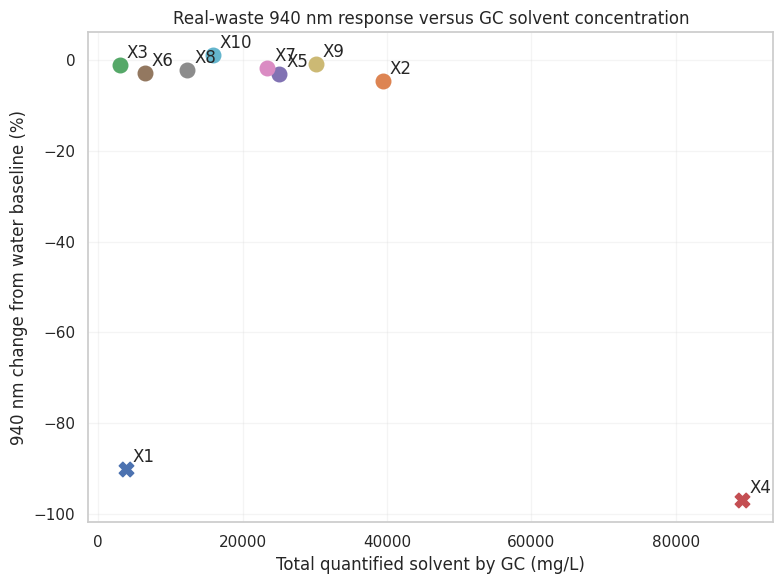

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in waste_gc_combined.iterrows():

    marker = (
        "X"
        if row["Sample_ID"] in ["X1", "X4"]
        else "o"
    )

    plt.scatter(
        row["Total_quantified_solvent_mg_L"],
        row["940_full_pct_change"],
        marker=marker,
        s=110
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["Total_quantified_solvent_mg_L"],
            row["940_full_pct_change"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel(
    "Total quantified solvent by GC (mg/L)"
)

plt.ylabel(
    "940 nm change from water baseline (%)"
)

plt.title(
    "Real-waste 940 nm response versus GC solvent concentration"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

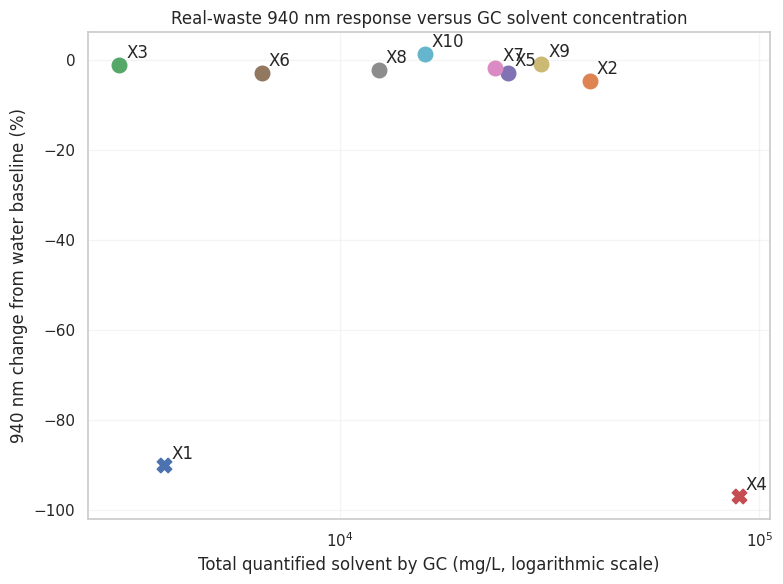

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in waste_gc_combined.iterrows():

    marker = (
        "X"
        if row["Sample_ID"] in ["X1", "X4"]
        else "o"
    )

    plt.scatter(
        row["Total_quantified_solvent_mg_L"],
        row["940_full_pct_change"],
        marker=marker,
        s=110
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["Total_quantified_solvent_mg_L"],
            row["940_full_pct_change"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xscale("log")

plt.xlabel(
    "Total quantified solvent by GC (mg/L, logarithmic scale)"
)

plt.ylabel(
    "940 nm change from water baseline (%)"
)

plt.title(
    "Real-waste 940 nm response versus GC solvent concentration"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
display(
    correlation_comparison.round(4)
)

,Dataset,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All samples,465_full_pct_change,10,-0.4122,0.2366,0.1636,0.6515
1,All samples,625_full_pct_change,10,-0.2507,0.4848,0.2242,0.5334
2,All samples,850_full_pct_change,10,-0.4866,0.1538,-0.3091,0.3848
3,All samples,940_full_pct_change,10,-0.4845,0.1559,-0.2727,0.4458
4,Without X1 and X4,465_full_pct_change,8,0.3045,0.4634,0.4524,0.2604
5,Without X1 and X4,625_full_pct_change,8,0.6140,0.1054,0.6190,0.1017
6,Without X1 and X4,850_full_pct_change,8,-0.6562,0.0772,-0.4286,0.2894
7,Without X1 and X4,940_full_pct_change,8,-0.3914,0.3377,-0.2857,0.4927


In [ ]:
analyte_targets = {
    "Methanol": "Methanol_mg_L",
    "Ethanol": "Ethanol_mg_L",
    "Acetone": "Acetone_mg_L"
}

In [ ]:
def calculate_analyte_correlations(
    data,
    dataset_name
):

    results = []

    for analyte_name, analyte_column in analyte_targets.items():

        for optical_column in optical_response_columns:

            valid_data = data[
                [
                    optical_column,
                    analyte_column
                ]
            ].dropna()

            n_samples = len(valid_data)

            if n_samples < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid_data[optical_column],
                valid_data[analyte_column]
            )

            spearman_rho, spearman_p = spearmanr(
                valid_data[optical_column],
                valid_data[analyte_column]
            )

            results.append({
                "Dataset": dataset_name,
                "Analyte": analyte_name,
                "Optical_channel": optical_column,
                "n": n_samples,
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_rho,
                "Spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [ ]:
analyte_correlations_all = (
    calculate_analyte_correlations(
        waste_gc_combined,
        "All samples"
    )
)

display(
    analyte_correlations_all.round(4)
)

,Dataset,Analyte,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All samples,Methanol,465_full_pct_change,9,0.5652,0.1128,0.6667,0.0499
1,All samples,Methanol,625_full_pct_change,9,0.5029,0.1677,0.4833,0.1875
2,All samples,Methanol,850_full_pct_change,9,0.4386,0.2377,0.2167,0.5755
3,All samples,Methanol,940_full_pct_change,9,0.4381,0.2382,0.4333,0.2440
4,All samples,Ethanol,465_full_pct_change,7,-0.5675,0.1839,-0.4643,0.2939
5,All samples,Ethanol,625_full_pct_change,7,-0.4332,0.3316,-0.1786,0.7017
6,All samples,Ethanol,850_full_pct_change,7,-0.5954,0.1584,-0.3571,0.4316
7,All samples,Ethanol,940_full_pct_change,7,-0.5917,0.1617,-0.5000,0.2532
8,All samples,Acetone,465_full_pct_change,9,-0.1670,0.6675,-0.2667,0.4879
9,All samples,Acetone,625_full_pct_change,9,-0.2434,0.5280,-0.3167,0.4064


In [ ]:
analyte_correlations_without_extreme = (
    calculate_analyte_correlations(
        waste_without_extreme,
        "Without X1 and X4"
    )
)

display(
    analyte_correlations_without_extreme.round(4)
)

,Dataset,Analyte,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Without X1 and X4,Methanol,465_full_pct_change,7,0.7324,0.0612,0.7143,0.0713
1,Without X1 and X4,Methanol,625_full_pct_change,7,0.2714,0.5561,0.3571,0.4316
2,Without X1 and X4,Methanol,850_full_pct_change,7,0.0042,0.9928,-0.0357,0.9394
3,Without X1 and X4,Methanol,940_full_pct_change,7,0.0203,0.9655,0.2857,0.5345
4,Without X1 and X4,Ethanol,465_full_pct_change,5,-0.3821,0.5256,-0.4000,0.5046
5,Without X1 and X4,Ethanol,625_full_pct_change,5,0.7008,0.1874,0.3000,0.6238
6,Without X1 and X4,Ethanol,850_full_pct_change,5,-0.9340,0.0201,-0.2000,0.7471
7,Without X1 and X4,Ethanol,940_full_pct_change,5,-0.8077,0.0982,-0.4000,0.5046
8,Without X1 and X4,Acetone,465_full_pct_change,7,-0.0677,0.8853,-0.3571,0.4316
9,Without X1 and X4,Acetone,625_full_pct_change,7,-0.2456,0.5955,-0.5000,0.2532


In [ ]:
analyte_correlation_comparison = pd.concat(
    [
        analyte_correlations_all,
        analyte_correlations_without_extreme
    ],
    ignore_index=True
)

display(
    analyte_correlation_comparison.round(4)
)

,Dataset,Analyte,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,All samples,Methanol,465_full_pct_change,9,0.5652,0.1128,0.6667,0.0499
1,All samples,Methanol,625_full_pct_change,9,0.5029,0.1677,0.4833,0.1875
2,All samples,Methanol,850_full_pct_change,9,0.4386,0.2377,0.2167,0.5755
3,All samples,Methanol,940_full_pct_change,9,0.4381,0.2382,0.4333,0.2440
4,All samples,Ethanol,465_full_pct_change,7,-0.5675,0.1839,-0.4643,0.2939
5,All samples,Ethanol,625_full_pct_change,7,-0.4332,0.3316,-0.1786,0.7017
6,All samples,Ethanol,850_full_pct_change,7,-0.5954,0.1584,-0.3571,0.4316
7,All samples,Ethanol,940_full_pct_change,7,-0.5917,0.1617,-0.5000,0.2532
8,All samples,Acetone,465_full_pct_change,9,-0.1670,0.6675,-0.2667,0.4879
9,All samples,Acetone,625_full_pct_change,9,-0.2434,0.5280,-0.3167,0.4064


In [ ]:
strongest_analyte_correlations = (
    analyte_correlation_comparison
    .assign(
        Absolute_Pearson_r=lambda table:
        table["Pearson_r"].abs()
    )
    .sort_values(
        [
            "Dataset",
            "Absolute_Pearson_r"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    strongest_analyte_correlations[
        [
            "Dataset",
            "Analyte",
            "Optical_channel",
            "n",
            "Pearson_r",
            "Pearson_p",
            "Spearman_rho",
            "Spearman_p"
        ]
    ].round(4)
)

,Dataset,Analyte,Optical_channel,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
6,All samples,Ethanol,850_full_pct_change,7,-0.5954,0.1584,-0.3571,0.4316
7,All samples,Ethanol,940_full_pct_change,7,-0.5917,0.1617,-0.5000,0.2532
4,All samples,Ethanol,465_full_pct_change,7,-0.5675,0.1839,-0.4643,0.2939
0,All samples,Methanol,465_full_pct_change,9,0.5652,0.1128,0.6667,0.0499
1,All samples,Methanol,625_full_pct_change,9,0.5029,0.1677,0.4833,0.1875
2,All samples,Methanol,850_full_pct_change,9,0.4386,0.2377,0.2167,0.5755
3,All samples,Methanol,940_full_pct_change,9,0.4381,0.2382,0.4333,0.2440
5,All samples,Ethanol,625_full_pct_change,7,-0.4332,0.3316,-0.1786,0.7017
9,All samples,Acetone,625_full_pct_change,9,-0.2434,0.5280,-0.3167,0.4064
11,All samples,Acetone,940_full_pct_change,9,-0.1832,0.6370,-0.1167,0.7650


In [ ]:
def leave_one_out_correlation(
    data,
    optical_column,
    gc_column
):

    valid_data = (
        data[
            [
                "Sample_ID",
                optical_column,
                gc_column
            ]
        ]
        .dropna()
        .copy()
    )

    results = []

    for omitted_sample in valid_data[
        "Sample_ID"
    ]:

        reduced_data = valid_data[
            valid_data["Sample_ID"]
            != omitted_sample
        ]

        pearson_r, pearson_p = pearsonr(
            reduced_data[optical_column],
            reduced_data[gc_column]
        )

        spearman_rho, spearman_p = spearmanr(
            reduced_data[optical_column],
            reduced_data[gc_column]
        )

        results.append({
            "Omitted_sample": omitted_sample,
            "Remaining_n": len(reduced_data),
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_rho": spearman_rho,
            "Spearman_p": spearman_p
        })

    return pd.DataFrame(results)

In [ ]:
methanol_465_influence = leave_one_out_correlation(
    waste_gc_combined,
    "465_full_pct_change",
    "Methanol_mg_L"
)

display(
    methanol_465_influence
    .sort_values("Pearson_r")
    .round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X1,8,0.4585,0.2532,0.6905,0.0580
5,X7,8,0.5129,0.1937,0.5476,0.1600
4,X5,8,0.5247,0.1819,0.5238,0.1827
7,X9,8,0.5271,0.1795,0.5476,0.1600
8,X10,8,0.5682,0.1417,0.6667,0.0710
3,X4,8,0.5739,0.1368,0.7143,0.0465
1,X2,8,0.5745,0.1364,0.6667,0.0710
2,X3,8,0.6352,0.0906,0.6905,0.0580
6,X8,8,0.7141,0.0466,0.8810,0.0039


In [ ]:
ethanol_850_influence = (
    leave_one_out_correlation(
        waste_without_extreme,
        "850_full_pct_change",
        "Ethanol_mg_L"
    )
)

display(
    ethanol_850_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X2,4,0.6783,0.3217,0.6,0.4
1,X3,4,-0.9743,0.0257,-0.4,0.6
2,X5,4,-0.9363,0.0637,-0.4,0.6
3,X6,4,-0.9412,0.0588,-0.4,0.6
4,X8,4,-0.9558,0.0442,-0.4,0.6


In [ ]:
ethanol_850_influence = (
    leave_one_out_correlation(
        waste_without_extreme,
        "850_full_pct_change",
        "Ethanol_mg_L"
    )
)

display(
    ethanol_850_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X2,4,0.6783,0.3217,0.6,0.4
1,X3,4,-0.9743,0.0257,-0.4,0.6
2,X5,4,-0.9363,0.0637,-0.4,0.6
3,X6,4,-0.9412,0.0588,-0.4,0.6
4,X8,4,-0.9558,0.0442,-0.4,0.6


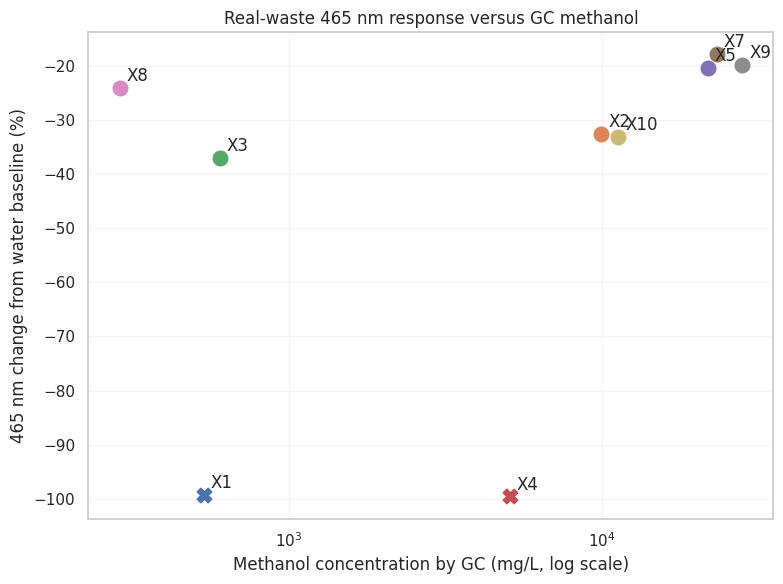

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in waste_gc_combined.dropna(
    subset=["Methanol_mg_L"]
).iterrows():

    marker = (
        "X"
        if row["Sample_ID"] in ["X1", "X4"]
        else "o"
    )

    plt.scatter(
        row["Methanol_mg_L"],
        row["465_full_pct_change"],
        marker=marker,
        s=110
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["Methanol_mg_L"],
            row["465_full_pct_change"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xscale("log")

plt.xlabel(
    "Methanol concentration by GC (mg/L, log scale)"
)

plt.ylabel(
    "465 nm change from water baseline (%)"
)

plt.title(
    "Real-waste 465 nm response versus GC methanol"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

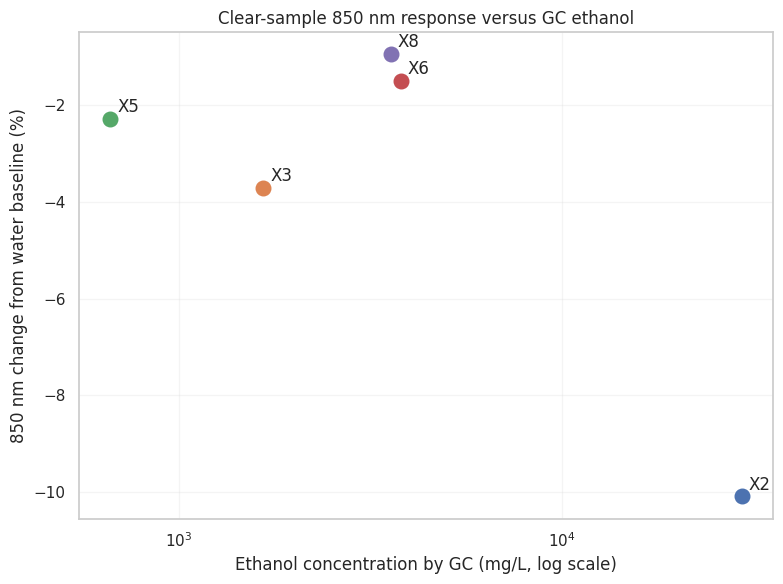

In [ ]:
ethanol_plot_data = (
    waste_without_extreme
    .dropna(
        subset=["Ethanol_mg_L"]
    )
)

plt.figure(figsize=(8, 6))

for _, row in ethanol_plot_data.iterrows():

    plt.scatter(
        row["Ethanol_mg_L"],
        row["850_full_pct_change"],
        s=110
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["Ethanol_mg_L"],
            row["850_full_pct_change"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xscale("log")

plt.xlabel(
    "Ethanol concentration by GC (mg/L, log scale)"
)

plt.ylabel(
    "850 nm change from water baseline (%)"
)

plt.title(
    "Clear-sample 850 nm response versus GC ethanol"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
display(
    methanol_465_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X1,8,0.4585,0.2532,0.6905,0.0580
1,X2,8,0.5745,0.1364,0.6667,0.0710
2,X3,8,0.6352,0.0906,0.6905,0.0580
3,X4,8,0.5739,0.1368,0.7143,0.0465
4,X5,8,0.5247,0.1819,0.5238,0.1827
5,X7,8,0.5129,0.1937,0.5476,0.1600
6,X8,8,0.7141,0.0466,0.8810,0.0039
7,X9,8,0.5271,0.1795,0.5476,0.1600
8,X10,8,0.5682,0.1417,0.6667,0.0710


In [ ]:
display(
    methanol_465_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X1,8,0.4585,0.2532,0.6905,0.0580
1,X2,8,0.5745,0.1364,0.6667,0.0710
2,X3,8,0.6352,0.0906,0.6905,0.0580
3,X4,8,0.5739,0.1368,0.7143,0.0465
4,X5,8,0.5247,0.1819,0.5238,0.1827
5,X7,8,0.5129,0.1937,0.5476,0.1600
6,X8,8,0.7141,0.0466,0.8810,0.0039
7,X9,8,0.5271,0.1795,0.5476,0.1600
8,X10,8,0.5682,0.1417,0.6667,0.0710


In [ ]:
ethanol_850_loo_correct = leave_one_out_correlation(
    waste_without_extreme,
    optical_column="850_full_pct_change",
    gc_column="Ethanol_mg_L"
)

print(
    "Expected omitted samples: X2, X3, X5, X6 and X8"
)

print(
    "Expected remaining n in each row: 4"
)

display(
    ethanol_850_loo_correct.round(4)
)

Expected omitted samples: X2, X3, X5, X6 and X8
Expected remaining n in each row: 4


,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X2,4,0.6783,0.3217,0.6,0.4
1,X3,4,-0.9743,0.0257,-0.4,0.6
2,X5,4,-0.9363,0.0637,-0.4,0.6
3,X6,4,-0.9412,0.0588,-0.4,0.6
4,X8,4,-0.9558,0.0442,-0.4,0.6


In [ ]:
assert len(ethanol_850_loo_correct) == 5

assert (
    ethanol_850_loo_correct["Remaining_n"] == 4
).all()

print(
    "Correct ethanol–850 nm influence table confirmed."
)

Correct ethanol–850 nm influence table confirmed.


# Exploratory PCA of Real-Waste Optical Responses

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

real_waste_pca_channels = [
    "465_full_pct_change",
    "625_full_pct_change",
    "850_full_pct_change",
    "940_full_pct_change"
]

X_real_waste = waste_gc_combined[
    real_waste_pca_channels
].astype(float)

sample_labels = waste_gc_combined[
    "Sample_ID"
].to_numpy()

display(X_real_waste.round(3))

,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change
0,-99.331,-96.152,-93.435,-90.090
1,-32.651,-6.933,-10.086,-4.586
2,-37.022,-31.965,-3.717,-1.085
3,-99.554,-98.033,-98.145,-96.976
4,-20.475,-28.504,-2.290,-2.977
5,-25.670,-51.741,-1.507,-2.883
6,-17.908,-5.610,-0.734,-1.717
7,-24.172,-22.098,-0.956,-2.132
8,-19.787,-16.756,-5.100,-0.898
9,-33.146,-63.188,-1.100,1.239


In [ ]:
real_waste_scaler = StandardScaler()

X_real_waste_scaled = (
    real_waste_scaler
    .fit_transform(X_real_waste)
)

real_waste_pca = PCA(
    n_components=2
)

real_waste_scores = (
    real_waste_pca
    .fit_transform(X_real_waste_scaled)
)

real_waste_explained = (
    real_waste_pca
    .explained_variance_ratio_
    * 100
)

print(
    f"PC1 explained variance: "
    f"{real_waste_explained[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{real_waste_explained[1]:.2f}%"
)

print(
    f"Cumulative variance: "
    f"{real_waste_explained[:2].sum():.2f}%"
)

PC1 explained variance: 93.83%
PC2 explained variance: 5.60%
Cumulative variance: 99.43%


In [ ]:
real_waste_scores_table = pd.DataFrame({
    "Sample_ID": sample_labels,
    "PC1": real_waste_scores[:, 0],
    "PC2": real_waste_scores[:, 1]
})

real_waste_scores_table = (
    real_waste_scores_table
    .merge(
        waste_gc_combined[
            [
                "Sample_ID",
                "Appearance",
                "Extreme_optical_attenuation",
                "Total_quantified_solvent_mg_L"
            ]
        ],
        on="Sample_ID",
        how="left"
    )
)

display(
    real_waste_scores_table.round(3)
)

,Sample_ID,PC1,PC2,Appearance,Extreme_optical_attenuation,Total_quantified_solvent_mg_L
0,X1,-3.735,0.094,Cloudy,Yes,3804.213
1,X2,1.029,0.662,Clear,No,39437.215
2,X3,0.726,-0.082,Clear,No,2971.789
3,X4,-3.926,0.149,Cloudy,Yes,89188.004
4,X5,1.053,-0.059,Clear,No,25116.408
5,X6,0.639,-0.669,Clear,No,6494.972
6,X7,1.468,0.518,Clear,No,23424.870
7,X8,1.113,0.109,Clear,No,12360.884
8,X9,1.226,0.262,Clear,No,30171.547
9,X10,0.407,-0.983,Clear,No,15922.743


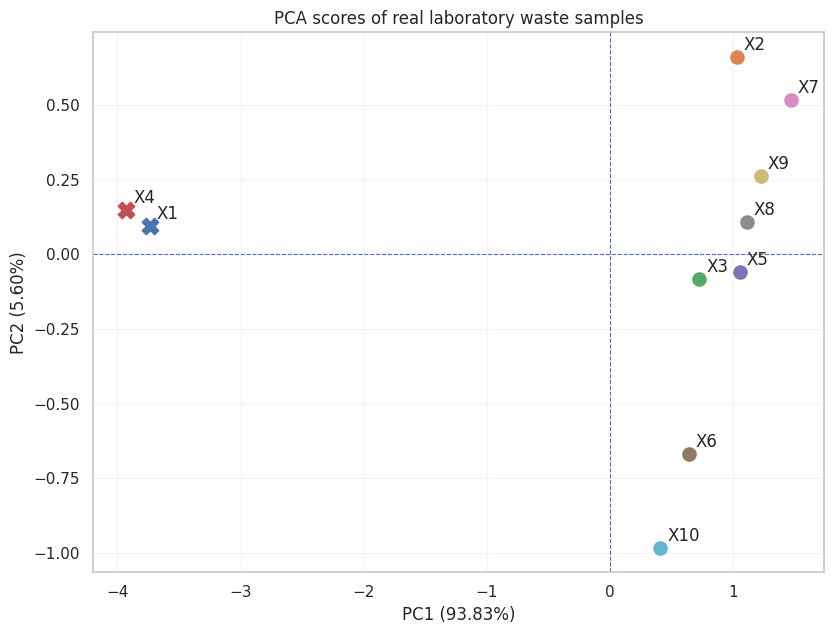

In [ ]:
plt.figure(figsize=(8.5, 6.5))

for _, row in real_waste_scores_table.iterrows():

    if row[
        "Extreme_optical_attenuation"
    ] == "Yes":
        marker = "X"
        point_size = 140
    else:
        marker = "o"
        point_size = 90

    plt.scatter(
        row["PC1"],
        row["PC2"],
        marker=marker,
        s=point_size
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["PC1"],
            row["PC2"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.xlabel(
    f"PC1 ({real_waste_explained[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({real_waste_explained[1]:.2f}%)"
)

plt.title(
    "PCA scores of real laboratory waste samples"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_pca_scores_all_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
real_waste_loadings = pd.DataFrame(
    real_waste_pca.components_.T,
    index=[
        "465 nm",
        "625 nm",
        "850 nm",
        "940 nm"
    ],
    columns=[
        "PC1_loading",
        "PC2_loading"
    ]
)

display(
    real_waste_loadings.round(4)
)

,PC1_loading,PC2_loading
465 nm,0.5113,-0.1319
625 nm,0.4703,0.8698
850 nm,0.5085,-0.3521
940 nm,0.5088,-0.3194


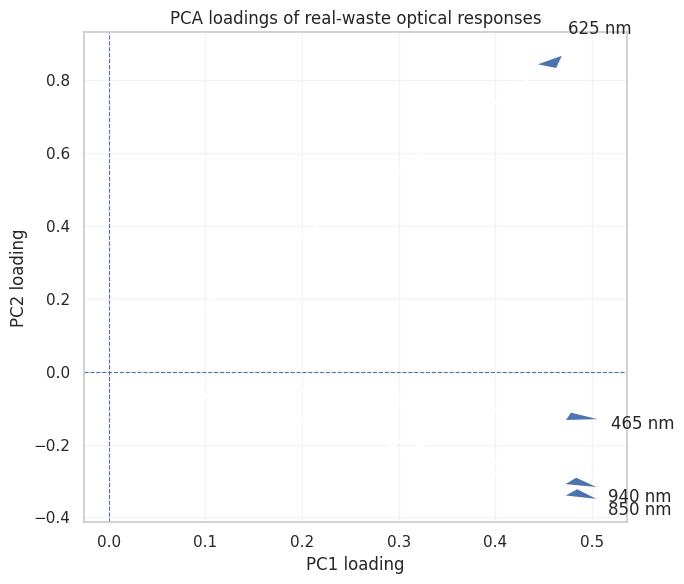

In [ ]:
plt.figure(figsize=(7, 6))

for wavelength, row in real_waste_loadings.iterrows():

    plt.arrow(
        0,
        0,
        row["PC1_loading"],
        row["PC2_loading"],
        head_width=0.025,
        length_includes_head=True
    )

    plt.text(
        row["PC1_loading"] * 1.08,
        row["PC2_loading"] * 1.08,
        wavelength,
        ha="center",
        va="center"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")

plt.title(
    "PCA loadings of real-waste optical responses"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_pca_loadings_all_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
real_waste_non_extreme = waste_gc_combined[
    ~waste_gc_combined["Sample_ID"].isin(
        ["X1", "X4"]
    )
].copy()

X_non_extreme = real_waste_non_extreme[
    real_waste_pca_channels
].astype(float)

non_extreme_scaler = StandardScaler()

X_non_extreme_scaled = (
    non_extreme_scaler
    .fit_transform(X_non_extreme)
)

non_extreme_pca = PCA(
    n_components=2
)

non_extreme_scores = (
    non_extreme_pca
    .fit_transform(X_non_extreme_scaled)
)

non_extreme_explained = (
    non_extreme_pca
    .explained_variance_ratio_
    * 100
)

print(
    f"PC1 explained variance: "
    f"{non_extreme_explained[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{non_extreme_explained[1]:.2f}%"
)

print(
    f"Cumulative variance: "
    f"{non_extreme_explained.sum():.2f}%"
)

PC1 explained variance: 50.77%
PC2 explained variance: 33.38%
Cumulative variance: 84.14%


In [ ]:
non_extreme_scores_table = pd.DataFrame({
    "Sample_ID":
        real_waste_non_extreme[
            "Sample_ID"
        ].to_numpy(),

    "PC1":
        non_extreme_scores[:, 0],

    "PC2":
        non_extreme_scores[:, 1],

    "Total_quantified_solvent_mg_L":
        real_waste_non_extreme[
            "Total_quantified_solvent_mg_L"
        ].to_numpy()
})

display(
    non_extreme_scores_table.round(3)
)

,Sample_ID,PC1,PC2,Total_quantified_solvent_mg_L
0,X2,2.741,-1.681,39437.215
1,X3,-0.535,-1.453,2971.789
2,X5,0.363,0.869,25116.408
3,X6,-0.643,0.043,6494.972
4,X7,0.397,1.773,23424.870
5,X8,-0.059,0.732,12360.884
6,X9,0.476,0.653,30171.547
7,X10,-2.741,-0.937,15922.743


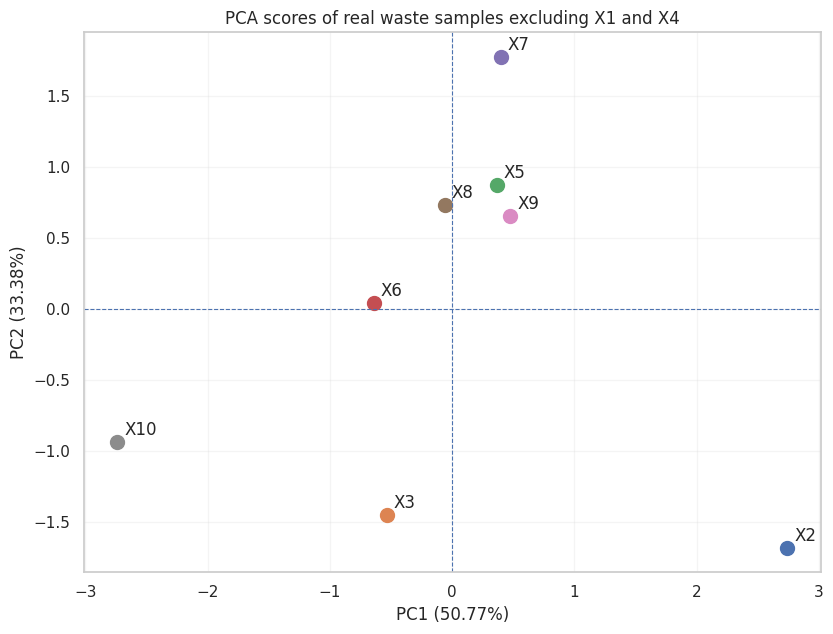

In [ ]:
plt.figure(figsize=(8.5, 6.5))

for _, row in non_extreme_scores_table.iterrows():

    plt.scatter(
        row["PC1"],
        row["PC2"],
        s=100
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["PC1"],
            row["PC2"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.xlabel(
    f"PC1 ({non_extreme_explained[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({non_extreme_explained[1]:.2f}%)"
)

plt.title(
    "PCA scores of real waste samples excluding X1 and X4"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
non_extreme_loadings = pd.DataFrame(
    non_extreme_pca.components_.T,
    index=[
        "465 nm",
        "625 nm",
        "850 nm",
        "940 nm"
    ],
    columns=[
        "PC1_loading",
        "PC2_loading"
    ]
)

display(
    non_extreme_loadings.round(4)
)

,PC1_loading,PC2_loading
465 nm,0.1399,0.8230
625 nm,0.5967,0.2608
850 nm,-0.5219,0.5044
940 nm,-0.5934,0.0126


In [ ]:
print(
    f"PC1 explained variance: "
    f"{non_extreme_explained[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{non_extreme_explained[1]:.2f}%"
)

print(
    f"Cumulative variance: "
    f"{non_extreme_explained[:2].sum():.2f}%"
)

PC1 explained variance: 50.77%
PC2 explained variance: 33.38%
Cumulative variance: 84.14%


In [ ]:
display(
    non_extreme_scores_table
    .sort_values("PC1")
    .round(3)
)

,Sample_ID,PC1,PC2,Total_quantified_solvent_mg_L
7,X10,-2.741,-0.937,15922.743
3,X6,-0.643,0.043,6494.972
1,X3,-0.535,-1.453,2971.789
5,X8,-0.059,0.732,12360.884
2,X5,0.363,0.869,25116.408
4,X7,0.397,1.773,23424.870
6,X9,0.476,0.653,30171.547
0,X2,2.741,-1.681,39437.215


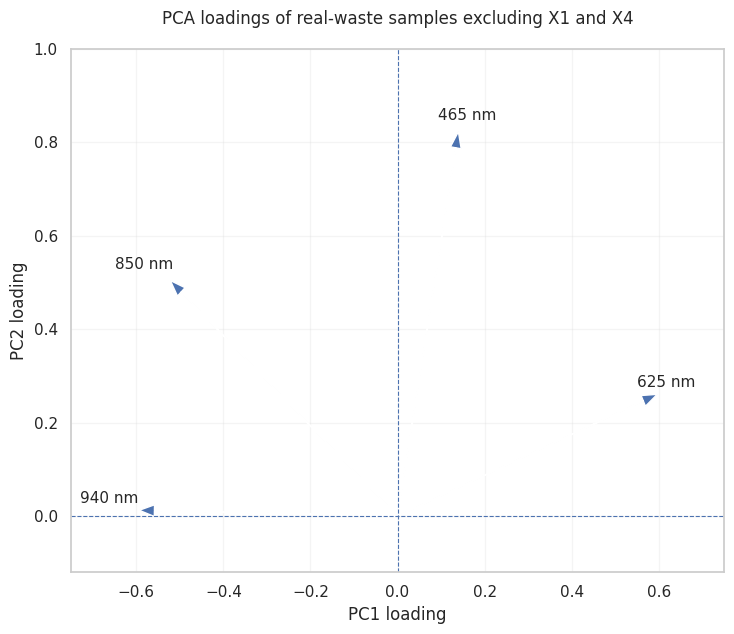

In [ ]:
plt.figure(figsize=(7.5, 6.5))

label_offsets = {
    "465 nm": (0.02, 0.035),
    "625 nm": (0.02, 0.025),
    "850 nm": (-0.06, 0.035),
    "940 nm": (-0.07, 0.025)
}

for wavelength, row in non_extreme_loadings.iterrows():

    x_loading = row["PC1_loading"]
    y_loading = row["PC2_loading"]

    plt.arrow(
        0,
        0,
        x_loading,
        y_loading,
        head_width=0.025,
        head_length=0.035,
        length_includes_head=True
    )

    x_offset, y_offset = label_offsets[wavelength]

    plt.text(
        x_loading + x_offset,
        y_loading + y_offset,
        wavelength,
        fontsize=11,
        ha="center",
        va="center"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")

plt.title(
    "PCA loadings of real-waste samples excluding X1 and X4",
    pad=18
)

plt.xlim(-0.75, 0.75)
plt.ylim(-0.12, 1.00)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_pca_loadings_without_X1_X4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(
    f"PC1 explained variance: "
    f"{non_extreme_explained[0]:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{non_extreme_explained[1]:.2f}%"
)

print(
    f"Cumulative variance: "
    f"{non_extreme_explained[:2].sum():.2f}%"
)

display(
    non_extreme_scores_table
    .sort_values("PC1")
    .round(3)
)

PC1 explained variance: 50.77%
PC2 explained variance: 33.38%
Cumulative variance: 84.14%


,Sample_ID,PC1,PC2,Total_quantified_solvent_mg_L
7,X10,-2.741,-0.937,15922.743
3,X6,-0.643,0.043,6494.972
1,X3,-0.535,-1.453,2971.789
5,X8,-0.059,0.732,12360.884
2,X5,0.363,0.869,25116.408
4,X7,0.397,1.773,23424.870
6,X9,0.476,0.653,30171.547
0,X2,2.741,-1.681,39437.215


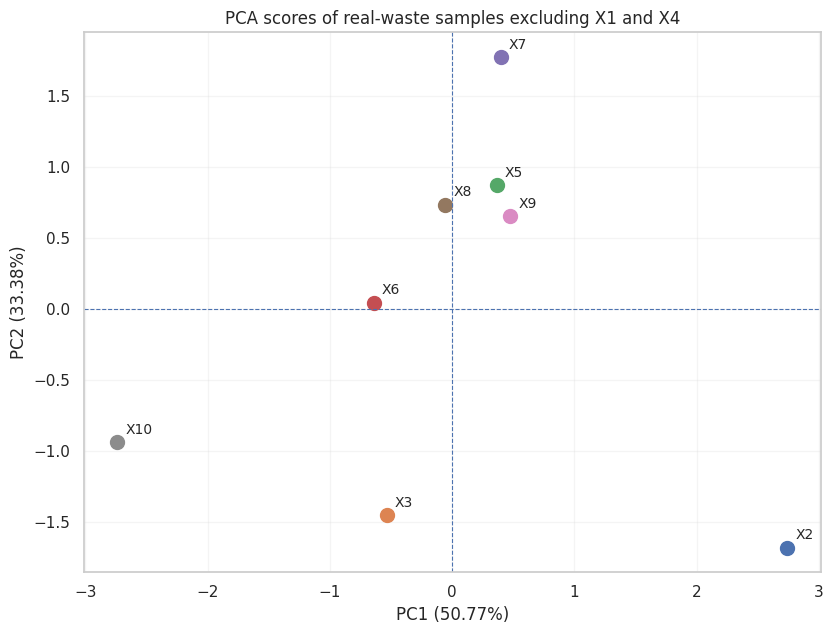

In [ ]:
plt.figure(figsize=(8.5, 6.5))

for _, row in non_extreme_scores_table.iterrows():

    plt.scatter(
        row["PC1"],
        row["PC2"],
        s=100
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["PC1"],
            row["PC2"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.xlabel(
    f"PC1 ({non_extreme_explained[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({non_extreme_explained[1]:.2f}%)"
)

plt.title(
    "PCA scores of real-waste samples excluding X1 and X4"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_pca_scores_without_X1_X4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
pca_gc_table = non_extreme_scores_table.copy()

display(
    pca_gc_table[
        [
            "Sample_ID",
            "PC1",
            "PC2",
            "Total_quantified_solvent_mg_L"
        ]
    ].round(3)
)

,Sample_ID,PC1,PC2,Total_quantified_solvent_mg_L
0,X2,2.741,-1.681,39437.215
1,X3,-0.535,-1.453,2971.789
2,X5,0.363,0.869,25116.408
3,X6,-0.643,0.043,6494.972
4,X7,0.397,1.773,23424.870
5,X8,-0.059,0.732,12360.884
6,X9,0.476,0.653,30171.547
7,X10,-2.741,-0.937,15922.743


In [ ]:
pca_gc_results = []

for pc_column in ["PC1", "PC2"]:

    pearson_r, pearson_p = pearsonr(
        pca_gc_table[pc_column],
        pca_gc_table[
            "Total_quantified_solvent_mg_L"
        ]
    )

    spearman_rho, spearman_p = spearmanr(
        pca_gc_table[pc_column],
        pca_gc_table[
            "Total_quantified_solvent_mg_L"
        ]
    )

    pca_gc_results.append({
        "Component": pc_column,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p
    })

pca_gc_correlation = pd.DataFrame(
    pca_gc_results
)

display(
    pca_gc_correlation.round(4)
)

,Component,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,PC1,0.6903,0.0581,0.8095,0.0149
1,PC2,0.0647,0.8790,0.0714,0.8665


In [ ]:
pc1_gc_influence = leave_one_out_correlation(
    pca_gc_table,
    optical_column="PC1",
    gc_column="Total_quantified_solvent_mg_L"
)

display(
    pc1_gc_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X2,7,0.4137,0.3561,0.7143,0.0713
1,X3,7,0.7369,0.0588,0.8571,0.0137
2,X5,7,0.6874,0.0879,0.7500,0.0522
3,X6,7,0.6927,0.0845,0.8571,0.0137
4,X7,7,0.6862,0.0887,0.7500,0.0522
5,X8,7,0.7062,0.0761,0.8214,0.0234
6,X9,7,0.6952,0.0829,0.7143,0.0713
7,X10,7,0.8876,0.0077,0.9286,0.0025


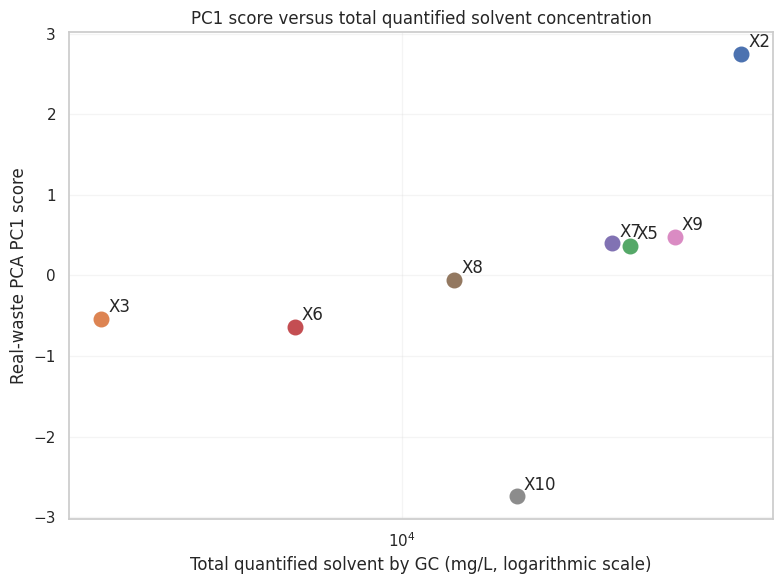

In [ ]:
plt.figure(figsize=(8, 6))

for _, row in pca_gc_table.iterrows():

    plt.scatter(
        row["Total_quantified_solvent_mg_L"],
        row["PC1"],
        s=110
    )

    plt.annotate(
        row["Sample_ID"],
        (
            row["Total_quantified_solvent_mg_L"],
            row["PC1"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xscale("log")

plt.xlabel(
    "Total quantified solvent by GC (mg/L, logarithmic scale)"
)

plt.ylabel("Real-waste PCA PC1 score")

plt.title(
    "PC1 score versus total quantified solvent concentration"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_PC1_vs_GC_total.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
pc1_gc_influence = leave_one_out_correlation(
    pca_gc_table,
    optical_column="PC1",
    gc_column="Total_quantified_solvent_mg_L"
)

display(
    pc1_gc_influence.round(4)
)

,Omitted_sample,Remaining_n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,X2,7,0.4137,0.3561,0.7143,0.0713
1,X3,7,0.7369,0.0588,0.8571,0.0137
2,X5,7,0.6874,0.0879,0.7500,0.0522
3,X6,7,0.6927,0.0845,0.8571,0.0137
4,X7,7,0.6862,0.0887,0.7500,0.0522
5,X8,7,0.7062,0.0761,0.8214,0.0234
6,X9,7,0.6952,0.0829,0.7143,0.0713
7,X10,7,0.8876,0.0077,0.9286,0.0025


In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

real_pls_data = (
    waste_without_extreme[
        [
            "Sample_ID",
            "465_full_pct_change",
            "625_full_pct_change",
            "850_full_pct_change",
            "940_full_pct_change",
            "Total_quantified_solvent_mg_L"
        ]
    ]
    .dropna()
    .copy()
)

real_pls_channels = [
    "465_full_pct_change",
    "625_full_pct_change",
    "850_full_pct_change",
    "940_full_pct_change"
]

X_real_pls = real_pls_data[
    real_pls_channels
].astype(float)

y_real_mg_L = real_pls_data[
    "Total_quantified_solvent_mg_L"
].to_numpy(dtype=float)

y_real_log = np.log10(y_real_mg_L)

print("Samples:", len(real_pls_data))
display(real_pls_data.round(3))

Samples: 8


,Sample_ID,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change,Total_quantified_solvent_mg_L
1,X2,-32.651,-6.933,-10.086,-4.586,39437.215
2,X3,-37.022,-31.965,-3.717,-1.085,2971.789
4,X5,-20.475,-28.504,-2.290,-2.977,25116.408
5,X6,-25.670,-51.741,-1.507,-2.883,6494.972
6,X7,-17.908,-5.610,-0.734,-1.717,23424.870
7,X8,-24.172,-22.098,-0.956,-2.132,12360.884
8,X9,-19.787,-16.756,-5.100,-0.898,30171.547
9,X10,-33.146,-63.188,-1.100,1.239,15922.743


In [ ]:
loo = LeaveOneOut()

real_pls_results = []
real_pls_predictions = {}

for n_components in range(1, 4):

    predicted_log = np.full(
        len(y_real_log),
        np.nan
    )

    for train_index, test_index in loo.split(X_real_pls):

        X_train = X_real_pls.iloc[train_index]
        X_test = X_real_pls.iloc[test_index]

        y_train = y_real_log[train_index]

        model = PLSRegression(
            n_components=n_components,
            scale=True,
            max_iter=1000
        )

        model.fit(
            X_train,
            y_train
        )

        predicted_log[test_index] = (
            model.predict(X_test).ravel()
        )

    press = np.sum(
        (y_real_log - predicted_log) ** 2
    )

    tss = np.sum(
        (y_real_log - y_real_log.mean()) ** 2
    )

    rmsecv_log = np.sqrt(
        mean_squared_error(
            y_real_log,
            predicted_log
        )
    )

    mae_log = mean_absolute_error(
        y_real_log,
        predicted_log
    )

    q_squared = 1 - press / tss

    predicted_mg_L = 10 ** predicted_log

    mae_mg_L = mean_absolute_error(
        y_real_mg_L,
        predicted_mg_L
    )

    real_pls_results.append({
        "PLS_components": n_components,
        "RMSECV_log10": rmsecv_log,
        "MAE_log10": mae_log,
        "Q_squared_log10": q_squared,
        "MAE_back_transformed_mg_L": mae_mg_L
    })

    real_pls_predictions[
        n_components
    ] = predicted_log

In [ ]:
real_pls_results_table = pd.DataFrame(
    real_pls_results
)

display(
    real_pls_results_table.round(4)
)

,PLS_components,RMSECV_log10,MAE_log10,Q_squared_log10,MAE_back_transformed_mg_L
0,1,0.5869,0.4384,-1.7834,11522.5496
1,2,0.7750,0.5649,-3.8527,13513.5998
2,3,0.8759,0.7076,-5.1990,66260.8075


In [ ]:
selected_real_components = 1

selected_real_predicted_log = (
    real_pls_predictions[
        selected_real_components
    ]
)

selected_real_predicted_mg_L = (
    10 ** selected_real_predicted_log
)

real_pls_prediction_table = pd.DataFrame({
    "Sample_ID":
        real_pls_data["Sample_ID"].to_numpy(),

    "Measured_mg_L":
        y_real_mg_L,

    "Predicted_mg_L":
        selected_real_predicted_mg_L,

    "Measured_log10":
        y_real_log,

    "Predicted_log10":
        selected_real_predicted_log
})

real_pls_prediction_table["Error_mg_L"] = (
    real_pls_prediction_table["Predicted_mg_L"]
    - real_pls_prediction_table["Measured_mg_L"]
)

real_pls_prediction_table["Absolute_error_mg_L"] = (
    real_pls_prediction_table["Error_mg_L"].abs()
)

display(
    real_pls_prediction_table.round(3)
)

,Sample_ID,Measured_mg_L,Predicted_mg_L,Measured_log10,Predicted_log10,Error_mg_L,Absolute_error_mg_L
0,X2,39437.215,9302.255,4.596,3.969,-30134.961,30134.961
1,X3,2971.789,17602.278,3.473,4.246,14630.489,14630.489
2,X5,25116.408,17537.905,4.400,4.244,-7578.503,7578.503
3,X6,6494.972,14057.737,3.813,4.148,7562.766,7562.766
4,X7,23424.870,21053.250,4.370,4.323,-2371.620,2371.620
5,X8,12360.884,16213.440,4.092,4.210,3852.555,3852.555
6,X9,30171.547,19158.597,4.480,4.282,-11012.950,11012.950
7,X10,15922.743,886.190,4.202,2.948,-15036.553,15036.553


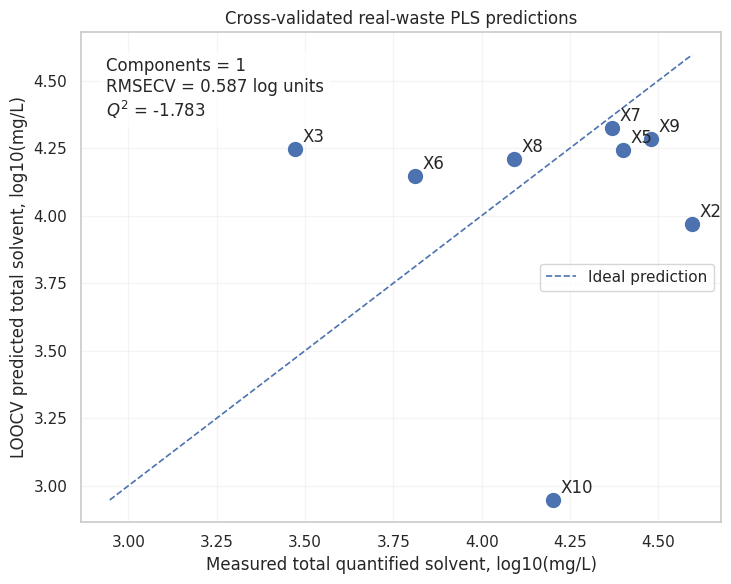

In [ ]:
plt.figure(figsize=(7.5, 6))

plt.scatter(
    real_pls_prediction_table["Measured_log10"],
    real_pls_prediction_table["Predicted_log10"],
    s=100
)

for _, row in real_pls_prediction_table.iterrows():

    plt.annotate(
        row["Sample_ID"],
        (
            row["Measured_log10"],
            row["Predicted_log10"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

minimum_value = min(
    real_pls_prediction_table["Measured_log10"].min(),
    real_pls_prediction_table["Predicted_log10"].min()
)

maximum_value = max(
    real_pls_prediction_table["Measured_log10"].max(),
    real_pls_prediction_table["Predicted_log10"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.2,
    label="Ideal prediction"
)

plt.xlabel(
    "Measured total quantified solvent, log10(mg/L)"
)

plt.ylabel(
    "LOOCV predicted total solvent, log10(mg/L)"
)

plt.title(
    "Cross-validated real-waste PLS predictions"
)

plt.text(
    0.04,
    0.95,
    (
        "Components = 1\n"
        "RMSECV = 0.587 log units\n"
        "$Q^2$ = -1.783"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "real_waste_pls_loocv_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
real_pls_data_all = (
    waste_gc_combined[
        [
            "Sample_ID",
            "465_full_pct_change",
            "625_full_pct_change",
            "850_full_pct_change",
            "940_full_pct_change",
            "Total_quantified_solvent_mg_L"
        ]
    ]
    .dropna()
    .copy()
)

X_real_pls_all = real_pls_data_all[
    real_pls_channels
].astype(float)

y_real_all_mg_L = real_pls_data_all[
    "Total_quantified_solvent_mg_L"
].to_numpy(dtype=float)

y_real_all_log = np.log10(
    y_real_all_mg_L
)

print(
    "Number of all-sample observations:",
    len(real_pls_data_all)
)

display(
    real_pls_data_all.round(3)
)

Number of all-sample observations: 10


,Sample_ID,465_full_pct_change,625_full_pct_change,850_full_pct_change,940_full_pct_change,Total_quantified_solvent_mg_L
0,X1,-99.331,-96.152,-93.435,-90.090,3804.213
1,X2,-32.651,-6.933,-10.086,-4.586,39437.215
2,X3,-37.022,-31.965,-3.717,-1.085,2971.789
3,X4,-99.554,-98.033,-98.145,-96.976,89188.004
4,X5,-20.475,-28.504,-2.290,-2.977,25116.408
5,X6,-25.670,-51.741,-1.507,-2.883,6494.972
6,X7,-17.908,-5.610,-0.734,-1.717,23424.870
7,X8,-24.172,-22.098,-0.956,-2.132,12360.884
8,X9,-19.787,-16.756,-5.100,-0.898,30171.547
9,X10,-33.146,-63.188,-1.100,1.239,15922.743


In [ ]:
loo_all = LeaveOneOut()

real_pls_all_results = []
real_pls_all_predictions = {}

for n_components in range(1, 4):

    predicted_log = np.full(
        len(y_real_all_log),
        np.nan
    )

    for train_index, test_index in loo_all.split(
        X_real_pls_all
    ):

        X_train = X_real_pls_all.iloc[
            train_index
        ]

        X_test = X_real_pls_all.iloc[
            test_index
        ]

        y_train = y_real_all_log[
            train_index
        ]

        model = PLSRegression(
            n_components=n_components,
            scale=True,
            max_iter=1000
        )

        model.fit(
            X_train,
            y_train
        )

        predicted_log[test_index] = (
            model
            .predict(X_test)
            .ravel()
        )

    press = np.sum(
        (
            y_real_all_log
            - predicted_log
        ) ** 2
    )

    tss = np.sum(
        (
            y_real_all_log
            - y_real_all_log.mean()
        ) ** 2
    )

    rmsecv_log = np.sqrt(
        mean_squared_error(
            y_real_all_log,
            predicted_log
        )
    )

    mae_log = mean_absolute_error(
        y_real_all_log,
        predicted_log
    )

    q_squared = (
        1
        - press / tss
    )

    predicted_mg_L = (
        10 ** predicted_log
    )

    mae_mg_L = mean_absolute_error(
        y_real_all_mg_L,
        predicted_mg_L
    )

    real_pls_all_results.append({
        "Dataset": "All 10 samples",
        "PLS_components": n_components,
        "RMSECV_log10": rmsecv_log,
        "MAE_log10": mae_log,
        "Q_squared_log10": q_squared,
        "MAE_back_transformed_mg_L": mae_mg_L
    })

    real_pls_all_predictions[
        n_components
    ] = predicted_log

In [ ]:
real_pls_all_results_table = pd.DataFrame(
    real_pls_all_results
)

display(
    real_pls_all_results_table.round(4)
)

,Dataset,PLS_components,RMSECV_log10,MAE_log10,Q_squared_log10,MAE_back_transformed_mg_L
0,All 10 samples,1,0.7129,0.5395,-1.6189,24857.3345
1,All 10 samples,2,0.7207,0.5445,-1.6760,23582.2121
2,All 10 samples,3,0.7540,0.5973,-1.9291,23835.1905


In [ ]:
real_pls_results_comparison = pd.concat(
    [
        real_pls_all_results_table,
        real_pls_results_table.assign(
            Dataset="Without X1 and X4"
        )
    ],
    ignore_index=True
)

display(
    real_pls_results_comparison[
        [
            "Dataset",
            "PLS_components",
            "RMSECV_log10",
            "MAE_log10",
            "Q_squared_log10",
            "MAE_back_transformed_mg_L"
        ]
    ].round(4)
)

,Dataset,PLS_components,RMSECV_log10,MAE_log10,Q_squared_log10,MAE_back_transformed_mg_L
0,All 10 samples,1,0.7129,0.5395,-1.6189,24857.3345
1,All 10 samples,2,0.7207,0.5445,-1.6760,23582.2121
2,All 10 samples,3,0.7540,0.5973,-1.9291,23835.1905
3,Without X1 and X4,1,0.5869,0.4384,-1.7834,11522.5496
4,Without X1 and X4,2,0.7750,0.5649,-3.8527,13513.5998
5,Without X1 and X4,3,0.8759,0.7076,-5.1990,66260.8075


In [ ]:
final_real_waste_pls_summary = pd.DataFrame({
    "Dataset": [
        "All 10 real-waste samples",
        "Without X1 and X4"
    ],
    "Selected_components": [1, 1],
    "RMSECV_log10": [0.7129, 0.5869],
    "MAE_log10": [0.5395, 0.4384],
    "Q_squared": [-1.6189, -1.7834],
    "MAE_back_transformed_mg_L": [
        24857.3345,
        11522.5496
    ],
    "Interpretation": [
        "Model not predictive",
        "Lower error, but model still not predictive"
    ]
})

display(
    final_real_waste_pls_summary.round(4)
)

,Dataset,Selected_components,RMSECV_log10,MAE_log10,Q_squared,MAE_back_transformed_mg_L,Interpretation
0,All 10 real-waste samples,1,0.7129,0.5395,-1.6189,24857.3345,Model not predictive
1,Without X1 and X4,1,0.5869,0.4384,-1.7834,11522.5496,"Lower error, but model still not predictive"


# Reduced-Wavelength Spike PLS Model

In [ ]:
reduced_spike_channels = [
    "625_full_pct",
    "940_full_pct"
]

X_spike_reduced = spike_pls_table[
    reduced_spike_channels
].astype(float)

print("Reduced predictor shape:", X_spike_reduced.shape)
display(X_spike_reduced.round(3))

Reduced predictor shape: (13, 2)


,625_full_pct,940_full_pct
0,0.000,0.000
1,-3.975,0.403
2,-13.768,2.265
3,-19.497,3.045
4,-30.488,5.007
5,-3.612,1.995
6,-8.855,2.581
7,-20.157,3.328
8,-23.391,4.546
9,-1.758,1.880


In [ ]:
reduced_component_results = []
reduced_cv_predictions = {}

for n_components in range(1, 3):

    y_cv_pred = np.full(
        len(y_spike_pls),
        np.nan,
        dtype=float
    )

    for train_index, test_index in spike_group_cv.split(
        X_spike_reduced,
        y_spike_pls,
        groups_spike_pls
    ):

        X_train = X_spike_reduced.iloc[train_index]
        X_test = X_spike_reduced.iloc[test_index]

        y_train = y_spike_pls[train_index]

        reduced_model = PLSRegression(
            n_components=n_components,
            scale=True,
            max_iter=1000
        )

        reduced_model.fit(
            X_train,
            y_train
        )

        y_cv_pred[test_index] = (
            reduced_model
            .predict(X_test)
            .ravel()
        )

    press = np.sum(
        (y_spike_pls - y_cv_pred) ** 2
    )

    tss = np.sum(
        (y_spike_pls - y_spike_pls.mean()) ** 2
    )

    rmsecv = np.sqrt(
        mean_squared_error(
            y_spike_pls,
            y_cv_pred
        )
    )

    mae = mean_absolute_error(
        y_spike_pls,
        y_cv_pred
    )

    q_squared = 1 - press / tss

    reduced_component_results.append({
        "Model": "625 + 940 nm",
        "PLS_components": n_components,
        "RMSECV_percent_vv": rmsecv,
        "MAE_percent_vv": mae,
        "Q_squared": q_squared
    })

    reduced_cv_predictions[
        n_components
    ] = y_cv_pred

In [ ]:
reduced_results_table = pd.DataFrame(
    reduced_component_results
)

display(
    reduced_results_table.round(4)
)

,Model,PLS_components,RMSECV_percent_vv,MAE_percent_vv,Q_squared
0,625 + 940 nm,1,1.6339,1.3565,0.9332
1,625 + 940 nm,2,1.7071,1.3562,0.9270


In [ ]:
full_model_summary = pd.DataFrame([{
    "Model": "465 + 625 + 850 + 940 nm",
    "PLS_components": 2,
    "RMSECV_percent_vv": selected_rmsecv,
    "MAE_percent_vv": selected_mae,
    "Q_squared": selected_q_squared
}])

reduced_model_comparison = pd.concat(
    [
        full_model_summary,
        reduced_results_table
    ],
    ignore_index=True
)

display(
    reduced_model_comparison.round(4)
)

,Model,PLS_components,RMSECV_percent_vv,MAE_percent_vv,Q_squared
0,465 + 625 + 850 + 940 nm,2,2.0419,1.6026,0.8956
1,625 + 940 nm,1,1.6339,1.3565,0.9332
2,625 + 940 nm,2,1.7071,1.3562,0.9270


In [ ]:
selected_reduced_components = 1

selected_reduced_predictions = (
    reduced_cv_predictions[
        selected_reduced_components
    ]
)

reduced_prediction_table = (
    spike_pls_table[
        [
            "Sample_ID",
            "Solvent",
            "Spike_percent_vv"
        ]
    ]
    .copy()
)

reduced_prediction_table[
    "Predicted_percent_vv"
] = selected_reduced_predictions

reduced_prediction_table[
    "Prediction_error"
] = (
    reduced_prediction_table[
        "Predicted_percent_vv"
    ]
    - reduced_prediction_table[
        "Spike_percent_vv"
    ]
)

reduced_prediction_table[
    "Absolute_error"
] = (
    reduced_prediction_table[
        "Prediction_error"
    ].abs()
)

display(
    reduced_prediction_table.round(3)
)

,Sample_ID,Solvent,Spike_percent_vv,Predicted_percent_vv,Prediction_error,Absolute_error
0,Baseline_0,Baseline,0,1.571,1.571,1.571
1,Acetone_5,Acetone,5,3.581,-1.419,1.419
2,Acetone_10,Acetone,10,10.874,0.874,0.874
3,Acetone_15,Acetone,15,14.525,-0.475,0.475
4,Acetone_20,Acetone,20,23.411,3.411,3.411
5,Ethanol_5,Ethanol,5,7.127,2.127,2.127
6,Ethanol_10,Ethanol,10,9.842,-0.158,0.158
7,Ethanol_15,Ethanol,15,15.373,0.373,0.373
8,Ethanol_20,Ethanol,20,19.739,-0.261,0.261
9,Methanol_5,Methanol,5,6.263,1.263,1.263


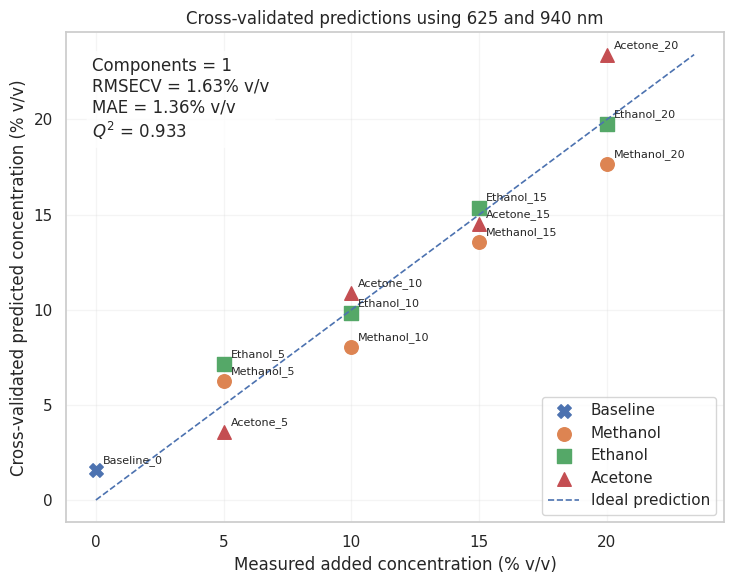

In [ ]:
plt.figure(figsize=(7.5, 6))

markers = {
    "Baseline": "X",
    "Methanol": "o",
    "Ethanol": "s",
    "Acetone": "^"
}

for solvent in [
    "Baseline",
    "Methanol",
    "Ethanol",
    "Acetone"
]:

    subset = reduced_prediction_table[
        reduced_prediction_table[
            "Solvent"
        ] == solvent
    ]

    if len(subset) == 0:
        continue

    plt.scatter(
        subset["Spike_percent_vv"],
        subset["Predicted_percent_vv"],
        marker=markers[solvent],
        s=95,
        label=solvent
    )

    for _, row in subset.iterrows():

        plt.annotate(
            row["Sample_ID"],
            (
                row["Spike_percent_vv"],
                row["Predicted_percent_vv"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

plot_minimum = min(
    reduced_prediction_table[
        "Spike_percent_vv"
    ].min(),
    reduced_prediction_table[
        "Predicted_percent_vv"
    ].min()
)

plot_maximum = max(
    reduced_prediction_table[
        "Spike_percent_vv"
    ].max(),
    reduced_prediction_table[
        "Predicted_percent_vv"
    ].max()
)

plt.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    linestyle="--",
    linewidth=1.2,
    label="Ideal prediction"
)

plt.xlabel(
    "Measured added concentration (% v/v)"
)

plt.ylabel(
    "Cross-validated predicted concentration (% v/v)"
)

plt.title(
    "Cross-validated predictions using 625 and 940 nm"
)

plt.text(
    0.04,
    0.95,
    (
        "Components = 1\n"
        "RMSECV = 1.63% v/v\n"
        "MAE = 1.36% v/v\n"
        "$Q^2$ = 0.933"
    ),
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8
    }
)

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Project_78/Results/"
    "reduced_625_940_spike_pls_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
spike_solvent_error_summary = (
    reduced_prediction_table[
        reduced_prediction_table["Solvent"] != "Baseline"
    ]
    .groupby("Solvent")
    .agg(
        Number_of_samples=(
            "Absolute_error",
            "count"
        ),
        Mean_error_percent_vv=(
            "Prediction_error",
            "mean"
        ),
        MAE_percent_vv=(
            "Absolute_error",
            "mean"
        ),
        Maximum_absolute_error_percent_vv=(
            "Absolute_error",
            "max"
        )
    )
    .reset_index()
)

display(
    spike_solvent_error_summary.round(3)
)

,Solvent,Number_of_samples,Mean_error_percent_vv,MAE_percent_vv,Maximum_absolute_error_percent_vv
0,Acetone,4,0.598,1.545,3.411
1,Ethanol,4,0.520,0.730,2.127
2,Methanol,4,-1.110,1.741,2.318


In [ ]:
spike_concentration_error_summary = (
    reduced_prediction_table
    .groupby("Spike_percent_vv")
    .agg(
        Mean_predicted_percent_vv=(
            "Predicted_percent_vv",
            "mean"
        ),
        Mean_error_percent_vv=(
            "Prediction_error",
            "mean"
        ),
        MAE_percent_vv=(
            "Absolute_error",
            "mean"
        ),
        Maximum_absolute_error_percent_vv=(
            "Absolute_error",
            "max"
        )
    )
    .reset_index()
)

display(
    spike_concentration_error_summary.round(3)
)

,Spike_percent_vv,Mean_predicted_percent_vv,Mean_error_percent_vv,MAE_percent_vv,Maximum_absolute_error_percent_vv
0,0,1.571,1.571,1.571,1.571
1,5,5.657,0.657,1.603,2.127
2,10,9.584,-0.416,0.999,1.964
3,15,14.492,-0.508,0.756,1.422
4,20,20.277,0.277,1.996,3.411


In [ ]:
display(
    spike_solvent_error_summary.round(3)
)

,Solvent,Number_of_samples,Mean_error_percent_vv,MAE_percent_vv,Maximum_absolute_error_percent_vv
0,Acetone,4,0.598,1.545,3.411
1,Ethanol,4,0.520,0.730,2.127
2,Methanol,4,-1.110,1.741,2.318


In [ ]:
display(
    reduced_prediction_table[
        [
            "Sample_ID",
            "Solvent",
            "Spike_percent_vv",
            "Predicted_percent_vv",
            "Prediction_error",
            "Absolute_error"
        ]
    ]
    .sort_values(
        "Absolute_error",
        ascending=False
    )
    .round(3)
)

,Sample_ID,Solvent,Spike_percent_vv,Predicted_percent_vv,Prediction_error,Absolute_error
4,Acetone_20,Acetone,20,23.411,3.411,3.411
12,Methanol_20,Methanol,20,17.682,-2.318,2.318
5,Ethanol_5,Ethanol,5,7.127,2.127,2.127
10,Methanol_10,Methanol,10,8.036,-1.964,1.964
0,Baseline_0,Baseline,0,1.571,1.571,1.571
11,Methanol_15,Methanol,15,13.578,-1.422,1.422
1,Acetone_5,Acetone,5,3.581,-1.419,1.419
9,Methanol_5,Methanol,5,6.263,1.263,1.263
2,Acetone_10,Acetone,10,10.874,0.874,0.874
3,Acetone_15,Acetone,15,14.525,-0.475,0.475


In [ ]:
RESULTS_DIR = (
    "/content/drive/MyDrive/Project_78/Results"
)

reduced_prediction_table.to_csv(
    f"{RESULTS_DIR}/reduced_625_940_prediction_table.csv",
    index=False
)

spike_solvent_error_summary.to_csv(
    f"{RESULTS_DIR}/reduced_625_940_error_by_solvent.csv",
    index=False
)

spike_concentration_error_summary.to_csv(
    f"{RESULTS_DIR}/reduced_625_940_error_by_concentration.csv",
    index=False
)

reduced_model_comparison.to_csv(
    f"{RESULTS_DIR}/full_vs_reduced_spike_PLS_comparison.csv",
    index=False
)

print("Reduced-wavelength PLS results saved successfully.")

Reduced-wavelength PLS results saved successfully.
